In [ ]:
from OOP_so_far import ModuleProperties
from sympy import *
import numpy as np
import time
import matplotlib.pyplot as plt
# Module 1

SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["A1", "A2","A3","S","Na"]

num_internal_species = 3

# Module 2


SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["B1", "B2", "B3", "B4", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Module 3

# SM3 = Matrix([
#     [ 1, -1,  0,  0,  0,  0],  # EcNex
#     [-1,  1, -1,  1,  0,  0],  # Ec
#     [ 0,  0,  1, -1,  0,  0],  # EcNb
#     [ 0,  0,  0,  0, -1,  1],  # Ec*
#     [ 0,  0,  0,  0,  1, -1],  # Ec*Ne
#     [ 0,  0,  0,  0, -1,  0],  # Ne
#     [-1,  0,  0,  0,  0,  0],  # Nex
#     [ 0,  0, -1,  0,  0,  0],  # Nb
#     [ 0,  1,  0,  0,  0,  0],  # Pex
#     [ 0,  0,  0,  1,  0,  0],  # Pb  # col 4 entry uncertain
#     [ 0,  0,  0,  0,  0,  1],  # Pe
# ])

SM3=Matrix([
    [-1,1,-1,1,0,0],
    [1,-1,0,0,0,0],
    [0,0,1,-1,0,0],
    [0,0,0,0,-1,1],
    [0,0,0,0,1,-1],
    [-1,0,0,0,0,0],
    [0,0,-1,0,0,0],
    [0,0,0,0,-1,0],
    [0,1,0,0,0,0],
    [0,0,0,1,0,0],
    [0,0,0,0,0,1]
])

# species_names3 = ["C1", "C2", "C3", "C4", "C5", "Ne", "Nex", "Nb", "Pex", "Pb", "Pe"]
species_names3 = ["C1", "C2", "C3", "C4", "C5", "Nex","Nb","Ne","Pex","Pb","Pe"]
# Module 4

# SM4 = Matrix([
#     [ 1,  1, -1,  0,  1],  # Ed
#     [-1, -1,  1,  1,  0],  # EdS
#     [ 0,  1,  0, -1, -1],  # Ed*
#     [ 0,  0, -1, -1,  0],  # Nd
#     [ 1,  0,  0,  0,  0],  # S
# ])

SM4 = Matrix([[-1,0,1,0,-1],
            [0,-1,0,1,1],
            [1,1,-1,-1,0],
            [-1,-1,0,0,0],
            [0,0,1,1,0]])

display(SM4)

# SM4 = Matrix([[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names4 = ["D1", "D2", "D3", "Nd", "S"] # swapped S and Nd


module1 = ModuleProperties(SM, 3, species_names)
display(module1.calculate_fundamental_resistance_matrix())

module2 = ModuleProperties(SM2, 4, species_names2)
display(module2.calculate_fundamental_resistance_matrix())

module3 = ModuleProperties(SM3, 5, species_names3)
display(module3.calculate_fundamental_resistance_matrix())

module4 = ModuleProperties(SM4, 3, species_names4)
display(module4.calculate_fundamental_resistance_matrix())

simulation_length = 2000.0

burn_in = 1000.0



⎡-1  0   1   0   -1⎤
⎢                  ⎥
⎢0   -1  0   1   1 ⎥
⎢                  ⎥
⎢1   1   -1  -1  0 ⎥
⎢                  ⎥
⎢-1  -1  0   0   0 ⎥
⎢                  ⎥
⎣0   0   1   1   0 ⎦

[r₁ + r₂]

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

⎡r₁ + r₂     0        0   ⎤
⎢                         ⎥
⎢   0     r₃ + r₄     0   ⎥
⎢                         ⎥
⎣   0        0     r₅ + r₆⎦

⎡r₁⋅r₂⋅r₃ + r₁⋅r₂⋅r₄ + r₁⋅r₂⋅r₅ + r₁⋅r₃⋅r₄ + r₁⋅r₄⋅r₅ + r₂⋅r₃⋅r₄ + r₂⋅r₃⋅r₅ +  ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎣            r₁⋅r₃ + r₁⋅r₄ + r₁⋅r₅ + r₂⋅r₃ + r₂⋅r₄ + r₂⋅r₅ + r₃⋅r₅ + r₄⋅r₅     ↪

↪ r₃⋅r₄⋅r₅⎤
↪ ────────⎥
↪         ⎦

In [94]:
# joint_1 = CombiningModules(module4,module1)

# # joint_1.fundamental_resistance_matrix

# joint_2 = CombiningModules(joint_1,module2)

# display(joint_2.fundamental_resistance_matrix)

# joint_3 = CombiningModules(joint_2, module3)

# display(joint_3.fundamental_resistance_matrix)


modj3 = ModuleProperties(joint_3.stoich_matrix, joint_3.num_internal_species, joint_3.species_names)

modj3.calculate_fundamental_resistance_matrix()

⎡r₁₀ + r₁₁ + r₉      0                                                         ↪
⎢                                                                              ↪
⎢      0         r₁₄ + r₁₅                                                     ↪
⎢                                                                              ↪
⎢                           r₁⋅r₁₀⋅r₃ + r₁⋅r₁₀⋅r₄ + r₁⋅r₁₀⋅r₅ + r₁⋅r₁₂⋅r₃ + r₁ ↪
⎢     -r₁₀           0      ────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣      0             0                                                         ↪

↪                                                                              ↪
↪                                                                              ↪
↪                                                                              ↪
↪                          

In [87]:

# initial_counts = [200, 50, 30, 152, 110]

# initial_counts2 = [200, 50, 50, 50, 110, 100, 200, 80]

# initial_counts3 = [200, 120, 50, 200, 200, 150, 100, 150, 80, 100, 80]

# initial_counts4 = [150, 150, 50, 100, 152]  # Fixed Nd=100


# Module 1: [A1, A2, A3, S, Na]
initial_counts = [150, 50, 30, 152, 110]

# Module 2: [B1, B2, B3, B4, Na, Nb, F, W]
initial_counts2 = [50, 50, 50, 80, 110, 100, 200, 80]

# Module 3: [C1, C2, C3, C4, C5, Nex, Nb, Ne, Pex, Pb, Pe]
initial_counts3 = [100, 100, 200, 120, 50, 150, 100, 150, 80, 100, 80]

# Module 4: [D1, D2, D3, Nd, S]
initial_counts4 = [150, 150, 50, 200, 152]



rates = np.array([0.0005, 0.006, 0.010, 0.001, 0.0005, 0.008])

rates2 = np.array([0.0002, 0.010, 0.004, 0.004, 0.015, 0.0005, 0.0002, 0.012, 0.015, 0.0005])

rates3 = np.array([0.0008, 0.003, 0.004, 0.002, 0.0002, 0.012, 0.015, 0.0005, 0.0005, 0.008, 0.010, 0.001])

rates4 = np.array([0.0005, 0.006, 0.0005, 0.006, 0.010, 0.001, 0.008, 0.001, 0.003, 0.004])

simulation_length = 4000.0

burn_in = 2000.0

SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)
SIM2 = RunSSA(module2, initial_counts2, rates2, simulation_length, burn_in)
SIM3 = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)
SIM4 = RunSSA(module4, initial_counts4, rates4, simulation_length, burn_in)

In [ ]:


SIM1 = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)
SIM2 = RunSSA(module2, initial_counts2, rates2, simulation_length, burn_in)
SIM3 = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)
SIM4 = RunSSA(module4, initial_counts4, rates4, simulation_length, burn_in)


In [5]:
SIM1.run_SSA_and_plot_counts(True)
SIM2.run_SSA_and_plot_counts(True)
SIM3.run_SSA_and_plot_counts(True)
SIM4.run_SSA_and_plot_counts(True)

In [2]:
def primitive_nullspace(matrix):
    null_basis = matrix.nullspace()
    if not null_basis:
        return Matrix([])
    cols = []
    for vec in null_basis:
        denoms = [fraction(x)[1] for x in vec]
        lcm_denom = Integer(1)
        for d in denoms:
            lcm_denom = lcm(lcm_denom, d)
        vec = vec * lcm_denom
        numers = [abs(x) for x in vec if x != 0]
        if numers:
            gcd_numer = numers[0]
            for n in numers[1:]:
                gcd_numer = gcd(gcd_numer, n)
            vec = vec / gcd_numer
        first_nonzero = next((vec[i] for i in range(len(vec)) if vec[i] != 0), 0)
        if first_nonzero < 0:
            vec = -vec
        cols.append(vec)
    return Matrix.hstack(*cols)

def normalise_selection_matrix(S):
    """
    Scale each column so that S.T * S = I
    while preserving the number of rows.
    """
    cols = []
    for j in range(S.cols):
        col = S.col(j)
        norm_sq = (col.T * col)[0, 0]
        if norm_sq == 0:
            cols.append(col)
        else:
            cols.append(col / sqrt(norm_sq))
    return Matrix.hstack(*cols)


def build_selection_matrix(full_Lambda):
    rows_to_keep = [row for row in range(full_Lambda.rows)
                    if any(full_Lambda[row, col] != 0
                           for col in range(full_Lambda.cols))]
    if rows_to_keep:
        Lambda_reduced = full_Lambda.extract(
            rows_to_keep, list(range(full_Lambda.cols)))
    else:
        Lambda_reduced = full_Lambda
    return primitive_nullspace(Lambda_reduced)


# ── symbol-shifting helpers (module-level so Step 2 can use them) ──────────

SUB_TO_DIGIT = {'₀':'0','₁':'1','₂':'2','₃':'3','₄':'4',
                '₅':'5','₆':'6','₇':'7','₈':'8','₉':'9'}
DIGIT_TO_SUB = {v: k for k, v in SUB_TO_DIGIT.items()}

def _parse_symbol_name(name):
    if '_' in name:
        prefix, idx = name.split('_', 1)
        if idx.isdigit():
            return prefix, idx, 'underscore'
    i = len(name) - 1
    while i >= 0 and name[i].isdigit(): i -= 1
    if i < len(name) - 1:
        return name[:i+1], name[i+1:], 'ascii'
    i = len(name) - 1
    while i >= 0 and name[i] in SUB_TO_DIGIT: i -= 1
    if i < len(name) - 1:
        return (name[:i+1],
                ''.join(SUB_TO_DIGIT[c] for c in name[i+1:]),
                'unicode')
    return None, None, None

def _build_name(prefix, new_index, style):
    if style == 'underscore': return f"{prefix}_{new_index}"
    if style == 'unicode':
        return prefix + ''.join(DIGIT_TO_SUB[d] for d in str(new_index))
    return f"{prefix}{new_index}"

def shift_expr_variables(expr, shift):
    syms = expr.atoms(Symbol)
    if not syms: return expr
    subs = {}
    for s in syms:
        prefix, idx_str, style = _parse_symbol_name(s.name)
        if prefix is None: continue
        subs[s] = Symbol(
            _build_name(prefix, int(idx_str) + int(shift), style),
            **s.assumptions0)
    return expr.xreplace(subs)

def shift_matrix_variables(matrix, shift):
    return matrix.applyfunc(lambda e: shift_expr_variables(e, shift))


class CombiningModules:

    def __init__(self, left_mod, right_mod,
                 left_mod_numerical_CM=None, right_mod_numerical_CM=None):

        #=====================================================================
        # 0. SYMBOL SHIFTING HELPERS (also available inside __init__)
        # (re-bound as locals for clarity; module-level definitions are used
        #  by external callers)
        _shift_expr  = shift_expr_variables
        _shift_mat   = shift_matrix_variables

        n_rxn_l = left_mod.num_reactions
        n_rxn_r = right_mod.num_reactions

        print("Direct derivation force ordering:")
        print("  row/col 0: F-W        → resistance r4+r5+r6")
        print("  row/col 1: ???        → resistance r10+r9")
        print("  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8")  
        print("  row/col 3: Ne-Pe      → resistance r13+r14")

        print(f"\nr9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)")
        print(f"r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)")
        print(f"r11 = resistance of reaction 11 in M3")
        print(f"r12 = resistance of reaction 12 in M3")
        print(f"r13 = resistance of reaction 13 in M3")
        print(f"r14 = resistance of reaction 14 in M3")

        # What reactions in M3 correspond to r9, r10?
        print(f"\nM3 has reactions c1..c6, shifted by n_rxn_l={n_rxn_l}")
        print(f"So M3 reaction c1 → r{n_rxn_l+1}, c2 → r{n_rxn_l+2}, etc.")
        print(f"r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6")
        print(f"\nc1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10")
        print(f"c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12") 
        print(f"c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14")

        #=====================================================================
        # 1. IDENTIFY MATCHING EXTERNAL SPECIES BY NAME
        print("\n" + "="*60)
        print("STEP 1: IDENTIFY INTERFACE SPECIES")
        print("="*60)

        left_ext_indices  = list(range(left_mod.num_internal_species,
                                       left_mod.num_species))
        right_ext_indices = list(range(right_mod.num_internal_species,
                                       right_mod.num_species))

        left_ext_names_list  = [left_mod.species_labels[i] for i in left_ext_indices]
        right_ext_names_list = [right_mod.species_labels[j] for j in right_ext_indices]

        interface_names = [name for name in left_ext_names_list
                           if name in right_ext_names_list]

        left_interface_rows  = [left_ext_names_list.index(name)
                                 for name in interface_names]
        right_interface_rows = [right_ext_names_list.index(name)
                                 for name in interface_names]

        left_free_rows  = [i for i in range(len(left_ext_names_list))
                           if i not in left_interface_rows]
        right_free_rows = [i for i in range(len(right_ext_names_list))
                           if i not in right_interface_rows]

        print(f"left_ext_names_list:  {left_ext_names_list}")
        print(f"right_ext_names_list: {right_ext_names_list}")
        print(f"interface_names:      {interface_names}")
        print(f"left_free_rows:       {left_free_rows}")
        print(f"right_free_rows:      {right_free_rows}")

        #=====================================================================
        # 2. PHYSICAL CURRENTS
        print("\n" + "="*60)
        print("STEP 2: PHYSICAL CURRENTS")
        print("="*60)

        left_curr      = left_mod.calculate_physical_currents()
        right_curr_raw = right_mod.calculate_physical_currents()

        # Shift right module's current symbols by n_rxn_l to avoid
        # collisions with left module's symbols (j1, j2, ... must be disjoint)
        right_curr = right_curr_raw.applyfunc(
            lambda e: _shift_expr(e, n_rxn_l))

        print(f"left_curr:       {left_curr.T}")
        print(f"right_curr_raw:  {right_curr_raw.T}")
        print(f"right_curr (shifted): {right_curr.T}")

        i1_r = Matrix([left_curr[r]  for r in left_interface_rows])
        i2_l = Matrix([right_curr[r] for r in right_interface_rows])
        i1_l = Matrix([left_curr[r]  for r in left_free_rows])
        i2_r = Matrix([right_curr[r] for r in right_free_rows])

        constraint_eqs   = [i1_r[k] + i2_l[k] for k in range(len(i1_r))]
        symbols_to_solve = i1_r.free_symbols
        solutions        = solve(constraint_eqs, symbols_to_solve)

        i1_l = i1_l.subs(solutions)
        i2_r = i2_r.subs(solutions)
        i1_r = i1_r.subs(solutions)

        self.physical_currents = Matrix.vstack(i1_l, i2_r)

        print(f"i1_l: {i1_l.T}")
        print(f"i1_r: {i1_r.T}")
        print(f"i2_l: {i2_l.T}")
        print(f"i2_r: {i2_r.T}")
        print(f"physical_currents: {self.physical_currents.T}")

        #=====================================================================
        # 3. BUILD COMBINED STOICHIOMETRIC MATRIX
        print("\n" + "="*60)
        print("STEP 3: COMBINED STOICHIOMETRIC MATRIX")
        print("="*60)

        match_stoich_left  = Matrix([left_mod.external_stoich_matrix.row(r)
                                     for r in left_interface_rows])
        match_stoich_right = Matrix([right_mod.external_stoich_matrix.row(r)
                                     for r in right_interface_rows])
        ext_left_free  = Matrix([left_mod.external_stoich_matrix.row(r)
                                 for r in left_free_rows])
        ext_right_free = Matrix([right_mod.external_stoich_matrix.row(r)
                                 for r in right_free_rows])

        stoich_matrix = BlockMatrix([
            [left_mod.internal_stoich_matrix,
             zeros(left_mod.internal_stoich_matrix.rows, n_rxn_r)],
            [match_stoich_left,  match_stoich_right],
            [zeros(right_mod.internal_stoich_matrix.rows, n_rxn_l),
             right_mod.internal_stoich_matrix],
            [ext_left_free,
             zeros(ext_left_free.rows, n_rxn_r)],
            [zeros(ext_right_free.rows, n_rxn_l),
             ext_right_free]])

        self.stoich_matrix = Matrix(stoich_matrix)
        print(f"stoich_matrix shape: {self.stoich_matrix.shape}")

        #=====================================================================
        # 4. MODULE ATTRIBUTES

        self.num_internal_species = (left_mod.num_internal_species +
                                     right_mod.num_internal_species +
                                     len(interface_names))
        self.num_external_species = self.stoich_matrix.rows - self.num_internal_species
        self.num_species          = self.stoich_matrix.rows
        self.num_reactions        = n_rxn_l + n_rxn_r

        self.internal_stoich_matrix = self.stoich_matrix[:self.num_internal_species, :]
        self.external_stoich_matrix = self.stoich_matrix[self.num_internal_species:, :]

        #=====================================================================
        # 5. SPECIES LABELS

        combined_labels = {}
        counter = 0
        for i in range(left_mod.num_internal_species):
            combined_labels[counter] = left_mod.species_labels[i]; counter += 1
        for name in interface_names:
            combined_labels[counter] = name; counter += 1
        for i in range(right_mod.num_internal_species):
            combined_labels[counter] = right_mod.species_labels[i]; counter += 1
        for i in left_free_rows:
            combined_labels[counter] = left_ext_names_list[i]; counter += 1
        for i in right_free_rows:
            combined_labels[counter] = right_ext_names_list[i]; counter += 1

        self.species_labels        = combined_labels
        self.species_names         = list(combined_labels.values())
        self.matched_species_names = interface_names
        self.left_mod              = left_mod
        self.right_mod             = right_mod

        self.chemostat_species_names = (
            [left_ext_names_list[i]  for i in left_free_rows] +
            [right_ext_names_list[i] for i in right_free_rows])

        #=====================================================================
        # 6. CONSERVATION LAW SPLITTING
        print("\n" + "="*60)
        print("STEP 6: CONSERVATION LAW SPLITTING")
        print("="*60)

        left_Lambda  = left_mod.calculate_conservation_laws()[1]
        right_Lambda = right_mod.calculate_conservation_laws()[1]

        if hasattr(left_mod, 'chemostat_species_names'):
            left_cons_col_names = left_mod.chemostat_species_names
        else:
            left_cons_col_names = left_ext_names_list

        if hasattr(right_mod, 'chemostat_species_names'):
            right_cons_col_names = right_mod.chemostat_species_names
        else:
            right_cons_col_names = right_ext_names_list

        left_interface_cons_cols  = [left_cons_col_names.index(name)
                                     for name in interface_names]
        left_free_cons_cols       = [i for i in range(len(left_cons_col_names))
                                     if i not in left_interface_cons_cols]

        right_interface_cons_cols = [right_cons_col_names.index(name)
                                     for name in interface_names]
        right_free_cons_cols      = [i for i in range(len(right_cons_col_names))
                                     if i not in right_interface_cons_cols]

        Lambda1_l = left_Lambda[:,  left_free_cons_cols]
        Lambda1_r = left_Lambda[:,  left_interface_cons_cols]
        Lambda2_l = right_Lambda[:, right_interface_cons_cols]
        Lambda2_r = right_Lambda[:, right_free_cons_cols]

        print(f"left_Lambda:\n{left_Lambda}")
        print(f"right_Lambda:\n{right_Lambda}")
        print(f"left_cons_col_names:  {left_cons_col_names}")
        print(f"right_cons_col_names: {right_cons_col_names}")
        print(f"left_interface_cons_cols:  {left_interface_cons_cols}")
        print(f"left_free_cons_cols:       {left_free_cons_cols}")
        print(f"right_interface_cons_cols: {right_interface_cons_cols}")
        print(f"right_free_cons_cols:      {right_free_cons_cols}")
        print(f"Lambda1_l:\n{Lambda1_l}")
        print(f"Lambda1_r:\n{Lambda1_r}")
        print(f"Lambda2_l:\n{Lambda2_l}")
        print(f"Lambda2_r:\n{Lambda2_r}")

        left_mixed_rows = []
        for row in range(left_Lambda.rows):
            has_interface = any(left_Lambda[row, c] != 0
                                for c in left_interface_cons_cols)
            has_free      = any(left_Lambda[row, c] != 0
                                for c in left_free_cons_cols)
            if has_interface and has_free:
                left_mixed_rows.append(row)

        right_mixed_rows = []
        for row in range(right_Lambda.rows):
            has_interface = any(right_Lambda[row, c] != 0
                                for c in right_interface_cons_cols)
            has_free      = any(right_Lambda[row, c] != 0
                                for c in right_free_cons_cols)
            if has_interface and has_free:
                right_mixed_rows.append(row)

        left_pure_rows  = [r for r in range(left_Lambda.rows)
                           if r not in left_mixed_rows]
        right_pure_rows = [r for r in range(right_Lambda.rows)
                           if r not in right_mixed_rows]

        print(f"\nleft_mixed_rows:  {left_mixed_rows}")
        print(f"left_pure_rows:   {left_pure_rows}")
        print(f"right_mixed_rows: {right_mixed_rows}")
        print(f"right_pure_rows:  {right_pure_rows}")

        Lambda1_l_pure = (left_Lambda.extract(left_pure_rows, left_free_cons_cols)
                          if left_pure_rows
                          else Matrix(zeros(0, len(left_free_cons_cols))))
        Lambda2_r_pure = (right_Lambda.extract(right_pure_rows, right_free_cons_cols)
                          if right_pure_rows
                          else Matrix(zeros(0, len(right_free_cons_cols))))

        print(f"\nLambda1_l_pure:\n{Lambda1_l_pure}")
        print(f"Lambda2_r_pure:\n{Lambda2_r_pure}")

        #=====================================================================
        # 7. BUILD L_i AND L_e
        print("\n" + "="*60)
        print("STEP 7: L_i AND L_e")
        print("="*60)

        L_i = Matrix.vstack(-Lambda1_r, Lambda2_l)

        L_e = Matrix(BlockMatrix([
            [Lambda1_l,
             ZeroMatrix(Lambda1_l.rows, Lambda2_r.cols)],
            [ZeroMatrix(Lambda2_r.rows, Lambda1_l.cols),
             Lambda2_r]]))

        print(f"L_i shape: {L_i.shape}\n{L_i}")
        print(f"L_e shape: {L_e.shape}\n{L_e}")

        #=====================================================================
        # 8. COKERNEL OF L_i
        print("\n" + "="*60)
        print("STEP 8: COKERNEL v")
        print("="*60)

        null_basis_L_i = (L_i.T).nullspace()
        v = Matrix.hstack(*null_basis_L_i).T if null_basis_L_i else Matrix([])

        print(f"v shape: {v.shape}\n{v}")

        #=====================================================================
        # 9. COMBINED CONSERVATION LAWS
        print("\n" + "="*60)
        print("STEP 9: LAMBDA_COMBINED")
        print("="*60)

        Lambda_combined_raw = v * L_e

        print(f"Lambda_combined_raw shape: {Lambda_combined_raw.shape}")
        print(f"Lambda_combined_raw rank:  {Lambda_combined_raw.rank()}")
        print(f"Lambda_combined_raw:\n{Lambda_combined_raw}")

        _, pivot_rows = Lambda_combined_raw.T.rref()
        Lambda_combined = Lambda_combined_raw.extract(
            list(pivot_rows), list(range(Lambda_combined_raw.cols)))

        print(f"Lambda_combined (after rref row reduction):\n{Lambda_combined}")
        print(f"Lambda_combined shape: {Lambda_combined.shape}")
        print(f"Lambda_combined rank:  {Lambda_combined.rank()}")

        #=====================================================================
        # 10. SELECTION MATRIX S3
        print("\n" + "="*60)
        print("STEP 10: S3")
        print("="*60)

        S3 = primitive_nullspace(Lambda_combined)
        print(f"S3:\n{S3}")
        print(f"S3 shape: {S3.shape}")
        print(f"S3.T * S3:\n{S3.T * S3}")

        print("S3 columns vs chemostat species:")
        print(f"chemostat_species_names: {self.chemostat_species_names}")
        print(f"S3 columns represent force directions:")
        for j in range(S3.cols):
            col = S3.col(j)
            direction = [(self.chemostat_species_names[i], int(col[i])) 
                        for i in range(col.rows) if col[i] != 0]
            print(f"  col {j}: {direction}")

        #=====================================================================
        # 11. COMPUTE pi
        print("\n" + "="*60)
        print("STEP 11: pi")
        print("="*60)

        pi = Matrix(L_i.pinv() * L_e)
        pi_rows, pi_cols = pi.shape

        print(f"pi:\n{pi}")
        print(f"L_i.T * L_i:\n{L_i.T * L_i}")

        #=====================================================================
        # 12. BUILD π^(1,3) AND π^(2,3)
        print("\n" + "="*60)
        print("STEP 12: pi_1_3 AND pi_2_3")
        print("="*60)

        if hasattr(left_mod, 'chemostat_species_names'):
            left_phys_curr_order = left_mod.chemostat_species_names
        else:
            left_phys_curr_order = left_ext_names_list

        if hasattr(right_mod, 'chemostat_species_names'):
            right_phys_curr_order = right_mod.chemostat_species_names
        else:
            right_phys_curr_order = right_ext_names_list

        n1_l = len(i1_l)
        n2_r = len(i2_r)

        left_free_names  = [n for n in left_phys_curr_order
                            if n not in interface_names]
        right_free_names = [n for n in right_phys_curr_order
                            if n not in interface_names]

        print(f"left_phys_curr_order:  {left_phys_curr_order}")
        print(f"right_phys_curr_order: {right_phys_curr_order}")
        print(f"left_free_names:  {left_free_names}")
        print(f"right_free_names: {right_free_names}")

        pi_1_3_rows = []
        pi_interface_row_idx = 0
        for name in left_phys_curr_order:
            if name in interface_names:
                pi_1_3_rows.append(pi[pi_interface_row_idx, :])
                pi_interface_row_idx += 1
            else:
                # Index into combined chemostat ordering
                combined_idx = self.chemostat_species_names.index(name)
                identity_row = zeros(1, pi_cols)
                identity_row[0, combined_idx] = 1  # ← FIX
                pi_1_3_rows.append(identity_row)

        pi_1_3 = Matrix.vstack(*pi_1_3_rows)

        pi_2_3_rows = []
        pi_interface_row_idx = 0
        for name in right_phys_curr_order:
            if name in interface_names:
                pi_2_3_rows.append(-pi[pi_interface_row_idx, :])
                pi_interface_row_idx += 1
            else:
                # Index into combined chemostat ordering, not right_free_names
                combined_idx = self.chemostat_species_names.index(name)
                identity_row = zeros(1, pi_cols)
                identity_row[0, combined_idx] = 1  # ← FIX
                pi_2_3_rows.append(identity_row)

        pi_2_3 = Matrix.vstack(*pi_2_3_rows)

        print(f"pi_1_3:\n{pi_1_3}")
        print(f"pi_2_3:\n{pi_2_3}")

        #=====================================================================
        # 13. COMPUTE S1, S2 AND Π^(1,3), Π^(2,3)
        print("\n" + "="*60)
        print("STEP 13: S1, S2, PI_1_3, PI_2_3")
        print("="*60)

        S1 = -left_mod.selection_matrix
        S2 = -right_mod.selection_matrix

        print(f"\nLambda_combined:\n{Lambda_combined}")
        print(f"chemostat_species_names: {self.chemostat_species_names}")
        print(f"S1:\n{S1}")
        print(f"S2:\n{S2}")
        print(f"S2 shape: {S2.shape}, rank: {S2.rank()}")
        print(f"S2.T * S2:\n{S2.T * S2}")

        print(f"\nS1.pinv():\n{S1.pinv()}")
        print(f"S2.pinv():\n{S2.pinv()}")

        PI_1_3 = Matrix(S1.pinv() * pi_1_3 * S3)
        PI_2_3 = Matrix(S2.pinv() * pi_2_3 * S3)

        print(f"\nKEY DIAGNOSTIC:")
        print(f"S1.pinv() * pi_1_3 * S3 =\n{S1.pinv() * pi_1_3 * S3}")
        print(f"S2.pinv() * pi_2_3 * S3 =\n{S2.pinv() * pi_2_3 * S3}")

        # Also show S3 columns split by left/right species
        print(f"\nS3 column decomposition (left={left_free_names}, right={right_free_names}):")
        n_left = len(left_free_names)
        for j in range(S3.cols):
            col = S3.col(j)
            left_part  = col[:n_left, :]
            right_part = col[n_left:, :]
            print(f"  col {j}: left_part={left_part.T}  right_part={right_part.T}")
            mixes = any(x != 0 for x in left_part) and any(x != 0 for x in right_part)
            print(f"          mixes left+right? {mixes}  ← {'⚠ causes fractions' if mixes else '✓ clean'}")

        print(f"\nPI_1_3:\n{PI_1_3}")
        print(f"PI_1_3 shape: {PI_1_3.shape}, rank: {PI_1_3.rank()}")
        print(f"\nPI_2_3:\n{PI_2_3}")
        print(f"PI_2_3 shape: {PI_2_3.shape}, rank: {PI_2_3.rank()}")

        print(f"\nS3 column analysis:")
        for j in range(S3.cols):
            col = S3.col(j)
            direction = [(self.chemostat_species_names[i], col[i])
                         for i in range(col.rows) if col[i] != 0]
            p1 = pi_1_3 * col
            p2 = pi_2_3 * col
            print(f"  col {j}: {direction}")
            print(f"    pi_1_3*col={p1.T} → S1.pinv()*={( S1.pinv()*p1).T}")
            print(f"    pi_2_3*col={p2.T} → S2.pinv()*={(S2.pinv()*p2).T}")

        self.big_PI_13 = PI_1_3
        self.big_PI_23 = PI_2_3

        print(f"S2+ * (pi_2_3 * S3):\n{S2.pinv() * pi_2_3 * S3}")
        print(f"S1+ * (pi_1_3 * S3):\n{S1.pinv() * pi_1_3 * S3}")

        #=====================================================================
        # 15. COMBINED RESISTANCE MATRIX
        print("\n" + "="*60)
        print("STEP 15: COMBINED RESISTANCE MATRIX")
        print("="*60)

        if left_mod_numerical_CM is not None and right_mod_numerical_CM is not None:

            if len(left_mod_numerical_CM) != len(right_mod_numerical_CM):
                raise ValueError(
                    "Left and right numerical CM lists must have same length.")

            self.numerical_combined_fundamental_CMs = []
            for i in range(len(left_mod_numerical_CM)):
                G1_num = left_mod_numerical_CM[i]
                G2_num = right_mod_numerical_CM[i]
                R_comb = (PI_1_3.T * G1_num.inv() * PI_1_3 +
                          PI_2_3.T * G2_num.inv() * PI_2_3)
                self.numerical_combined_fundamental_CMs.append(R_comb.inv())

            combined_fundamental_resistance_matrix = (
                PI_1_3.T * left_mod_numerical_CM[0].inv()  * PI_1_3 +
                PI_2_3.T * right_mod_numerical_CM[0].inv() * PI_2_3)

        else:
            is_left_base  = not hasattr(left_mod,  'chemostat_species_names')
            is_right_base = not hasattr(right_mod, 'chemostat_species_names')

            R1_sym = left_mod.fundamental_resistance_matrix

            if is_right_base:
                R2_sym = shift_matrix_variables(
                    right_mod.fundamental_resistance_matrix, n_rxn_l)
            else:
                R2_sym = shift_matrix_variables(
                    right_mod.fundamental_resistance_matrix,
                    left_mod.num_reactions)

            print(f"R1_sym:\n{R1_sym}")
            print(f"R2_sym:\n{R2_sym}")
            print(f"PI_1_3:\n{PI_1_3}")
            print(f"PI_2_3:\n{PI_2_3}")
            print(f"PI_1_3.T * R1_sym * PI_1_3:\n{PI_1_3.T * R1_sym * PI_1_3}")
            print(f"PI_2_3.T * R2_sym * PI_2_3:\n{PI_2_3.T * R2_sym * PI_2_3}")

            combined_fundamental_resistance_matrix = (
                PI_1_3.T * R1_sym * PI_1_3 +
                PI_2_3.T * R2_sym * PI_2_3)

        print(f"\nR_combined:\n{combined_fundamental_resistance_matrix}")
        print(f"R_combined rank:  {combined_fundamental_resistance_matrix.rank()}")
        print(f"R_combined shape: {combined_fundamental_resistance_matrix.shape}")

        zero_rows = [i for i in range(combined_fundamental_resistance_matrix.rows)
                     if all(combined_fundamental_resistance_matrix[i, j] == 0
                            for j in range(combined_fundamental_resistance_matrix.cols))]
        zero_cols = [j for j in range(combined_fundamental_resistance_matrix.cols)
                     if all(combined_fundamental_resistance_matrix[i, j] == 0
                            for i in range(combined_fundamental_resistance_matrix.rows))]
        print(f"Zero rows: {zero_rows}")
        print(f"Zero cols: {zero_cols}")

        #=====================================================================
        # 16. STORE FINAL ATTRIBUTES

        self.fundamental_resistance_matrix  = combined_fundamental_resistance_matrix
        # self.fundamental_conductance_matrix = combined_fundamental_resistance_matrix.inv()
        self.selection_matrix               = S3
        self.conservation_laws_chemostat    = Lambda_combined

        # print(f"\nDiagnostics:")
        # print(f"S1.pinv() * S1:\n{S1.pinv() * S1}")
        # print(f"S2.pinv() * S2:\n{S2.pinv() * S2}")
        # print(f"S3.pinv() * S3:\n{S3.pinv() * S3}")
        # print(f"PI_1_3.T*PI_1_3 + PI_2_3.T*PI_2_3 rank: "
        #       f"{(PI_1_3.T*PI_1_3 + PI_2_3.T*PI_2_3).rank()}")

        # print("=== TRACING PI_2_3 ===")

        # # Get external species names correctly
        # left_mod_ext_names  = left_mod.species_names[left_mod.num_internal_species:]
        # right_mod_ext_names = right_mod.species_names[right_mod.num_internal_species:]

        # print(f"\nleft_mod external species:  {left_mod_ext_names}")
        # print(f"right_mod external species: {right_mod_ext_names}")

        # print(f"\nright_phys_curr_order: {right_phys_curr_order}")

        # print(f"\nS2 = -right_mod.selection_matrix columns:")
        # S2_orig = right_mod.selection_matrix
        # for j in range(S2_orig.cols):
        #     col = S2_orig.col(j)
        #     direction = [(right_mod_ext_names[i], int(col[i])) 
        #                 for i in range(col.rows) if col[i] != 0]
        #     print(f"  S2_orig col {j}: {direction}")

        # print(f"\nS2 (negated) columns:")
        # for j in range(S2.cols):
        #     col = S2.col(j)
        #     direction = [(right_mod_ext_names[i], int(col[i])) 
        #                 for i in range(col.rows) if col[i] != 0]
        #     print(f"  S2 col {j}: {direction}")

        # print(f"\nFor each S3 column, what does pi_2_3 map it to?")
        # for j in range(S3.cols):
        #     s3col   = S3.col(j)
        #     mapped  = pi_2_3 * s3col
        #     s3_dir  = [(self.chemostat_species_names[i], int(s3col[i])) 
        #                 for i in range(s3col.rows) if s3col[i] != 0]
        #     mapped_dir = [(right_phys_curr_order[i], mapped[i]) 
        #                 for i in range(mapped.rows) if mapped[i] != 0]
        #     coords  = S2.pinv() * mapped
        #     print(f"\n  S3 col {j}: {s3_dir}")
        #     print(f"    pi_2_3 maps to (in right_phys_curr_order): {mapped_dir}")
        #     print(f"    S2.pinv() * mapped = {coords.T}")
        #     print(f"    integer entries?   {all(x == int(x) for x in coords)}")
        #     # Show which M3 cycle this corresponds to
        #     print(f"    → this is PI_2_3 col {j} = {(S2.pinv()*mapped).T}")

    #=========================================================================
    def calculate_physical_currents(self):
        return self.physical_currents

    def calculate_conservation_laws(self):
        return 0, self.conservation_laws_chemostat

    #=========================================================================
    def build_combined_initial_counts_and_rates(
            self, left_initial_counts, right_initial_counts,
            left_rates, right_rates):

        left_initial_counts  = dict(zip(self.left_mod.species_names,
                                        left_initial_counts))
        right_initial_counts = dict(zip(self.right_mod.species_names,
                                        right_initial_counts))

        overlap_values = {}
        print("\n=== Overlapping species detected ===")
        print(f"  {self.matched_species_names}")
        print("These species appear in both modules and are now internal.\n")

        for name in self.matched_species_names:
            left_val  = left_initial_counts.get(name)
            right_val = right_initial_counts.get(name)
            print(f"  Species '{name}':")
            if left_val  is not None: print(f"    Left  module value: {left_val}")
            if right_val is not None: print(f"    Right module value: {right_val}")
            while True:
                try:
                    overlap_values[name] = float(
                        input(f"  Enter initial count for '{name}': "))
                    break
                except ValueError:
                    print("  Invalid. Enter a number.")

        combined_initial_counts = []
        for idx, name in self.species_labels.items():
            if name in overlap_values:
                combined_initial_counts.append(overlap_values[name])
            elif name in left_initial_counts:
                combined_initial_counts.append(left_initial_counts[name])
            elif name in right_initial_counts:
                combined_initial_counts.append(right_initial_counts[name])
            else:
                print(f"\nWarning: '{name}' not found.")
                while True:
                    try:
                        combined_initial_counts.append(
                            float(input(f"  Enter initial count for '{name}': ")))
                        break
                    except ValueError:
                        print("  Invalid. Enter a number.")

        print("\n=== Combined initial counts ===")
        for idx, (name, val) in enumerate(
                zip(self.species_names, combined_initial_counts)):
            flag = (' ← user entered'
                    if name in self.matched_species_names else '')
            print(f"  [{idx}] {name:12s} : {val}{flag}")

        expected_left  = self.left_mod.num_reactions * 2
        expected_right = self.right_mod.num_reactions * 2

        if len(left_rates) != expected_left:
            raise ValueError(
                f"Expected {expected_left} left rates, got {len(left_rates)}.")
        if len(right_rates) != expected_right:
            raise ValueError(
                f"Expected {expected_right} right rates, got {len(right_rates)}.")

        combined_rates = list(left_rates) + list(right_rates)

        print("\n=== Combined rates ===")
        rxn_idx = 1
        for i in range(0, len(combined_rates), 2):
            label = 'left' if i < expected_left else 'right'
            print(f"  Reaction {rxn_idx:2d} ({label:5s}): "
                  f"k+ = {combined_rates[i]:.4g},  "
                  f"k- = {combined_rates[i+1]:.4g}")
            rxn_idx += 1

        return combined_initial_counts, combined_rates

In [141]:
# import numpy as np
# import math
# import time
# import matplotlib.pyplot as plt
# import matplotlib as mpl
# from numba import njit
# from sympy import Matrix
# from math import comb


# # ============================================================
# # NUMBA-ACCELERATED SSA CORE
# # ============================================================

# @njit
# def ssa_core(
#     SM,
#     current_pops,
#     rates_list,
#     current_pops_index,
#     final_time,
#     num_internal_species,
#     stoich_cols,
#     max_steps,
#     store_trajectories,
#     burn_in,
#     reactant_stoich_np
# ):
#     # Create a copy of the user's initial counts, so that each subsequent call of this function is independent.
#     pops = current_pops.copy()

#     # initial times

#     t = 0.0
#     T = final_time
#     steady_time = 0.0

#     n_species = len(pops)
#     n_reactions = SM.shape[1]

#     # initialise arrays

#     if store_trajectories: # this is required for plotting the counts vs time
#         time_history = np.zeros(max_steps)
#         pop_history = np.zeros((max_steps, n_species))
#     else:
#         time_history = np.zeros(1)
#         pop_history = np.zeros((1, n_species))

#     reaction_chosen_tracker = np.zeros(n_reactions)
#     force_sums = np.zeros(stoich_cols)
#     a_plus_sums = np.zeros(stoich_cols)
#     a_minus_sums = np.zeros(stoich_cols)
#     # 

#     step_counter = 0
#     if store_trajectories:
#         time_history[0] = t
#         pop_history[0, :] = pops

#     # SSA Algorithm core loop:

#     while t < T:

#         # 1) Build propensity vector in place - it is a function of counts (concentration) so varies with each instance of loop
        
#         # propensity_vector = np.zeros(n_reactions)
#         # for a in range(n_reactions):
#         #     product_of_counts = 1.0
#         #     for idx in current_pops_index[a]:
#         #         print(current_pops_index[a])
#         #         product_of_counts *= pops[idx]
#         #     propensity_vector[a] = product_of_counts * rates_list[a]

#         # propensity_vector = np.zeros(n_reactions)
#         # for a in range(n_reactions):
#         #     product_of_combinations = 1.0
#         #     for idx in range(n_species):
#         #         coeff = reactant_stoich_np[a, idx]
#         #         if coeff > 0:
#         #             # compute comb(pops[idx], coeff) manually — math.comb isn't supported in numba
#         #             n = int(pops[idx])
#         #             result = 1
#         #             for k in range(coeff):
#         #                 result = result * (n - k) // (k + 1)
#         #             product_of_combinations *= result
#         #     propensity_vector[a] = product_of_combinations * rates_list[a]
#         # revert to this inside ssa_core
#         propensity_vector = np.zeros(n_reactions)
#         for a in range(n_reactions):
#             product_of_counts = 1.0
#             for idx in range(n_species):
#                 coeff = reactant_stoich_np[a, idx]
#                 if coeff > 0:
#                     product_of_counts *= pops[idx]  # simple product, no combinations
#             propensity_vector[a] = product_of_counts * rates_list[a]
#         # 2) Sum the propensity vector elements for our reaction weight

#         a0 = np.sum(propensity_vector)
#         if a0 == 0.0:
#             break
        
#         # 3) Generate the random numbers and determine which reaction fires

#         r1 = np.random.rand()
#         r2 = np.random.rand()
#         tau = -math.log(r1) / a0
#         target_value = r2 * a0

#         cumulative = 0.0
#         reaction_chosen = 0
#         for n in range(n_reactions):
#             cumulative += propensity_vector[n]
#             if target_value <= cumulative:
#                 reaction_chosen = n
#                 break
        
#         # 4) Determine time spent in a particular system state

#         t_next = t + tau # when the next reaction will occur
#         if t_next > burn_in: # if this is beyond the burn-in
#             if t < burn_in: # but if the current time in the simulation is less than the burn in
#                 tau_effective = t_next - burn_in # the system spends the difference of these in the current state
#             else:
#                 tau_effective = tau # if the current time is beyond the burn-in, then all of tau is spent in the current state

#             steady_time += tau_effective # track the total time spent in a steady state (this is time beyond the burn in across every iteration of the loop)

#             reaction_chosen_tracker[reaction_chosen] += 1 # add +1 times fired to the chosen reaction


#             # calculate the local affinity of each reaction in the system during the time it spends in this stationary state:
#             l = 0
#             pair_index = 0
#             while l < 2 * stoich_cols:
#                 if propensity_vector[l] > 0.0 and propensity_vector[l+1] > 0.0:
                    
#                     # Find the ratio of the forward/backward propensities 
#                     force_sums[pair_index] += tau_effective * math.log( 
#                         propensity_vector[l] / propensity_vector[l+1]
#                     )
#                 l += 2
#                 pair_index += 1

            
            

#             # # inside the main while loop, replacin force block
#             # l = 0
#             # pair_index = 0
#             # while l < 2 * stoich_cols:
#             #     if propensity_vector[l] > 0.0 and propensity_vector[l+1] > 0.0:
#             #         a_plus_sums[pair_index] += tau_effective * propensity_vector[l]
#             #         a_minus_sums[pair_index] += tau_effective * propensity_vector[l+1]
#             #     l += 2
#             #     pair_index += 1

    

# # then normalise by valid_time[pair_index] instead of T_total
#         # Update the time spent in the simulation
#         t += tau

#         # Update the in-loop population counts with the entry value of the SM for the chosen reaction
#         for m in range(num_internal_species):
#             pops[m] += SM[m, reaction_chosen]

#         if store_trajectories:
#             step_counter += 1
#             if step_counter >= max_steps:
#                 break
#             time_history[step_counter] = t
#             pop_history[step_counter, :] = pops

#     # # outside and after the main while loop
#     # for i in range(stoich_cols):
#     #     if a_minus_sums[i] > 0.0:
#     #         force_sums[i] = math.log(a_plus_sums[i] / a_minus_sums[i])
#     #     else:
#     #         force_sums[i] = 0.0

#     if store_trajectories:
#         time_history = time_history[:step_counter + 1]
#         pop_history = pop_history[:step_counter + 1, :]

    
#     return (
#         pops,
#         reaction_chosen_tracker,
#         force_sums,
#         steady_time,
#         time_history,
#         pop_history
#     )


# # ============================================================
# # CLASS
# # ============================================================

# class RunSSA:

#     def __init__(self, module_for_simulating, initial_counts, rates,
#                  simulation_length, burn_in):
#         """
#         Parameters
#         ----------
#         module_for_simulating : object
#             Must have:
#               - .stoich_matrix (sympy Matrix)
#               - .species_names (list of str)
#               - .num_internal_species (int)
#               - .external_stoich_matrix (sympy Matrix)
#               - .calculate_reaction_cycle_matrix() -> sympy Matrix
#               - .calculate_selection_matrix() -> sympy Matrix
#         initial_counts : list[float]
#             Starting molecule counts for all species.
#         rates : list[float] or np.ndarray
#             Forward and backward rates for each reaction.
#         simulation_length : float
#             Total simulation time.
#         burn_in : float
#             Time before which data is discarded (transient period).
#         """
#         self.module = module_for_simulating
#         self.stoich_matrix = module_for_simulating.stoich_matrix
#         self.species_names = module_for_simulating.species_names
#         self.current_pops = list(initial_counts)
#         self.initial_counts = list(initial_counts)
#         self.rates_list = rates
#         self.final_time = simulation_length
#         self.num_internal_species = module_for_simulating.num_internal_species
#         self.burn_in = burn_in
#         self.n_reactions = self.stoich_matrix.cols

#         self.SM_with_reverse_stoichiometry = self.create_SM_with_reverse_stoichiometry()
#         self.current_pops_index = self.determine_consumed_species_in_each_reaction()
        
#         # Speed up
#         # Pre-compute numpy arrays once for use in all SSA calls
#         self.SM_np = np.array(self.SM_with_reverse_stoichiometry).astype(np.float64)
#         self.rates_np = np.array(self.rates_list, dtype=np.float64)
#         self.current_pops_index_np = [
#         np.array(lst, dtype=np.int64) for lst in self.current_pops_index]
#     # ----------------------------------------------------------
#     def create_SM_with_reverse_stoichiometry(self):
#         SM = []
#         for p in range(self.stoich_matrix.cols):
#             SM.append(self.stoich_matrix[:, p])
#             SM.append(-self.stoich_matrix[:, p])
#         self.SM_with_reverse_stoichiometry = Matrix.hstack(*SM)
#         return self.SM_with_reverse_stoichiometry

#     # ----------------------------------------------------------
#     # def determine_consumed_species_in_each_reaction(self):
#     #     self.current_pops_index = []
#     #     for l in range(self.SM_with_reverse_stoichiometry.cols):
#     #         reaction = self.SM_with_reverse_stoichiometry[:, l]
#     #         current_reaction_indexes = []
#     #         for p in range(len(reaction)):
#     #             if reaction[p] < 0:
#     #                 current_reaction_indexes.append(p)
#     #         self.current_pops_index.append(current_reaction_indexes)
#     #     return self.current_pops_index

#     def determine_consumed_species_in_each_reaction(self):
#         self.current_pops_index = []
#         self.reactant_stoich = {}
#         for l in range(self.SM_with_reverse_stoichiometry.cols):
#             reaction = self.SM_with_reverse_stoichiometry[:, l]
#             current_reaction_indexes = []
#             self.reactant_stoich[l] = {}
#             for p in range(len(reaction)):
#                 if reaction[p] < 0:
#                     current_reaction_indexes.append(p)
#                     self.reactant_stoich[l][p] = int(-reaction[p])  # e.g. 2A -> {idx_A: 2}
#             self.current_pops_index.append(current_reaction_indexes)

#         # stoich_coeffs[a, idx] = coefficient of species idx in reaction a (0 if not a reactant)
#         self.reactant_stoich_np = np.zeros((self.SM_with_reverse_stoichiometry.cols, self.SM_with_reverse_stoichiometry.rows), dtype=np.int64)
#         for a, species_dict in self.reactant_stoich.items():
#             for idx, coeff in species_dict.items():
#                 self.reactant_stoich_np[a, idx] = coeff

#         return self.current_pops_index

    

#     # ----------------------------------------------------------
#     def run_SSA_and_plot_counts(self, store_trajectories=True, starting_pops=None):
#         """
#         Run a single SSA simulation.

#         Parameters
#         ----------
#         store_trajectories : bool, optional (default=True)
#             If True, stores full time/population histories and plots them.
#         starting_pops : list or None, optional (default=None)
#             If None, uses self.current_pops.
#             Pass explicitly for guaranteed independent runs.
#         """
#         # SM_np = np.array(self.SM_with_reverse_stoichiometry).astype(np.float64)
#         # rates_np = np.array(self.rates_list, dtype=np.float64)
#         # current_pops_index_np = [
#         #     np.array(lst, dtype=np.int64) for lst in self.current_pops_index
#         # ]

#         if starting_pops is None:
#             pops_for_sim = np.array(self.current_pops, dtype=np.float64)
#         else:
#             pops_for_sim = np.array(starting_pops, dtype=np.float64)

#         max_steps = 10_000_000

#         loop_time_start = time.time()

#         (
#             final_pops,
#             reaction_chosen_tracker,
#             force_sums,
#             steady_time,
#             time_history,
#             pop_history
#         ) = ssa_core(
#             self.SM_np,           # <-- was SM_np
#             pops_for_sim,
#             self.rates_np,        # <-- was rates_np
#             self.current_pops_index_np,
#             self.final_time,
#             self.num_internal_species,
#             self.stoich_matrix.cols,
#             max_steps,
#             store_trajectories,
#             self.burn_in,
#             self.reactant_stoich_np
#         )

#         loop_time_end = time.time()

#         self.final_pops = final_pops.tolist()
#         self.steady_time = steady_time

#         if store_trajectories:
#             self.time_history = time_history
#             self.pop_history = pop_history

#         self.average_reaction_currents = []
#         g = 0
#         while g < len(reaction_chosen_tracker):
#             current = (
#                 reaction_chosen_tracker[g] - reaction_chosen_tracker[g + 1]
#             ) / steady_time
#             self.average_reaction_currents.append(current)
#             g += 2

#         self.raw_force = force_sums
#         self.averaged_forces = (force_sums / steady_time).tolist()

        
        

#         self.average_resistances = []
#         for i in range(self.stoich_matrix.cols):
#             if (self.averaged_forces[i] != 0 and
#                     self.average_reaction_currents[i] != 0):
#                 self.average_resistances.append(
#                     self.averaged_forces[i] / self.average_reaction_currents[i]
#                 )
#             else:
#                 self.average_resistances.append(np.nan)

#         if store_trajectories:
#             plt.figure(figsize=(8, 5))
#             for m in range(self.num_internal_species):
#                 plt.step(
#                     self.time_history,
#                     self.pop_history[:, m],
#                     where="post",
#                     label=self.species_names[m]
#                 )
#             plt.xlabel("$t$")
#             plt.ylabel("$N$")
#             # plt.title("Gillespie SSA Simulation")
#             plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
#             plt.tight_layout()
#             plt.legend()
#             plt.grid(True)
#             plt.tight_layout()
#         #     plt.savefig('M1_counts_vs_time.png', dpi=300, bbox_inches='tight')
#             plt.show()

#     # ==========================================================
#     # PLOT CURRENT AND MEANS COMPARED TO GAUSSIANS
#     # ==========================================================

#     # def plot_gaussian_comparison(
#     #         self,
#     #         bins=50,
#     #         num_iterations=10,
#     #         Gaussian_points=1000
#     #         ):
        
#     #     # forces and currents have shape: [[a1,a2,a3], [b1,b2,b3], ... [num_iterations times]], where each inner list is in the order [reaction 1, reaction 2, reaction 3] 
#     #     # (for a 3-reaction system). So we can plot the distribution of currents and forces for each reaction across all iterations.

#     #     # To obtain these lists, use the IF sweep function for a single count value which is the exact same as the users initial counts. This runs num_iterations many independent
#     #     # SSA simulations and returns the currents and forces for each in form as explained above.
        
#     #     currents, forces = self.run_IF_sweep(
#     #         [0],
#     #         np.array([[self.initial_counts[0]]]),
#     #         num_iterations,
#     #         covariance_reaction_indices=None,
#     #         verbose=False
#     # )
        
        
#     #     for j in range(self.stoich_matrix.cols):
            
#     #         plt.hist([cur[j] for cur in currents],bins,edgecolor='black', density=True, color='blue')

#     #         mean_I = np.mean([cur[j] for cur in currents])
#     #         std_dev_I = np.std([cur[j] for cur in currents])
#     #         x_F = np.linspace(min([cur[j] for cur in currents]), max([cur[j] for cur in currents]), Gaussian_points)
#     #         y_F = (1 / (np.sqrt(2 * np.pi) * std_dev_I)) * np.exp(-((x_F - mean_I)**2) / (2 * std_dev_I**2))
#     #         plt.plot(x_F, y_F, color='red')
#     #         plt.title(f'Distribution of Average Current for Reaction {j + 1} across {num_iterations} SSA runs')
#     #         plt.xlabel('Microscopic Current')
#     #         plt.ylabel('Density')
#     #         plt.grid(True)

#     #         plt.show()

#     #         plt.hist([force[j] for force in forces],bins,edgecolor='black', density=True, color='forestgreen')

#     #         mean_F = np.mean([force[j] for force in forces])
#     #         std_dev_F = np.std([force[j] for force in forces])
#     #         x_F = np.linspace(min([force[j] for force in forces]), max([force[j] for force in forces]), Gaussian_points)
#     #         y_F = (1 / (np.sqrt(2 * np.pi) * std_dev_F)) * np.exp(-((x_F - mean_F)**2) / (2 * std_dev_F**2))
#     #         plt.plot(x_F, y_F, color='red')
#     #         plt.title(f'Distribution of Average Force for Reaction {j+1} across {num_iterations} SSA runs')
#     #         plt.xlabel('Microscopic Force')
#     #         plt.ylabel('Density')
#     #         plt.grid(True)
#     #         plt.show()

#     def plot_gaussian_comparison(
#             self,
#             bins=50,
#             num_iterations=500,
#             Gaussian_points=1000
#             ):

#         plt.rcParams.update({'font.size': 12})

#         currents, forces = self.run_IF_sweep(
#             [0],
#             np.array([[self.initial_counts[0]]]),
#             num_iterations,
#             covariance_reaction_indices=None,
#             verbose=False
#         )

#         from scipy.stats import norm

#         for j in range(self.stoich_matrix.cols):

#             # ── Current plot ──────────────────────────────────────────────
#             fig, ax = plt.subplots()

#             current_vals = [cur[j] for cur in currents]
#             mean_I   = np.mean(current_vals)
#             std_dev_I = np.std(current_vals, ddof=1)

#             ax.hist(current_vals, bins, edgecolor='black', density=True,
#                     color='steelblue', alpha=0.7, label=r'SSA samples')

#             x_I = np.linspace(min(current_vals), max(current_vals), Gaussian_points)
#             y_I = norm.pdf(x_I, mean_I, std_dev_I)
#             ax.plot(x_I, y_I, color='red', linewidth=1.5, label='Gaussian fit')

#             # R² value
#             hist_counts, bin_edges = np.histogram(current_vals, bins=bins, density=True)
#             bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
#             y_fit = norm.pdf(bin_centres, mean_I, std_dev_I)
#             ss_res = np.sum((hist_counts - y_fit)**2)
#             ss_tot = np.sum((hist_counts - np.mean(hist_counts))**2)
#             r2 = 1 - ss_res / ss_tot

#             # Stats text box
#             ax.text(0.05, 0.95,
#                     f'$\\mu = {mean_I:.3f}$\n$\\sigma = {std_dev_I:.3f}$\n$R^2 = {r2:.4f}$',
#                     transform=ax.transAxes,
#                     verticalalignment='top',
#                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

#             ax.set_xlabel(r'$\langle j_{' + str(j+1) + r'} \rangle$')
#             ax.set_ylabel('Density')
#             ax.set_title(f'$K = {num_iterations}$ SSA runs, reaction {j+1}')
#             ax.legend(loc='upper right')
#             ax.grid(True)
#             plt.tight_layout()
#             plt.savefig(f'gaussian_current_rxn{j+1}.png', dpi=300, bbox_inches='tight')
#             plt.show()

#             # ── Force plot ────────────────────────────────────────────────
#             fig, ax = plt.subplots()

#             force_vals = [force[j] for force in forces]
#             mean_F    = np.mean(force_vals)
#             std_dev_F = np.std(force_vals, ddof=1)

#             ax.hist(force_vals, bins, edgecolor='black', density=True,
#                     color='forestgreen', alpha=0.7, label='SSA samples')

#             x_F = np.linspace(min(force_vals), max(force_vals), Gaussian_points)
#             y_F = norm.pdf(x_F, mean_F, std_dev_F)
#             ax.plot(x_F, y_F, color='red', linewidth=1.5, label='Gaussian fit')

#             # R² value
#             hist_counts, bin_edges = np.histogram(force_vals, bins=bins, density=True)
#             bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
#             y_fit = norm.pdf(bin_centres, mean_F, std_dev_F)
#             ss_res = np.sum((hist_counts - y_fit)**2)
#             ss_tot = np.sum((hist_counts - np.mean(hist_counts))**2)
#             r2 = 1 - ss_res / ss_tot

#             # Stats text box
#             ax.text(0.05, 0.95,
#                     f'$\\mu = {mean_F:.3f}$\n$\\sigma = {std_dev_F:.3f}$\n$R^2 = {r2:.4f}$',
#                     transform=ax.transAxes,
#                     verticalalignment='top',
#                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

#             ax.set_xlabel(r'$f_{' + str(j+1) + r'} = \log{{a_{f}/a_{b}}}$')
#             ax.set_ylabel('Density')
#             ax.set_title(f'$K = {num_iterations}$ SSA runs, reaction {j+1}')
#             ax.legend(loc='upper right')
#             ax.grid(True)
#             plt.tight_layout()
#             plt.savefig(f'gaussian_force_rxn{j+1}.png', dpi=300, bbox_inches='tight')
#             plt.show()

#     # ==========================================================
#     # I-F SWEEP
#     # ==========================================================

#     def run_IF_sweep(
#     self,
#     species_index,
#     count_values,
#     total_iterations,
#     covariance_reaction_indices=None,
#     verbose=True
# ):
#         """
#         Sweep one or more species' initial counts, running total_iterations
#         independent SSA simulations at each value.

#         Parameters
#         ----------
#         species_index : int or list of int
#             Index or indices into initial_counts of the species to vary.
#         count_values : array-like or list of array-like
#             If species_index is int:  1D array of counts to sweep over.
#             If species_index is list: list of 1D arrays, one per species.
#             All arrays must have the same length.
#         total_iterations : int
#             Independent SSA runs per count value.
#         covariance_reaction_indices : list of int, optional
#             Reaction indices for the rescaled covariance matrix.
#             Default: all reactions.
#         verbose : bool, optional (default=True)
#             Print progress.
#         """

        

#         # ── Normalise inputs to lists ─────────────────────────────────────────────
        

#         if isinstance(species_index, int):
#             self.species_index = [species_index]
#             count_values  = [count_values]
#         self.species_index = species_index
#         self.species_indexes = self.species_index
#         self.count_values = count_values

        

#         # if len(self.species_index) != len(count_values):
#         #     raise ValueError(
#         #         f"species_index has {len(self.species_index)} entries but "
#         #         f"count_values has {len(count_values)} — must be equal."
#         #     )

#         count_values = [np.asarray(cv, dtype=np.float64) for cv in count_values]

#         # Check all count_values arrays have the same length
#         n_sweeps = len(count_values[0])
#         if not all(len(cv) == n_sweeps for cv in count_values):
#             raise ValueError(
#                 "All count_values arrays must have the same length."
#             )

#         n_rxn = self.n_reactions

#         if covariance_reaction_indices is None:
#             covariance_reaction_indices = list(range(n_rxn))
#         cov_idx = np.array(covariance_reaction_indices, dtype=np.int64)
#         n_cov   = len(cov_idx)

#         I_means      = np.zeros((n_sweeps, n_rxn))
#         F_means      = np.zeros((n_sweeps, n_rxn))
#         I_vars       = np.zeros((n_sweeps, n_rxn))
#         F_vars       = np.zeros((n_sweeps, n_rxn))
#         cov_matrices = np.zeros((n_sweeps, n_cov, n_cov))

#         t_start = time.time()

#         for s in range(n_sweeps):

#             currents_block = np.zeros((total_iterations, n_rxn))
#             forces_block   = np.zeros((total_iterations, n_rxn))

#             for it in range(total_iterations):

#                 # Start from initial counts and overwrite each varied species
#                 fresh_pops = list(self.initial_counts)
#                 for idx, cv in zip(self.species_index, count_values):
#                     fresh_pops[idx] = float(cv[s])

#                 self.run_SSA_and_plot_counts(
#                     store_trajectories=False,
#                     starting_pops=fresh_pops
#                 )

#                 currents_block[it, :] = self.average_reaction_currents
#                 forces_block[it, :]   = self.averaged_forces

#             I_means[s, :]  = np.mean(currents_block, axis=0) # mean of time averaged currents
#             F_means[s, :]  = np.mean(forces_block,   axis=0)
#             I_vars[s, :]   = np.var(currents_block,  axis=0, ddof=1)
#             F_vars[s, :]   = np.var(forces_block,    axis=0, ddof=1)

#             T_eff      = self.final_time - self.burn_in
#             cov_subset = currents_block[:, cov_idx]
#             Sigma_J    = np.cov(cov_subset, rowvar=False)

#             if n_cov == 1:
#                 # cov_matrices[s, 0, 0] = T_eff * float(Sigma_J) # if there is a single covariance
#                 # _current = -currents_block[:, 2] + currents_block[:, 4]
#                 # # Calculate variance of the combinedcombined current
#                 # Sigma_J = np.var(combined_current, ddof=0)  # ddof=0 for population variance
#                 cov_matrices[s, 0, 0] = T_eff * float(Sigma_J)
#             else:
#                 cov_matrices[s, :, :] = T_eff * Sigma_J # for an nxn cov matrix

#             if verbose:
#                 varied_str = ', '.join(
#                     f"[{self.species_names[idx]}] = {cv[s]:.0f}"
#                     for idx, cv in zip(self.species_index, count_values)
#                 )
#                 print(f"Sweep {s + 1}/{n_sweeps}  ({varied_str})")

#         t_end = time.time()
#         if verbose:
#             print(f"Total sweep time: {t_end - t_start:.2f} s")

#         # self.sweep_count_values              = count_values[0]   # primary sweep axis for plotting
#         # self.sweep_species_index             = species_index[0]  # primary species for plotting
#         self.sweep_I_means                   = I_means
#         self.sweep_F_means                   = F_means
#         self.sweep_I_variances               = I_vars
#         self.sweep_F_variances               = F_vars
#         self.sweep_covariance_matrices       = cov_matrices
#         self.sweep_covariance_reaction_indices = covariance_reaction_indices

#         return currents_block, forces_block
import numpy as np
import math
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
from numba import njit
from sympy import Matrix
from scipy.stats import norm


# ============================================================
# NUMBA-ACCELERATED SSA CORE
# ============================================================

@njit
def ssa_core(
    SM,
    current_pops,
    rates_list,
    current_pops_index,
    final_time,
    num_internal_species,
    stoich_cols,
    max_steps,
    store_trajectories,
    burn_in
):
    pops = current_pops.copy()

    t = 0.0
    T = final_time
    steady_time = 0.0

    n_species = len(pops)
    n_reactions = SM.shape[1]

    if store_trajectories:
        time_history = np.zeros(max_steps)
        pop_history = np.zeros((max_steps, n_species))
    else:
        time_history = np.zeros(1)
        pop_history = np.zeros((1, n_species))

    reaction_chosen_tracker = np.zeros(n_reactions)
    force_sums = np.zeros(stoich_cols)

    step_counter = 0
    first_step = True  # <-- debug flag

    if store_trajectories:
        time_history[0] = t
        pop_history[0, :] = pops

    while t < T:

        # 1) Build propensity vector
        propensity_vector = np.zeros(n_reactions)
        for a in range(n_reactions):
            product_of_counts = 1.0
            for idx in current_pops_index[a]:
                product_of_counts *= pops[idx]
            propensity_vector[a] = product_of_counts * rates_list[a]

        # DEBUG: print propensities and indices on first step only
        # if first_step:
        #     print("=== DEBUG: First step propensities ===")
        #     print("Initial pops:", pops)
        #     for a in range(n_reactions):
        #         print("  reaction", a,
        #               "| indices:", current_pops_index[a],
        #               "| propensity:", propensity_vector[a],
        #               "| rate:", rates_list[a])
        #     print("--- Force pairs (l=forward, l+1=backward) ---")
        # l = 0
        # pair_index = 0
        # while l < 2 * stoich_cols:
        #     if propensity_vector[l] > 0.0 and propensity_vector[l + 1] > 0.0:
        #         print("  pair_index", pair_index,
        #                 "| a+ =", propensity_vector[l],
        #                 "| a- =", propensity_vector[l + 1],
        #                 "| log(a+/a-) =", math.log(propensity_vector[l] / propensity_vector[l + 1]))
        #     else:
        #         print("  pair_index", pair_index,
        #                 "| SKIPPED (zero propensity)",
        #                 "| a+ =", propensity_vector[l],
        #                 "| a- =", propensity_vector[l + 1])
        #     l += 2
        #     pair_index += 1
        # print("======================================")
        # first_step = False

        # 2) Sum propensities
        a0 = np.sum(propensity_vector)
        if a0 == 0.0:
            break

        # 3) Generate random numbers and determine which reaction fires
        r1 = np.random.rand()
        r2 = np.random.rand()
        tau = -math.log(r1) / a0
        target_value = r2 * a0

        cumulative = 0.0
        reaction_chosen = 0
        for n in range(n_reactions):
            cumulative += propensity_vector[n]
            if target_value <= cumulative:
                reaction_chosen = n
                break

        # 4) Determine time spent in this state
        t_next = t + tau
        if t_next > burn_in:
            if t < burn_in:
                tau_effective = t_next - burn_in
            else:
                tau_effective = tau

            steady_time += tau_effective
            reaction_chosen_tracker[reaction_chosen] += 1

            l = 0
            pair_index = 0
            while l < 2 * stoich_cols:
                if propensity_vector[l] > 0.0 and propensity_vector[l + 1] > 0.0:
                    force_sums[pair_index] += tau_effective * math.log(
                        propensity_vector[l] / propensity_vector[l + 1]
                    )
                l += 2
                pair_index += 1

        t += tau

        for m in range(num_internal_species):
            pops[m] += SM[m, reaction_chosen]

        if store_trajectories:
            step_counter += 1
            if step_counter >= max_steps:
                break
            time_history[step_counter] = t
            pop_history[step_counter, :] = pops

    if store_trajectories:
        time_history = time_history[:step_counter + 1]
        pop_history = pop_history[:step_counter + 1, :]

    return (
        pops,
        reaction_chosen_tracker,
        force_sums,
        steady_time,
        time_history,
        pop_history
    )


# ============================================================
# CLASS
# ============================================================

class RunSSA:

    def __init__(self, module_for_simulating, initial_counts, rates,
                 simulation_length, burn_in):
        """
        Parameters
        ----------
        module_for_simulating : object
            Must have:
              - .stoich_matrix (sympy Matrix)
              - .species_names (list of str)
              - .num_internal_species (int)
              - .external_stoich_matrix (sympy Matrix)
              - .calculate_reaction_cycle_matrix() -> sympy Matrix
              - .calculate_selection_matrix() -> sympy Matrix
        initial_counts : list[float]
            Starting molecule counts for all species.
        rates : list[float] or np.ndarray
            Forward and backward rates for each reaction.
        simulation_length : float
            Total simulation time.
        burn_in : float
            Time before which data is discarded (transient period).
        """
        self.module = module_for_simulating
        self.stoich_matrix = module_for_simulating.stoich_matrix
        self.species_names = module_for_simulating.species_names
        self.current_pops = list(initial_counts)
        self.initial_counts = list(initial_counts)
        self.rates_list = rates
        self.final_time = simulation_length
        self.num_internal_species = module_for_simulating.num_internal_species
        self.burn_in = burn_in
        self.n_reactions = self.stoich_matrix.cols

        self.SM_with_reverse_stoichiometry = self.create_SM_with_reverse_stoichiometry()
        self.current_pops_index = self.determine_consumed_species_in_each_reaction()

    # ----------------------------------------------------------
    def create_SM_with_reverse_stoichiometry(self):
        SM = []
        for p in range(self.stoich_matrix.cols):
            SM.append(self.stoich_matrix[:, p])
            SM.append(-self.stoich_matrix[:, p])
        self.SM_with_reverse_stoichiometry = Matrix.hstack(*SM)
        return self.SM_with_reverse_stoichiometry

    # ----------------------------------------------------------
    def determine_consumed_species_in_each_reaction(self):
        self.current_pops_index = []
        for l in range(self.SM_with_reverse_stoichiometry.cols):
            reaction = self.SM_with_reverse_stoichiometry[:, l]
            current_reaction_indexes = []
            for p in range(len(reaction)):
                if reaction[p] < 0:
                    current_reaction_indexes.append(p)
            self.current_pops_index.append(current_reaction_indexes)
        return self.current_pops_index

    # ----------------------------------------------------------
    def run_SSA_and_plot_counts(self, store_trajectories=True, plot=True, starting_pops=None):
        """
        Run a single SSA simulation.

        Parameters
        ----------
        store_trajectories : bool, optional (default=True)
            If True, stores full time/population histories and plots them.
        starting_pops : list or None, optional (default=None)
            If None, uses self.current_pops.
            Pass explicitly for guaranteed independent runs.
        """
        SM_np = np.array(self.SM_with_reverse_stoichiometry).astype(np.float64)
        rates_np = np.array(self.rates_list, dtype=np.float64)
        current_pops_index_np = [
            np.array(lst, dtype=np.int64) for lst in self.current_pops_index
        ]

        if starting_pops is None:
            pops_for_sim = np.array(self.current_pops, dtype=np.float64)
        else:
            pops_for_sim = np.array(starting_pops, dtype=np.float64)

        max_steps = 10_000_000

        loop_time_start = time.time()

        (
            final_pops,
            reaction_chosen_tracker,
            force_sums,
            steady_time,
            time_history,
            pop_history
        ) = ssa_core(
            SM_np,
            pops_for_sim,
            rates_np,
            current_pops_index_np,
            self.final_time,
            self.num_internal_species,
            self.stoich_matrix.cols,
            max_steps,
            store_trajectories,
            self.burn_in
        )

        loop_time_end = time.time()

        self.final_pops = final_pops.tolist()
        self.steady_time = steady_time

        if store_trajectories:
            self.time_history = time_history
            self.pop_history = pop_history

        self.average_reaction_currents = []
        g = 0
        while g < len(reaction_chosen_tracker):
            current = (
                reaction_chosen_tracker[g] - reaction_chosen_tracker[g + 1]
            ) / steady_time
            self.average_reaction_currents.append(current)
            g += 2

        self.raw_force = force_sums
        self.averaged_forces = (force_sums / steady_time).tolist()

        # print("steady_time:", self.steady_time)
        # print("final_time - burn_in:", self.final_time - self.burn_in)
        # print("ratio:", self.steady_time / (self.final_time - self.burn_in))
        # print("raw force_sums:", self.raw_force)
        # print("averaged_forces:", self.averaged_forces)

        self.average_resistances = []
        for i in range(self.stoich_matrix.cols):
            if (self.averaged_forces[i] != 0 and
                    self.average_reaction_currents[i] != 0):
                self.average_resistances.append(
                    self.averaged_forces[i] / self.average_reaction_currents[i]
                )
            else:
                self.average_resistances.append(np.nan)

        if plot:
            plt.figure(figsize=(8, 5))
            for m in range(self.num_internal_species):
                plt.step(
                    self.time_history,
                    self.pop_history[:, m],
                    where="post",
                    label=self.species_names[m]
                )
            plt.xlabel("$t$")
            plt.ylabel("$N$")
            plt.grid(True)
            plt.subplots_adjust(right=0.75)
            plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
            plt.savefig('counts_vs_time_fourmod.png', dpi=300, bbox_inches='tight')

    # ==========================================================
    # PLOT CURRENT AND MEANS COMPARED TO GAUSSIANS
    # ==========================================================

    def plot_gaussian_comparison(
            self,
            bins=50,
            num_iterations=500,
            Gaussian_points=1000
            ):

        plt.rcParams.update({'font.size': 12})

        currents, forces = self.run_IF_sweep(
            [0],
            np.array([[self.initial_counts[0]]]),
            num_iterations,
            covariance_reaction_indices=None,
            verbose=False
        )

        for j in range(self.stoich_matrix.cols):

            # ── Current plot ──────────────────────────────────────────────
            fig, ax = plt.subplots()

            current_vals = [cur[j] for cur in currents]
            mean_I    = np.mean(current_vals)
            std_dev_I = np.std(current_vals, ddof=1)

            ax.hist(current_vals, bins, edgecolor='black', density=True,
                    color='steelblue', alpha=0.7, label=r'SSA samples')

            x_I = np.linspace(min(current_vals), max(current_vals), Gaussian_points)
            y_I = norm.pdf(x_I, mean_I, std_dev_I)
            ax.plot(x_I, y_I, color='red', linewidth=1.5, label='Gaussian fit')

            hist_counts, bin_edges = np.histogram(current_vals, bins=bins, density=True)
            bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
            y_fit = norm.pdf(bin_centres, mean_I, std_dev_I)
            ss_res = np.sum((hist_counts - y_fit)**2)
            ss_tot = np.sum((hist_counts - np.mean(hist_counts))**2)
            r2 = 1 - ss_res / ss_tot

            ax.text(0.05, 0.95,
                    f'$\\mu = {mean_I:.3f}$\n$\\sigma = {std_dev_I:.3f}$\n$R^2 = {r2:.4f}$',
                    transform=ax.transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            ax.set_xlabel(r'$\langle j_{' + str(j+1) + r'} \rangle$')
            ax.set_ylabel('Density')
            ax.set_title(f'$K = {num_iterations}$ SSA runs, reaction {j+1}')
            ax.legend(loc='upper right')
            ax.grid(True)
            plt.tight_layout()
            plt.savefig(f'gaussian_current_rxn{j+1}.png', dpi=300, bbox_inches='tight')
            plt.show()

            # ── Force plot ────────────────────────────────────────────────
            fig, ax = plt.subplots()

            force_vals = [force[j] for force in forces]
            mean_F    = np.mean(force_vals)
            std_dev_F = np.std(force_vals, ddof=1)

            ax.hist(force_vals, bins, edgecolor='black', density=True,
                    color='forestgreen', alpha=0.7, label='SSA samples')

            x_F = np.linspace(min(force_vals), max(force_vals), Gaussian_points)
            y_F = norm.pdf(x_F, mean_F, std_dev_F)
            ax.plot(x_F, y_F, color='red', linewidth=1.5, label='Gaussian fit')

            hist_counts, bin_edges = np.histogram(force_vals, bins=bins, density=True)
            bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
            y_fit = norm.pdf(bin_centres, mean_F, std_dev_F)
            ss_res = np.sum((hist_counts - y_fit)**2)
            ss_tot = np.sum((hist_counts - np.mean(hist_counts))**2)
            r2 = 1 - ss_res / ss_tot

            ax.text(0.05, 0.95,
                    f'$\\mu = {mean_F:.3f}$\n$\\sigma = {std_dev_F:.3f}$\n$R^2 = {r2:.4f}$',
                    transform=ax.transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            ax.set_xlabel(r'$f_{' + str(j+1) + r'} = \log{{a_{f}/a_{b}}}$')
            ax.set_ylabel('Density')
            ax.set_title(f'$K = {num_iterations}$ SSA runs, reaction {j+1}')
            ax.legend(loc='upper right')
            ax.grid(True)
            plt.tight_layout()
            plt.savefig(f'gaussian_force_rxn{j+1}.png', dpi=300, bbox_inches='tight')
            plt.show()

    # ==========================================================
    # I-F SWEEP
    # ==========================================================

    def run_IF_sweep(
        self,
        species_index,
        count_values,
        total_iterations,
        covariance_reaction_indices=None,
        verbose=True
    ):
        """
        Sweep one or more species' initial counts, running total_iterations
        independent SSA simulations at each value.

        Parameters
        ----------
        species_index : int or list of int
            Index or indices into initial_counts of the species to vary.
        count_values : array-like or list of array-like
            If species_index is int:  1D array of counts to sweep over.
            If species_index is list: list of 1D arrays, one per species.
            All arrays must have the same length.
        total_iterations : int
            Independent SSA runs per count value.
        covariance_reaction_indices : list of int, optional
            Reaction indices for the rescaled covariance matrix.
            Default: all reactions.
        verbose : bool, optional (default=True)
            Print progress.
        """

        if isinstance(species_index, int):
            self.species_index = [species_index]
            count_values = [count_values]
        self.species_index = species_index
        self.species_indexes = self.species_index
        self.count_values = count_values

        count_values = [np.asarray(cv, dtype=np.float64) for cv in count_values]

        n_sweeps = len(count_values[0])
        if not all(len(cv) == n_sweeps for cv in count_values):
            raise ValueError(
                "All count_values arrays must have the same length."
            )

        n_rxn = self.n_reactions

        if covariance_reaction_indices is None:
            covariance_reaction_indices = list(range(n_rxn))
        cov_idx = np.array(covariance_reaction_indices, dtype=np.int64)
        n_cov   = len(cov_idx)

        I_means      = np.zeros((n_sweeps, n_rxn))
        F_means      = np.zeros((n_sweeps, n_rxn))
        I_vars       = np.zeros((n_sweeps, n_rxn))
        F_vars       = np.zeros((n_sweeps, n_rxn))
        cov_matrices = np.zeros((n_sweeps, n_cov, n_cov))

        t_start = time.time()

        for s in range(n_sweeps):

            currents_block = np.zeros((total_iterations, n_rxn))
            forces_block   = np.zeros((total_iterations, n_rxn))

            for it in range(total_iterations):

                fresh_pops = list(self.initial_counts)
                for idx, cv in zip(self.species_index, count_values):
                    fresh_pops[idx] = float(cv[s])

                self.run_SSA_and_plot_counts(
                    store_trajectories=False,plot=False,
                    starting_pops=fresh_pops
                )

                currents_block[it, :] = self.average_reaction_currents
                forces_block[it, :]   = self.averaged_forces

            I_means[s, :]  = np.mean(currents_block, axis=0)
            F_means[s, :]  = np.mean(forces_block,   axis=0)
            I_vars[s, :]   = np.var(currents_block,  axis=0, ddof=1)
            F_vars[s, :]   = np.var(forces_block,    axis=0, ddof=1)

            T_eff      = self.final_time - self.burn_in
            cov_subset = currents_block[:, cov_idx]
            Sigma_J    = np.cov(cov_subset, rowvar=False)

            if n_cov == 1:
                cov_matrices[s, 0, 0] = T_eff * float(Sigma_J)
            else:
                cov_matrices[s, :, :] = T_eff * Sigma_J

            if verbose:
                varied_str = ', '.join(
                    f"[{self.species_names[idx]}] = {cv[s]:.0f}"
                    for idx, cv in zip(self.species_index, count_values)
                )
                print(f"Sweep {s + 1}/{n_sweeps}  ({varied_str})")

        t_end = time.time()
        if verbose:
            print(f"Total sweep time: {t_end - t_start:.2f} s")

        self.sweep_I_means                     = I_means
        self.sweep_F_means                     = F_means
        self.sweep_I_variances                 = I_vars
        self.sweep_F_variances                 = F_vars
        self.sweep_covariance_matrices         = cov_matrices
        self.sweep_covariance_reaction_indices = covariance_reaction_indices

        return currents_block, forces_block
    

    # ==========================================================
    # PLOT I-F CURVES
    # ==========================================================

    # def plot_IF_curves(
    #     self,
    #     reaction_indices=None,
    #     analytical_currents=None,
    #     analytical_forces=None,
    #     show_errorbars=True,
    #     colour_by_count=True,
    #     marker_size=60,
    #     cmap='viridis'
    # ):
    #     """
    #     Plot Current vs Force for each reaction from sweep results.
    #     """
    #     if not hasattr(self, 'sweep_I_means'):
    #         raise RuntimeError("No sweep data found. Call run_IF_sweep() first.")

    #     if reaction_indices is None:
    #         reaction_indices = list(range(self.n_reactions))
    #     if analytical_currents is None:
    #         analytical_currents = {}
    #     if analytical_forces is None:
    #         analytical_forces = {}

    #     # for l in range(len(self.species_indexes)): # for every varies species

    #     if colour_by_count:

    #             while True:

    #                 try:
    #                     user_selected_xaxis = int(input("Enter index of varied species for colour-grading (str) : "))
    #                     if 0 <= user_selected_xaxis < len(self.count_values):
    #                         break
    #                     else:
    #                         print(f"Please enter an index between 0 and {len(self.count_values)-1}.")
    #                 except ValueError:
    #                     print("Invalid input. Please enter an integer.")

    #             c_vals = self.count_values[user_selected_xaxis]
                
    #             potential_col_bar_axis_label = []

    #             for index in self.species_index:

    #                 potential_col_bar_axis_label.append(self.species_names[index])

    #             col_bar_axis_label = potential_col_bar_axis_label[user_selected_xaxis]


    #     for r in reaction_indices:
    #         fig, ax = plt.subplots(figsize=(8, 8))

    #         F_vals = self.sweep_F_means[:, r]
    #         I_vals = self.sweep_I_means[:, r]

            

    #         if show_errorbars:
    #             F_err = np.sqrt(self.sweep_F_variances[:, r])
    #             I_err = np.sqrt(self.sweep_I_variances[:, r])
    #             ax.errorbar(
    #                 F_vals, I_vals,
    #                 xerr=F_err, yerr=I_err,
    #                 fmt='none', ecolor='grey', alpha=0.75,
    #                 elinewidth=0.8, zorder=1
    #             )

    #         if colour_by_count:


    #             sc = ax.scatter(
    #                 F_vals, I_vals,
    #                 c=c_vals, cmap=cmap, s=marker_size,
    #                 edgecolors='black', linewidths=0.5,
    #                 vmin=np.min(c_vals), vmax=np.max(c_vals),
    #                 zorder=3
    #             )
    #             cbar = plt.colorbar(sc, ax=ax)
    #             # species_label = self.species_names[self.species_indexes[0]]
    #             cbar.set_label(f'Initial {col_bar_axis_label} count')
    #         else:
    #             ax.scatter(F_vals, I_vals, s=marker_size, label='SSA', zorder=3)

    #         if analytical_currents and  analytical_forces:
    #             ax.scatter(
    #                 analytical_forces[r], analytical_currents[r],
    #                 label='Analytical', marker='x', c='orange',
    #                 s=marker_size, zorder=4
    #             )
    #             ax.legend()

    #         ax.set_xlabel("Average Force")
    #         ax.set_ylabel("Average Current")
    #         ax.set_title(f"I-F Curve: Reaction {r + 1}")
    #         ax.grid(True)
    #         fig.tight_layout()
    #         plt.legend()
            
    #         plt.savefig('I-F_comparison_plot.png', dpi=300, bbox_inches='tight')
    #         plt.show()
    def plot_IF_curves(
        self,
        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    ):
        if not hasattr(self, 'sweep_I_means'):
            raise RuntimeError("No sweep data found. Call run_IF_sweep() first.")

        if reaction_indices is None:
            reaction_indices = list(range(self.n_reactions))
        if analytical_currents is None:
            analytical_currents = {}
        if analytical_forces is None:
            analytical_forces = {}

        if colour_by_count:
            while True:
                try:
                    user_selected_xaxis = int(input("Enter index of varied species for colour-grading: "))
                    if 0 <= user_selected_xaxis < len(self.count_values):
                        break
                    else:
                        print(f"Please enter an index between 0 and {len(self.count_values)-1}.")
                except ValueError:
                    print("Invalid input. Please enter an integer.")

            c_vals = self.count_values[user_selected_xaxis]
            col_bar_species = self.species_names[self.species_index[user_selected_xaxis]]

        for r in reaction_indices:
            fig, ax = plt.subplots(figsize=(5, 5))

            F_vals = self.sweep_F_means[:, r]
            I_vals = self.sweep_I_means[:, r]

            if show_errorbars:
                F_err = np.sqrt(self.sweep_F_variances[:, r])
                I_err = np.sqrt(self.sweep_I_variances[:, r])
                ax.errorbar(
                    F_vals, I_vals,
                    xerr=F_err, yerr=I_err,
                    fmt='none', ecolor='grey', alpha=0.75,
                    elinewidth=0.8, zorder=1
                )

            if colour_by_count:
                sc = ax.scatter(
                    F_vals, I_vals,
                    c=c_vals, cmap=cmap, s=marker_size,
                    edgecolors='black', linewidths=0.5,
                    vmin=np.min(c_vals), vmax=np.max(c_vals),
                    zorder=3
                )
                cbar = plt.colorbar(sc, ax=ax)
                cbar.set_label(r'$[S_0]$', fontsize=12)
            else:
                ax.scatter(F_vals, I_vals, s=marker_size, zorder=3)

            if analytical_currents and analytical_forces:
                ax.scatter(
                    analytical_forces[r], analytical_currents[r],
                    label='Analytical', marker='x', c='orange',
                    s=marker_size, zorder=4
                )
                ax.legend(frameon=False, fontsize=11)

            ax.set_xlabel(r'$\langle f \rangle$', fontsize=13)
            ax.set_ylabel(r'$\langle j \rangle$', fontsize=13)
            ax.tick_params(labelsize=11)
            ax.grid(True, linewidth=0.4, alpha=0.6)
            fig.tight_layout()

            filename = f'IF_curve_reaction_{r + 1}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Saved: {filename}")
    # ==========================================================
    # CONDUCTANCE COMPUTATION
    # ==========================================================

    def compute_conductances(self, analytical_currents=None, analytical_forces=None):
        """
        Compute the fundamental conductance at each sweep point.
        """
        if not hasattr(self, 'sweep_I_means'):
            raise RuntimeError("No sweep data found. Call run_IF_sweep() first.")

        # from sympy import Float as SympyFloat

        n_sweeps = len(self.count_values[0]) # all must be the same length anyway
        n_rxn = self.n_reactions

        

        C = self.module.calculate_reaction_cycle_matrix()
        S_ext = self.module.external_stoich_matrix
        L = self.module.calculate_selection_matrix()

        # Create objects: SM_externals * cycle_matrix, p    seudoinverse of selection matrix
        S_ext_C = S_ext * C
        L_pinv = L.pinv()

        n_indep = L_pinv.rows

        G_fundamental_list = []
        G_physical_list = []
        G_eigenvalue_list = []
        G_scalar_list = []

        for s in range(n_sweeps):

            resistances = []
            skip = False

            # Create the resistances along each reaction

            for r in range(n_rxn):
                F_r = self.sweep_F_means[s, r]
                I_r = self.sweep_I_means[s, r]
                if I_r != 0.0 and F_r != 0.0 and not np.isnan(F_r) and not np.isnan(I_r):
                    resistances.append(float(F_r / I_r))
                else:
                    skip = True
                    break

            # If we have any zero or NaN resistances, we cannot compute the conductance for this sweep point, so we skip it and store NaNs.

            if skip:
                G_fundamental_list.append(None)
                G_scalar_list.append(float('nan'))
                G_eigenvalue_list.append([float('nan')] * n_indep)
                continue
            
            # Create the diagonal resistance matrix for this sweep

            R_diag = Matrix.zeros(n_rxn, n_rxn)
            for r in range(n_rxn):
                R_diag[r, r] = resistances[r]

            # Create cycle conductance matrix for this sweep, protect against non-invertibility

            try:
                G_cycle = (C.T * R_diag * C).inv()
            except Exception as e:
                print(f"Warning: Could not invert at sweep {s}: {e}")
                G_fundamental_list.append(None)
                G_scalar_list.append(float('nan'))
                G_eigenvalue_list.append([float('nan')] * n_indep)
                continue
            
            # Create physical and fundamental conductance matrices for this sweep

            G_phys = S_ext_C * G_cycle * S_ext_C.T
            G_fund = L_pinv * G_phys * L_pinv.T

            G_fundamental_list.append(G_fund) # store the full fundamental CM for this sweep
            G_physical_list.append(G_phys)
            # Check shape of fundamental CM

            if G_fund.shape == (1, 1):

                # If scalar, store the single value

                G_scalar_list.append(float(G_fund[0, 0]))
                G_eigenvalue_list.append([float(G_fund[0, 0])])
            else:

                # If not scalar, store eigenvalues

                G_fund_np = np.array(G_fund.tolist(), dtype=np.float64)
                eigvals = np.sort(np.linalg.eigvalsh(G_fund_np))
                G_eigenvalue_list.append(eigvals.tolist())
                G_scalar_list.append(float('nan'))

            # Create the fundamental forces and currents, then entropy production lists to plot against

            self.fundamental_forces = []
            self.fundamental_currents = []
            self.fundamental_EPRs = []

            F_map = -self.module.selection_matrix.T * \
                                    self.module.coupling_matrix.T.pinv() * \
                                    self.module.cycle_matrix.T
            
            I_map = -self.module.selection_matrix.pinv() * self.module.external_stoich_matrix
            
            for microscopic_force_vector, microscopic_current_vector in zip(self.sweep_F_means, self.sweep_I_means): 

                reshape_f = Matrix(microscopic_force_vector.tolist()).reshape(len(microscopic_force_vector), 1)
                reshape_i = Matrix(microscopic_current_vector.tolist()).reshape(len(microscopic_current_vector), 1)

                fund_force = F_map * reshape_f
                fund_current = I_map * reshape_i

                self.fundamental_forces.append(fund_force)
                self.fundamental_currents.append(fund_current)

                # should always be a scaler so store as float

                self.fundamental_EPRs.append(float((fund_force.T * fund_current)[0, 0])) 

        self.fundamental_EPRs = np.array(self.fundamental_EPRs, dtype = float)
        self.fundamental_forces = np.array(self.fundamental_forces, dtype=float)

        

                
                                

        valid_G = [G for G in G_fundamental_list if G is not None]
        if len(valid_G) > 0:
            is_scalar = all(G.shape == (1, 1) for G in valid_G)
        else:
            is_scalar = True

        self.conductance_type = 'scalar' if is_scalar else 'matrix'
        self.sweep_G_fundamental = G_fundamental_list

        self.sweep_G_physical = G_physical_list
        
        self.sweep_G_scalar = np.array(G_scalar_list)
        self.sweep_G_eigenvalues = np.array(G_eigenvalue_list)

        # Compute analytical data if it is passed into the function.

        if analytical_currents is not None and analytical_forces is not None:
            analytical_G = []
            for s in range(n_sweeps):
                resistances_analytical = []
                skip_a = False

                for r in range(n_rxn):
                    if r in analytical_currents and r in analytical_forces:
                        I_a = analytical_currents[r][s]
                        F_a = analytical_forces[r][s]
                        if I_a != 0 and F_a != 0:
                            resistances_analytical.append(float(F_a / I_a))
                        else:
                            skip_a = True
                            break
                    else:
                        F_r = self.sweep_F_means[s, r]
                        I_r = self.sweep_I_means[s, r]
                        if I_r != 0.0 and F_r != 0.0:
                            resistances_analytical.append(float(F_r / I_r))
                        else:
                            skip_a = True
                            break

                if skip_a:
                    analytical_G.append(float('nan'))
                    continue

                R_diag_a = Matrix.zeros(n_rxn, n_rxn)
                for r in range(n_rxn):
                    R_diag_a[r, r] = resistances_analytical[r]

                try:
                    G_cycle_a = (C.T * R_diag_a * C).inv()
                    G_phys_a = S_ext_C * G_cycle_a * S_ext_C.T
                    G_fund_a = L_pinv * G_phys_a * L_pinv.T
                    if G_fund_a.shape == (1, 1):
                        analytical_G.append(float(G_fund_a[0, 0]))
                    else:
                        G_a_np = np.array(G_fund_a.tolist(), dtype=np.float64)
                        analytical_G.append(
                            np.sort(np.linalg.eigvalsh(G_a_np)).tolist()
                        )
                except Exception:
                    analytical_G.append(float('nan'))

            self.analytical_G = analytical_G

        # return analytical_G iff it is not empty.
        if analytical_currents is not None and analytical_forces is not None and len(analytical_G) > 0:
            return G_fundamental_list, analytical_G
        else:
            return G_fundamental_list, None

# COMPUTE CONDUCTANCES FOR CASE OF USING A COMBININGMODULES 
    def compute_conductances2(self, analytical_currents=None, analytical_forces=None):
        if not hasattr(self, 'sweep_I_means'):
            raise RuntimeError("No sweep data found. Call run_IF_sweep() first.")

        n_sweeps = len(self.count_values[0])
        n_rxn = self.n_reactions

        # ── Resolve S_ext ────────────────────────────────────────────────────────
        if hasattr(self.module, "external_stoich_matrix") and self.module.external_stoich_matrix is not None:
            S_ext = self.module.external_stoich_matrix
        else:
            S_ext = self.stoich_matrix[self.num_internal_species:, :]

        # ── Resolve internal SM ──────────────────────────────────────────────────
        internal_SM = self.stoich_matrix[:self.num_internal_species, :]

        # ── Resolve cycle matrix C ───────────────────────────────────────────────
        if hasattr(self.module, "calculate_reaction_cycle_matrix"):
            C = self.module.calculate_reaction_cycle_matrix()
        else:
            reaction_cycles = internal_SM.nullspace()
            if not reaction_cycles:
                raise RuntimeError("No internal cycles. Kernel is empty.")
            C = reaction_cycles[0]
            for cycle in reaction_cycles[1:]:
                C = C.row_join(cycle)

        # ── Resolve selection matrix L ───────────────────────────────────────────
        if hasattr(self.module, "selection_matrix") and self.module.selection_matrix is not None:
            L = self.module.selection_matrix
        else:
            phi = S_ext * C
            cokernel_coupling = phi.T.nullspace()
            if not cokernel_coupling:
                raise RuntimeError("No chemostat conservation laws.")
            chemostat_laws = cokernel_coupling[0]
            for law in cokernel_coupling[1:]:
                chemostat_laws = chemostat_laws.row_join(law)
            chemostat_laws = chemostat_laws.T
            null_basis = chemostat_laws.nullspace()
            L = sympy.Matrix.hstack(*null_basis) if null_basis else sympy.Matrix([])

        # ── Resolve coupling matrix for F_map/I_map ──────────────────────────────
        if hasattr(self.module, "coupling_matrix") and self.module.coupling_matrix is not None:
            coupling_matrix = self.module.coupling_matrix
        else:
            coupling_matrix = S_ext * C

        # ── Precompute shared objects ─────────────────────────────────────────────
        S_ext_C = S_ext * C
        L_pinv  = L.pinv()
        n_indep = L_pinv.rows

        F_map = -L.T * coupling_matrix.T.pinv() * C.T
        I_map = -L_pinv * S_ext

        G_fundamental_list = []
        G_eigenvalue_list  = []
        G_scalar_list      = []

        self.fundamental_forces   = []
        self.fundamental_currents = []
        self.fundamental_EPRs     = []

        for s in range(n_sweeps):

            # ── Resistances ──────────────────────────────────────────────────────
            resistances = []
            skip = False
            for r in range(n_rxn):
                F_r = self.sweep_F_means[s, r]
                I_r = self.sweep_I_means[s, r]
                if I_r != 0.0 and F_r != 0.0 and not np.isnan(F_r) and not np.isnan(I_r):
                    resistances.append(float(F_r / I_r))
                else:
                    skip = True
                    break

            if skip:
                G_fundamental_list.append(None)
                G_scalar_list.append(float('nan'))
                G_eigenvalue_list.append([float('nan')] * n_indep)
                continue

            # ── Conductance matrix ───────────────────────────────────────────────
            R_diag = Matrix.zeros(n_rxn, n_rxn)
            for r in range(n_rxn):
                R_diag[r, r] = resistances[r]

            try:
                G_cycle = (C.T * R_diag * C).inv()
            except Exception as e:
                print(f"Warning: Could not invert at sweep {s}: {e}")
                G_fundamental_list.append(None)
                G_scalar_list.append(float('nan'))
                G_eigenvalue_list.append([float('nan')] * n_indep)
                continue

            G_phys = S_ext_C * G_cycle * S_ext_C.T
            G_fund = L_pinv * G_phys * L_pinv.T
            G_fundamental_list.append(G_fund)

            if G_fund.shape == (1, 1):
                G_scalar_list.append(float(G_fund[0, 0]))
                G_eigenvalue_list.append([float(G_fund[0, 0])])
            else:
                G_fund_np = np.array(G_fund.tolist(), dtype=np.float64)
                eigvals = np.sort(np.linalg.eigvalsh(G_fund_np))
                G_eigenvalue_list.append(eigvals.tolist())
                G_scalar_list.append(float('nan'))

            # ── Fundamental forces, currents, EPR ────────────────────────────────
            reshape_f = Matrix(self.sweep_F_means[s].tolist()).reshape(n_rxn, 1)
            reshape_i = Matrix(self.sweep_I_means[s].tolist()).reshape(n_rxn, 1)

            fund_force   = F_map * reshape_f
            fund_current = I_map * reshape_i

            self.fundamental_forces.append(fund_force)
            self.fundamental_currents.append(fund_current)
            self.fundamental_EPRs.append(float((fund_force.T * fund_current)[0, 0]))

        self.fundamental_EPRs   = np.array(self.fundamental_EPRs, dtype=float)
        self.fundamental_forces = np.array(self.fundamental_forces, dtype=float)

        valid_G    = [G for G in G_fundamental_list if G is not None]
        is_scalar  = all(G.shape == (1, 1) for G in valid_G) if valid_G else True

        self.conductance_type     = 'scalar' if is_scalar else 'matrix'
        self.sweep_G_fundamental  = G_fundamental_list
        self.sweep_G_scalar       = np.array(G_scalar_list)
        self.sweep_G_eigenvalues  = np.array(G_eigenvalue_list)

        # ── Analytical conductances (optional) ───────────────────────────────────
        if analytical_currents is not None and analytical_forces is not None:
            analytical_G = []
            for s in range(n_sweeps):
                resistances_analytical = []
                skip_a = False
                for r in range(n_rxn):
                    if r in analytical_currents and r in analytical_forces:
                        I_a, F_a = analytical_currents[r][s], analytical_forces[r][s]
                        if I_a != 0 and F_a != 0:
                            resistances_analytical.append(float(F_a / I_a))
                        else:
                            skip_a = True; break
                    else:
                        F_r, I_r = self.sweep_F_means[s, r], self.sweep_I_means[s, r]
                        if I_r != 0.0 and F_r != 0.0:
                            resistances_analytical.append(float(F_r / I_r))
                        else:
                            skip_a = True; break

                if skip_a:
                    analytical_G.append(float('nan'))
                    continue

                R_diag_a = Matrix.zeros(n_rxn, n_rxn)
                for r in range(n_rxn):
                    R_diag_a[r, r] = resistances_analytical[r]
                try:
                    G_cycle_a = (C.T * R_diag_a * C).inv()
                    G_fund_a  = L_pinv * S_ext_C * G_cycle_a * S_ext_C.T * L_pinv.T
                    if G_fund_a.shape == (1, 1):
                        analytical_G.append(float(G_fund_a[0, 0]))
                    else:
                        analytical_G.append(np.sort(np.linalg.eigvalsh(
                            np.array(G_fund_a.tolist(), dtype=np.float64)
                        )).tolist())
                except Exception:
                    analytical_G.append(float('nan'))

            self.analytical_G = analytical_G
            return G_fundamental_list, analytical_G

        return G_fundamental_list, None
    
    # ==========================================================
    # PLOT CONDUCTANCE
    # ==========================================================

    def plot_conductance(
        self,
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    ):
        """
        Plot fundamental conductance vs swept species count.

        Scalar case:
            - G vs count
            - Cov(j)/2 vs count (with polynomial fit)
            - |G - Cov(j)/2| vs count (with mean line)

        Matrix case:
            - Eigenvalues of G vs count
            - ||Cov(J)/2|| (spectral norm) vs count
            - min eigenvalue of (Cov(J)/2 - G) vs count
        """
        if not hasattr(self, 'sweep_G_scalar'):
            raise RuntimeError(
                "No conductance data found. Call compute_conductances() first."
            )
        if not hasattr(self, 'sweep_covariance_matrices'):
            raise RuntimeError(
                "No covariance data found. Call run_IF_sweep() first."
            )

        if analytical_G is None and hasattr(self, 'analytical_G'):
            analytical_G = self.analytical_G

        # counts = self.sweep_count_values
        n_sweeps = len(self.count_values[0])

        while True:

            try:
                user_selected_xaxis = int(input("Enter index of species for colour-grading (int): "))
                if 0 <= user_selected_xaxis < len(self.count_values):
                    break
                else:
                    print(f"Please enter an index between 0 and {len(self.count_values)-1}.")
            except ValueError:
                print("Invalid input. Please enter an integer.")

        x_axis_for_plot = self.count_values[user_selected_xaxis]

        potential_x_axis_label = []

        for index in self.species_index:

            potential_x_axis_label.append(self.species_names[index])

        x_axis_label = potential_x_axis_label[user_selected_xaxis]

        # =======================
        # SCALAR CONDUCTANCE
        # =======================

        if self.conductance_type == 'scalar':

            fig, ax = plt.subplots(figsize=(10, 7))

            # G coloured by EPR 
            sc = ax.scatter(
                x_axis_for_plot, self.sweep_G_scalar,
                c=self.fundamental_EPRs, cmap=cmap,
                s=marker_size, edgecolors='black', linewidths=0.5,
                label='$G$ (SSA)', zorder=3
            )
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label(r'$\dot{\sigma} = A^T I$')

            if analytical_G is not None:
                ax.scatter(
                    x_axis_for_plot, analytical_G,
                    marker='x', c='red', s=marker_size,
                    label='$G$ (User Data)', zorder=4
                )

            if show_covariance:
                cov_half = np.array([
                    self.sweep_covariance_matrices[s][0, 0] / 2.0
                    for s in range(n_sweeps)
                ])

                ax.scatter(
                    x_axis_for_plot, cov_half,
                    marker='x', color='blue', s=marker_size,
                    label=r'$\mathrm{Cov}(I) / 2$  (SSA)',
                    zorder=3
                )

                # fitted plot for covariance
                valid = ~np.isnan(cov_half) & ~np.isnan(x_axis_for_plot)
                if np.sum(valid) > fit_order + 1:
                    coeffs = np.polyfit(x_axis_for_plot[valid], cov_half[valid], fit_order)
                    x_fit = np.linspace(
                        np.min(x_axis_for_plot[valid]), np.max(x_axis_for_plot[valid]), 200
                    )
                    y_fit = np.polyval(coeffs, x_fit)
                    ax.plot(
                        x_fit, y_fit,
                        linestyle='--', color='blue', alpha=0.6
                    )
                

            if show_difference and show_covariance:

                print("No difference plotted: Option Deprecated")
                

            ax.set_xlabel(f'Initial count of {x_axis_label}')
            ax.set_ylabel('$G$')
            # ax.set_title(r'$G$ vs varied species, colour graded against fundamental EPR')
            ax.legend()
            ax.grid(True)
            fig.tight_layout()
            plt.show()

   

        else:
            eigvals = np.abs(self.sweep_G_eigenvalues)
            n_indep = eigvals.shape[1]

            fig, ax = plt.subplots(figsize=(10, 7))

            # # Create a ScalarMappable for the colorbar
            # norm = mpl.colors.Normalize(
            #     vmin=np.min(self.fundamental_EPRs),
            #     vmax=np.max(self.fundamental_EPRs)
            # )
            # sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
            # sm.set_array([])  # Required for colorbar

            # Scatter SSA eigenvalues with color mapped to fundamental_EPRs
            for e in range(n_indep):
                scatter = ax.scatter(
                    x_axis_for_plot, eigvals[:, e],
                    # c=self.fundamental_EPRs,
                    # cmap=cmap,
                    # norm=norm,  # Use the same norm as the colorbar
                    s=marker_size,
                    edgecolors='black', linewidths=0.5,
                    label=r'$\lambda_{D}$',
                    zorder=3, color = 'blue'
                )
            

            # Scatter analytical G if provided
            if analytical_G is not None:
                analytical_G_np = np.abs(np.array(analytical_G))
                if analytical_G_np.ndim == 1:
                    ax.scatter(
                        x_axis_for_plot, analytical_G_np,
                        marker='*', c='yellow', s=marker_size*2,
                        label=r'$\lambda_{C}$', zorder=4, edgecolors='black', linewidths=0.5
                    )
                else:
                    for e in range(analytical_G_np.shape[1]):
                        ax.scatter(
                            x_axis_for_plot, analytical_G_np[:, e],
                            marker='*', color='yellow', s=marker_size*2,
                            label=r'$\lambda_{C}$', zorder=4, edgecolors='black', linewidths=0.5
                        )

            # Scatter covariance norms if needed
            if show_covariance:
                cov_spectral_norms = np.zeros(n_sweeps)
                for s in range(n_sweeps):
                    cov_half = 0.5 * self.sweep_covariance_matrices[s]
                    cov_spectral_norms[s] = np.linalg.norm(cov_half, 2)

                ax.scatter(
                    x_axis_for_plot, cov_spectral_norms,
                    marker='x', color='blue', s=marker_size * 0.8,
                    label=r'$\| \mathrm{Cov}(I^{(3)})/2 \|$',
                    zorder=3
                )

            # Create the colorbar
            # cbar = fig.colorbar(sm, ax=ax)
            # cbar.set_label(r'$\dot{\sigma} = A^T I$')

            if show_difference:

                print("No difference plotted: Option Deprecated.")

                
                
                

            ax.set_xlabel(r'$[Nd_0]$')#{x_axis_label}')
            ax.set_ylabel(r'$\lambda({\mathbf{G}})$')
            # ax.set_title('Conductance Matrix Eigenvalues vs Initial Count')
            
            ax.legend(loc='center left')
            ax.grid(True)
            fig.tight_layout()
            plt.savefig('conductances_comparison_mod4.png', dpi=300, bbox_inches='tight')
            plt.show()

In [63]:
# indiviudla module data

# Do a single run.

SIM1.run_IF_sweep(

        species_index=[0],
        count_values=[np.linspace(150,150,15,dtype=int)],#[initial_counts[0]]], 
        total_iterations=700, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM2.run_IF_sweep(

        species_index=[0],
        count_values=[np.linspace(50,50,15,dtype=int)], #[initial_counts[0]]], 
        total_iterations=700, 
        covariance_reaction_indices=None,   
        verbose=True)

SIM3.run_IF_sweep(

        species_index=[9],
        count_values=[np.linspace(90,110,15,dtype=int)], #np.array([initial_counts3[0]])],  Pb varies
        total_iterations=700, 
        covariance_reaction_indices=None,   
        verbose=True)


SIM4.run_IF_sweep(

        species_index=[3], 
        count_values=[np.array(np.linspace(190,210,15,dtype=int))], #[initial_counts4[0]])],  Nd varies
        total_iterations=700, 
        covariance_reaction_indices=None,  
        verbose=True)

# FIND SEPERATE CMS
module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)
module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)
module3_conductances, _ = SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)
module4_conductances, _ = SIM4.compute_conductances(analytical_currents=None, analytical_forces=None)



Sweep 1/15  ([A1] = 150)
Sweep 2/15  ([A1] = 150)
Sweep 3/15  ([A1] = 150)
Sweep 4/15  ([A1] = 150)
Sweep 5/15  ([A1] = 150)
Sweep 6/15  ([A1] = 150)
Sweep 7/15  ([A1] = 150)
Sweep 8/15  ([A1] = 150)
Sweep 9/15  ([A1] = 150)
Sweep 10/15  ([A1] = 150)
Sweep 11/15  ([A1] = 150)
Sweep 12/15  ([A1] = 150)
Sweep 13/15  ([A1] = 150)
Sweep 14/15  ([A1] = 150)
Sweep 15/15  ([A1] = 150)
Total sweep time: 52.53 s
Sweep 1/15  ([B1] = 50)
Sweep 2/15  ([B1] = 50)
Sweep 3/15  ([B1] = 50)
Sweep 4/15  ([B1] = 50)
Sweep 5/15  ([B1] = 50)
Sweep 6/15  ([B1] = 50)
Sweep 7/15  ([B1] = 50)
Sweep 8/15  ([B1] = 50)
Sweep 9/15  ([B1] = 50)
Sweep 10/15  ([B1] = 50)
Sweep 11/15  ([B1] = 50)
Sweep 12/15  ([B1] = 50)
Sweep 13/15  ([B1] = 50)
Sweep 14/15  ([B1] = 50)
Sweep 15/15  ([B1] = 50)
Total sweep time: 125.50 s
Sweep 1/15  ([Pb] = 90)
Sweep 2/15  ([Pb] = 91)
Sweep 3/15  ([Pb] = 92)
Sweep 4/15  ([Pb] = 94)
Sweep 5/15  ([Pb] = 95)
Sweep 6/15  ([Pb] = 97)
Sweep 7/15  ([Pb] = 98)
Sweep 8/15  ([Pb] = 100)
Sweep 9

# fixing

In [149]:
# Direct module data (M1 + M2)

jn1_comb_counts, jn1_comb_rates = M1_and_M2_num1.build_combined_initial_counts_and_rates(initial_counts, initial_counts2, rates, rates2)
jn1_module = ModuleProperties(M1_and_M2_num1.stoich_matrix, M1_and_M2_num1.num_internal_species, M1_and_M2_num1.species_names)

jn1_SIM_RM = jn1_module.calculate_fundamental_resistance_matrix()
# jn1_SIM = RunSSA(jn1_module, jn1_comb_counts, jn1_comb_rates, 1000, 400)

# jn1_SIM.run_IF_sweep([0],[[jn1_comb_counts[0]],],30,None,True)

# jn1_SIM_CM,_ = jn1_SIM.compute_conductances()



=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.

  Species 'Na':
    Left  module value: 22
    Right module value: 22
  Invalid. Enter a number.

=== Combined initial counts ===
  [0] A1           : 350
  [1] A2           : 350
  [2] A3           : 350
  [3] Na           : 2.0 ← user entered
  [4] B1           : 350
  [5] B2           : 350
  [6] B3           : 350
  [7] B4           : 350
  [8] S            : 20
  [9] Nb           : 12
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ): k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ): k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ): k+ = 0.0012,  k- = 0.05
  Reaction  4 (right): k+ = 0.001,  k- = 0.1
  Reaction  5 (right): k+ = 0.1,  k- = 0.05
  Reaction  6 (right): k+ = 0.15,  k- = 0.001
  Reaction  7 (right): k+ = 0.001,  k- = 0.1
  Reaction  8 (right): k+ = 0.12,  k- = 0.001


In [ ]:
# Direct module data (M1 + M2) + M3
jn1_comb_counts, jn1_comb_rates = M1_and_M2_num1.build_combined_initial_counts_and_rates(initial_counts, initial_counts2, rates, rates2)
jn2_comb_counts, jn2_comb_rates = M1_M2_and_M3_num1.build_combined_initial_counts_and_rates(jn1_comb_counts, initial_counts3, jn1_comb_rates, rates3)
jn2_module = ModuleProperties(M1_M2_and_M3_num1.stoich_matrix, M1_M2_and_M3_num1.num_internal_species, M1_M2_and_M3_num1.species_names)

# jn2_SIM = RunSSA(jn2_module, jn2_comb_counts, jn2_comb_rates, 1000, 400)

# jn2_SIM.run_IF_sweep([0],[[jn2_comb_counts[0]],],30,None,True)

# jn2_SIM_CM,_ = jn2_SIM.compute_conductances()

jn2_SIM_RM = jn2_module.calculate_fundamental_resistance_matrix()



=== Overlapping species detected ===
  ['Nb']
These species appear in both modules and are now internal.

  Species 'Nb':
    Left  module value: 12
    Right module value: 12

=== Combined initial counts ===
  [0] A1           : 350
  [1] A2           : 350
  [2] A3           : 350
  [3] Na           : 20.0
  [4] B1           : 350
  [5] B2           : 350
  [6] B3           : 350
  [7] B4           : 350
  [8] Nb           : 12.0 ← user entered
  [9] C1           : 200
  [10] C2           : 200
  [11] C3           : 200
  [12] C4           : 200
  [13] C5           : 200
  [14] S            : 20
  [15] F            : 50
  [16] W            : 50
  [17] Nex          : 20
  [18] Ne           : 20
  [19] Pex          : 20
  [20] Pb           : 20
  [21] Pe           : 20

=== Combined rates ===
  Reaction  1 (left ): k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ): k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ): k+ = 0.0012,  k- = 0.05
  Reaction  4 (left ): k+ = 0.001,  k- = 0.1
  Reactio

In [185]:
# STEP 1
# combine data as (M1 + M2)

# numerical

M1_and_M2_num1 = CombiningModules(module1,module2) #module1_conductances, module2_conductances) # combine at Na
JN1_RM_num1 = M1_and_M2_num1.fundamental_resistance_matrix#numerical_combined_fundamental_CMs



Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

In [186]:
# STEP 2: Problems are here
# combine data (M1 + M2) + M3

M1_M2_and_M3_num1 = CombiningModules(M1_and_M2_num1, module3)#, JN1_CM_num1, module3_conductances) # combine at Nb
JN2_RM_num1 = M1_M2_and_M3_num1.fundamental_resistance_matrix#numerical_combined_fundamental_CMs
display(JN2_RM_num1)



Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=8
So M3 reaction c1 → r9, c2 → r10, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Nb', 'F', 'W']
right_ext_names_list: ['Nex', 'Nb', 'Ne', 'Pex', 'Pb', 'Pe']
interface_names:      ['Nb']
left_free_rows: 

⎡r₄ + r₅ + r₆     0                     -r₅                      0    ⎤
⎢                                                                     ⎥
⎢     0        r₁₀ + r₉                  0                       0    ⎥
⎢                                                                     ⎥
⎢    -r₅          0      r₁ + r₁₁ + r₁₂ + r₂ + r₅ + r₇ + r₈      0    ⎥
⎢                                                                     ⎥
⎣     0           0                      0                   r₁₃ + r₁₄⎦

In [191]:
test = ModuleProperties(M1_M2_and_M3_num1.stoich_matrix, M1_M2_and_M3_num1.num_internal_species, M1_M2_and_M3_num1.species_names)
test.calculate_fundamental_resistance_matrix()


⎡r₄ + r₅ + r₆     0                     -r₅                      0    ⎤
⎢                                                                     ⎥
⎢     0        r₁₀ + r₉                  0                       0    ⎥
⎢                                                                     ⎥
⎢    -r₅          0      r₁ + r₁₁ + r₁₂ + r₂ + r₅ + r₇ + r₈      0    ⎥
⎢                                                                     ⎥
⎣     0           0                      0                   r₁₃ + r₁₄⎦

In [187]:
# M4 + (M1 + M2 + M3)

full_network_num1 = CombiningModules(module4, M1_M2_and_M3_num1)#, module4_conductances,JN2_CM_num1) # combine at S

# final CM:

full_network_num1_RM = full_network_num1.fundamental_resistance_matrix#numerical_combined_fundamental_CMs[0].inv()

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'S']
right_ext_names_list: ['S', 'F', 'W', 'Nex', 'Ne', 'Pex', 'Pb', 'Pe']
interface_names:      ['S']
left_free_rows:    

In [193]:
print("Step 1 RM:")
display(JN1_RM_num1)

print("Step 2 RM: ")
display(JN2_RM_num1)

print("Step 3 RM:")
display(full_network_num1_RM)

print("Direct Full network: ")

FN = ModuleProperties(full_network_num1.stoich_matrix, full_network_num1.num_internal_species, full_network_num1.species_names)
display(FN.calculate_fundamental_resistance_matrix())

Step 1 RM:


⎡r₁ + r₂ + r₅ + r₇ + r₈      -r₅     ⎤
⎢                                    ⎥
⎣         -r₅            r₄ + r₅ + r₆⎦

Step 2 RM: 


⎡r₄ + r₅ + r₆     0                     -r₅                      0    ⎤
⎢                                                                     ⎥
⎢     0        r₁₀ + r₉                  0                       0    ⎥
⎢                                                                     ⎥
⎢    -r₅          0      r₁ + r₁₁ + r₁₂ + r₂ + r₅ + r₇ + r₈      0    ⎥
⎢                                                                     ⎥
⎣     0           0                      0                   r₁₃ + r₁₄⎦

Step 3 RM:


⎡r₇ + r₈ + r₉      0                           -r₈                             ↪
⎢                                                                              ↪
⎢     0        r₁₂ + r₁₃                        0                              ↪
⎢                                                                              ↪
⎢    -r₈           0      r₁ + r₁₀ + r₁₁ + r₁₄ + r₁₅ + r₂ + r₄ + r₅ + r₈       ↪
⎢                                                                              ↪
⎣     0            0                            0                         r₁₆  ↪

↪ 0    ⎤
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ + r₁₇⎦

Direct Full network: 


⎡r₇ + r₈ + r₉      0                           -r₈                             ↪
⎢                                                                              ↪
⎢     0        r₁₂ + r₁₃                        0                              ↪
⎢                                                                              ↪
⎢    -r₈           0      r₁ + r₁₀ + r₁₁ + r₁₄ + r₁₅ + r₂ + r₄ + r₅ + r₈       ↪
⎢                                                                              ↪
⎣     0            0                            0                         r₁₆  ↪

↪ 0    ⎤
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ 0    ⎥
↪      ⎥
↪ + r₁₇⎦

In [116]:
# So discrepencey occurs after combining module3.

direct = jn2_module # ModuleProperties Object
combined = M1_M2_and_M3_num1 # CombiningModules Object

# SM the same?
print(direct.stoich_matrix == combined.stoich_matrix)

# Species names?

print(direct.species_names == combined.species_names)

# Num internal species?

print(direct.num_internal_species == combined.num_internal_species)

# Selection Matrix?

print(direct.selection_matrix == combined.selection_matrix)

# Conservation Laws?

print(direct.chemostat_cons_laws == combined.conservation_laws_chemostat)

# Physical currents?

print(direct.physical_currents == combined.physical_currents)

# Resistance Matrix?

print(direct.calculate_fundamental_resistance_matrix() == combined.fundamental_resistance_matrix)


True
True
True
False
True
False
False


In [117]:
direct.physical_currents, combined.physical_currents

⎛⎡j₁₂ ⎤  ⎡j₄ ⎤⎞
⎜⎢    ⎥  ⎢   ⎥⎟
⎜⎢ j₆ ⎥  ⎢j₃ ⎥⎟
⎜⎢    ⎥  ⎢   ⎥⎟
⎜⎢-j₆ ⎥  ⎢-j₃⎥⎟
⎜⎢    ⎥  ⎢   ⎥⎟
⎜⎢j₁₀ ⎥  ⎢j₂ ⎥⎟
⎜⎢    ⎥, ⎢   ⎥⎟
⎜⎢j₁₄ ⎥  ⎢j₆ ⎥⎟
⎜⎢    ⎥  ⎢   ⎥⎟
⎜⎢-j₁₀⎥  ⎢-j₂⎥⎟
⎜⎢    ⎥  ⎢   ⎥⎟
⎜⎢-j₁₂⎥  ⎢-j₄⎥⎟
⎜⎢    ⎥  ⎢   ⎥⎟
⎝⎣-j₁₄⎦  ⎣-j₆⎦⎠

In [39]:
# Check what physical currents CombiningModules is actually storing
print("Combined physical currents:", M1_M2_and_M3_num1.physical_currents)
print("Direct physical currents:", jn2_module.physical_currents)

# Check if recomputing physical currents on the combined stoich matrix gives the direct result
import sympy
# Force recompute from stoich matrix of M1_M2_and_M3_num1
temp = ModuleProperties(
    M1_M2_and_M3_num1.stoich_matrix,
    M1_M2_and_M3_num1.num_internal_species,
    M1_M2_and_M3_num1.species_names
)
print("Recomputed == direct?", temp.physical_currents == jn2_module.physical_currents)
print("Recomputed == combined?", temp.physical_currents == M1_M2_and_M3_num1.physical_currents)

Combined physical currents: Matrix([[j4], [j3], [-j3], [j2], [j6], [-j2], [-j4], [-j6]])
Direct physical currents: Matrix([[j12], [j6], [-j6], [j10], [j14], [-j10], [-j12], [-j14]])
Recomputed == direct? True
Recomputed == combined? False


In [10]:
# Check step 1
print(f"Step 1 S1.T * S1:\n{module1.selection_matrix.T * module1.selection_matrix}")
print(f"Step 1 S2.T * S2:\n{module2.selection_matrix.T * module2.selection_matrix}")

Step 1 S1.T * S1:
Matrix([[2]])
Step 1 S2.T * S2:
Matrix([[2, 0], [0, 2]])


In [15]:
S1 = Matrix([[-1, 0], [1, 0], [0, -1], [0, 1]])
S2 = Matrix([[-1, 0, 0], [0, -1, 0], [0, 0, -1], [1, 0, 0], [0, 1, 0], [0, 0, 1]])
S3 = Matrix([[0, 0, -1, 0], [-1, 0, 0, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, 0, -1], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
pi_2_3 = Matrix([[0, 1, 0, 0, 0, 0, 0, 0], [1/2, 0, 0, 0, 0, 0, -1/2, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0]])
pi_1_3 = Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [-1/2, 0, 0, 0, 0, 0, 1/2, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0]])
print(f"S3.T * S3:\n{S3.T * S3}")
# Also critically:
print(f"pi_2_3 * S3:\n{pi_2_3 * S3}")
# Does S3 fail to clear the 1/2 from pi_2_3?

S3.T * S3:
Matrix([[2, 0, 0, 0], [0, 2, 0, 0], [0, 0, 2, 0], [0, 0, 0, 2]])
pi_2_3 * S3:
Matrix([[-1, 0, 0, 0], [0, 0, -1.00000000000000, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, 0, -1], [0, 1, 0, 0]])


In [16]:
# Instead of:
PI_2_3 = S2.pinv() * pi_2_3 * S3

# Use exact integer solve:
# We want X such that S2 * X = pi_2_3 * S3
# Since S2 has full column rank, solve exactly:

rhs_1 = pi_1_3 * S3
rhs_2 = pi_2_3 * S3

# Solve S1 * PI_1_3 = rhs_1
PI_1_3 = S1.solve_least_squares(rhs_1)

# Solve S2 * PI_2_3 = rhs_2  
PI_2_3 = S2.solve_least_squares(rhs_2)

print(f"PI_1_3:\n{PI_1_3}")
print(f"PI_2_3:\n{PI_2_3}")

PI_1_3:
Matrix([[0, 0, 1.00000000000000, 0], [1, 0, 0, 0]])
PI_2_3:
Matrix([[1/2, -1/2, 0, 0], [0, 0, 0.500000000000000, -1/2], [-1/2, 1/2, 0, 0]])


In [17]:
# S2 has full column rank so (S2.T * S2).inv() * S2.T is exact
# but we know S2.T * S2 = 2I so:
# PI_2_3 = (1/2) * S2.T * rhs_2

# Verify rhs entries are all even multiples → gives integers after /2
rhs_2 = pi_2_3 * S3
print(f"rhs_2:\n{rhs_2}")
print(f"S2.T * rhs_2:\n{S2.T * rhs_2}")  
# This should have all even entries → dividing by 2 gives integers

rhs_2:
Matrix([[-1, 0, 0, 0], [0, 0, -1.00000000000000, 0], [1, 0, 0, 0], [0, -1, 0, 0], [0, 0, 0, -1], [0, 1, 0, 0]])
S2.T * rhs_2:
Matrix([[1, -1, 0, 0], [0, 0, 1.00000000000000, -1], [-1, 1, 0, 0]])


In [29]:
# S2 * x = (-x1, -x2, -x3, x1, x2, x3)^T
# But rhs_2 column 1 = (-1, 0, 1, 0, 0, 0)^T
# For S2*x = (-1,0,1,0,0,0): needs x1=1, x3=-1, x1=0... contradiction!

print("Is rhs_2 in column space of S2?")
print(Matrix.hstack(S2, rhs_2).rank() == S2.rank())

Is rhs_2 in column space of S2?
False


# Final test to see if it works now

In [64]:
J1 = CombiningModules(module4, module1, module4_conductances, module1_conductances)
J1_CMs = J1.numerical_combined_fundamental_CMs

J2 = CombiningModules(J1, module2, J1_CMs, module2_conductances)
J2_CMs = J2.numerical_combined_fundamental_CMs

J3 = CombiningModules(J2, module3,J2_CMs, module3_conductances)
J3_CMs = J3.numerical_combined_fundamental_CMs

# J1_comb_counts, J1_comb_rates = J1.build_combined_initial_counts_and_rates(initial_counts4, initial_counts, rates4, rates)
# J2_comb_counts, J2_comb_rates = J2.build_combined_initial_counts_and_rates(J1_comb_counts, initial_counts2, J1_comb_rates, rates2)
# J3_combined_counts, J3_combined_rates = J3.build_combined_initial_counts_and_rates(J2_comb_counts, initial_counts3, J2_comb_rates, rates3)

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=5
So M3 reaction c1 → r6, c2 → r7, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'S']
right_ext_names_list: ['S', 'Na']
interface_names:      ['S']
left_free_rows:       [0]
right_free_rows:      [1]

ST

In [21]:
rates_DN = np.array([
    # d1: S + E_d <-> E_dS
    0.0005, 0.006,
    # d2: S + E_d* <-> E_dS
    0.0005, 0.006,
    # d3: E_dS -> E_d + N_d
    0.010, 0.001,
    # d4: E_dS -> E_d* + N_d
    0.008, 0.001,
    # d5: E_d <-> E_d*
    0.003, 0.004,
    # a1: S + E_a <-> E_aS
    0.0005, 0.006,
    # a2: E_aS -> E_a + N_a
    0.010, 0.001,
    # a3: S + E_aS <-> E_aS2
    0.0005, 0.008,
    # b1: F + E_b <-> E_bF
    0.0002, 0.010,
    # b2: E_bF <-> E_bW
    0.004, 0.004,
    # b3: E_bW -> E_b + W
    0.015, 0.0005,
    # b4: N_a + E_bF <-> E_b*
    0.0002, 0.012,
    # b5: E_b* -> E_bW + N_b
    0.015, 0.0005,
    # c1: N_ex + E_c <-> E_cN_ex  — even faster binding, slower unbinding
    0.0008, 0.003,
    # c2: E_cN_ex -> E_c + P_ex  — slow down release significantly
    0.004, 0.002,
    # c3: N_b + E_c <-> E_cN_b
    0.0002, 0.012,
    # c4: E_cN_b -> E_c + P_b
    0.015, 0.0005,
    # c5: N_e + E_c* <-> E_c*N_e
    0.0005, 0.008,
    # c6: E_c*N_e -> E_c* + P_c
    0.010, 0.001,
])

initial_counts_DN = [
    150, 150, 50, 152, 150,
    50, 30, 110, 50, 50,
    50, 80, 100, 100, 100,
    200, 120, 50, 200, 200,
    80, 150, 150, 80, 100, 80
]

In [65]:
Direct_Network = ModuleProperties(J3.stoich_matrix, J3.num_internal_species, J3.species_names)

DN_SSA = RunSSA(Direct_Network,initial_counts_DN, rates_DN, 4000, 2000)

# DN_SSA.run_SSA_and_plot_counts(True)

DN_SSA.run_IF_sweep([18, 24], [np.array(np.linspace(190,210,15,dtype=int)), np.linspace(90,110,15,dtype=int)] , 700, None, True) #

DN_CMs = DN_SSA.compute_conductances()

Sweep 1/15  ([Nd] = 190, [Pb] = 90)
Sweep 2/15  ([Nd] = 191, [Pb] = 91)
Sweep 3/15  ([Nd] = 192, [Pb] = 92)
Sweep 4/15  ([Nd] = 194, [Pb] = 94)
Sweep 5/15  ([Nd] = 195, [Pb] = 95)
Sweep 6/15  ([Nd] = 197, [Pb] = 97)
Sweep 7/15  ([Nd] = 198, [Pb] = 98)
Sweep 8/15  ([Nd] = 200, [Pb] = 100)
Sweep 9/15  ([Nd] = 201, [Pb] = 101)
Sweep 10/15  ([Nd] = 202, [Pb] = 102)
Sweep 11/15  ([Nd] = 204, [Pb] = 104)
Sweep 12/15  ([Nd] = 205, [Pb] = 105)
Sweep 13/15  ([Nd] = 207, [Pb] = 107)
Sweep 14/15  ([Nd] = 208, [Pb] = 108)
Sweep 15/15  ([Nd] = 210, [Pb] = 110)
Total sweep time: 2917.50 s


No difference plotted: Option Deprecated.


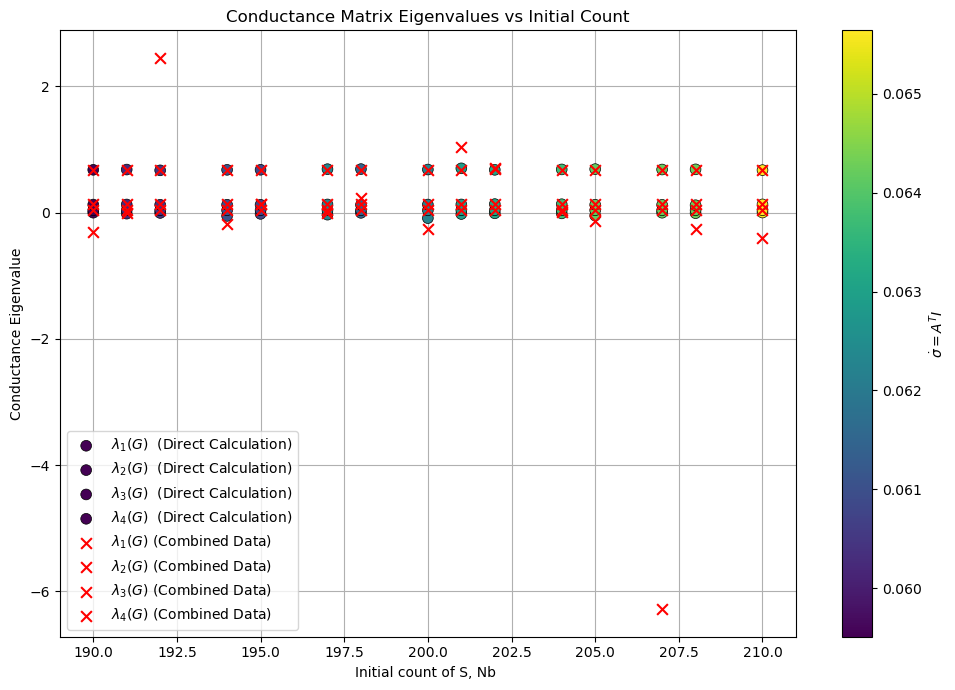

In [75]:
DN_SSA.plot_conductance(analytical_G=eigs,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=False,
        show_difference=True
    )

In [71]:
eigs = []

for i in range(0,15):

    step3_numerical_RM_np = np.array(J3_CMs[i].tolist(), dtype=float)
    direct_RM_np          = np.array(DN_CMs[0][i].tolist(), dtype=float)

    eigs_comb = np.sort(np.linalg.eigvals(step3_numerical_RM_np).real)
    eigs_dir  = np.sort(np.linalg.eigvals(direct_RM_np).real)
    
    eigs.append(eigs_comb)
    print("Eigenvalues (modular):", eigs_comb)
    print("Eigenvalues (direct): ", eigs_dir)
    print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=0.1))

Eigenvalues (modular): [-0.31357459  0.03850183  0.13307707  0.66905592]
Eigenvalues (direct):  [-3.64373248e-04  3.74786843e-02  1.28497627e-01  6.78764519e-01]
Match: False
Eigenvalues (modular): [-0.00784989  0.03856214  0.1361176   0.68254002]
Eigenvalues (direct):  [-0.01570606  0.03783996  0.12969858  0.68278329]
Match: False
Eigenvalues (modular): [0.03763564 0.13704143 0.67683021 2.4514744 ]
Eigenvalues (direct):  [-0.00451518  0.0378003   0.12545118  0.6705349 ]
Match: False
Eigenvalues (modular): [-0.17460623  0.03862872  0.13285555  0.6720935 ]
Eigenvalues (direct):  [-0.0515208   0.03769482  0.12608604  0.67834509]
Match: False
Eigenvalues (modular): [0.03809486 0.13849429 0.14143045 0.67060355]
Eigenvalues (direct):  [-0.0191528   0.03755651  0.12525263  0.67956814]
Match: False
Eigenvalues (modular): [-0.00137334  0.03916798  0.13279084  0.67551   ]
Eigenvalues (direct):  [-0.03157468  0.03779457  0.13037291  0.68912032]
Match: False
Eigenvalues (modular): [0.03852476 0.1

Combined eigenvalues:  [0.00924644 0.04441895 0.18419939 0.68590613]
Direct   eigenvalues:  [-0.01839482  0.0376322   0.13672572  0.68440482]
Max absolute diff:     0.047473662473319744
Max relative diff:     1.5026656020556166
Matrices match:        False


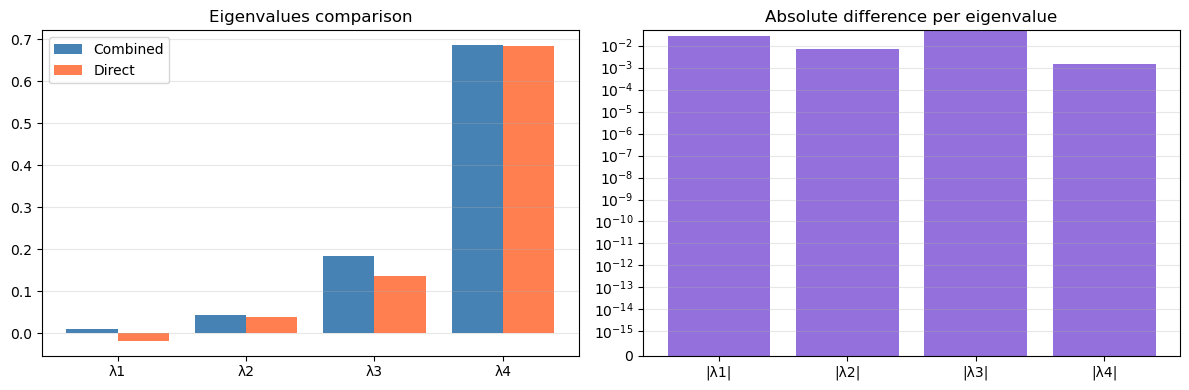

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def clean_matrix(mat, threshold=1e-14):
    """Replace near-zero, NaN, and Inf values."""
    mat = np.array(mat, dtype=complex)
    mat = np.where(np.isnan(mat), 0, mat)
    mat = np.where(np.isinf(mat), 0, mat)
    mat = np.where(np.abs(mat) < threshold, 0, mat)
    return mat

def get_eigenvalues(mat, threshold=1e-14):
    mat = clean_matrix(mat, threshold)
    eigs = np.linalg.eigvals(mat)
    eigs = np.where(np.abs(eigs.real) < threshold, 0, eigs.real)
    return np.sort(eigs.real)

# Matrices here
comb_matrix  = np.array(J3_CMs[0].tolist(), dtype=float)
direct_matrix = np.array(DN_CMs[0][0].tolist(), dtype=float)

comb_evals  = get_eigenvalues(comb_matrix)
direct_evals = get_eigenvalues(direct_matrix)

print("Combined eigenvalues: ", comb_evals)
print("Direct   eigenvalues: ", direct_evals)
print("Max absolute diff:    ", np.max(np.abs(comb_evals - direct_evals)))
print("Max relative diff:    ", np.max(np.abs(comb_evals - direct_evals) / (np.abs(direct_evals) + 1e-30)))
print("Matrices match:       ", np.allclose(comb_evals, direct_evals, atol=1e-10))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(comb_evals))
axes[0].bar(x - 0.2, comb_evals,  0.4, label='Combined',  color='steelblue')
axes[0].bar(x + 0.2, direct_evals, 0.4, label='Direct',    color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'λ{i+1}' for i in x])
axes[0].set_title('Eigenvalues comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

diff = np.abs(comb_evals - direct_evals)
axes[1].bar(x, diff, color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'|λ{i+1}|' for i in x])
axes[1].set_title('Absolute difference per eigenvalue')
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Just M1 and M2

In [126]:
# Define Modules

initial_counts_1_2 = [150, 50, 30, 152, 146] # Na = 146
# initial_counts_1_2 = [150, 50, 30, 152, 13]

rates_1_2 = np.array([0.0005, 0.006, 0.010, 0.001, 0.0005, 0.008])
# test with increaed A1 production
# rates_1_2 = np.array([0.00005, 0.06, 0.010, 0.001, 0.0005, 0.008])


Small_SIM_1 = RunSSA(module1, initial_counts_1_2, rates_1_2, simulation_length, burn_in)


initial_counts2_1_2 = [50, 50, 50, 80, 146, 100, 200, 80] # Na = 146
# initial_counts2_1_2 = [50, 50, 50, 80, 13, 100, 200, 80] # Na = 13

rates2_1_2 = np.array([0.0002, 0.010, 0.004, 0.004, 0.015, 0.0005, 0.0002, 0.012, 0.015, 0.0005])

Small_SIM_2 = RunSSA(module2, initial_counts2_1_2, rates2_1_2, simulation_length,burn_in)



In [127]:
Joint_Network_ = CombiningModules(module1,module2)

new_comb_counts, new_comb_rates = Joint_Network_.build_combined_initial_counts_and_rates(initial_counts_1_2, initial_counts2_1_2, rates_1_2, rates2_1_2)

direct_JN_new = ModuleProperties(Joint_Network_.stoich_matrix, Joint_Network_.num_internal_species, Joint_Network_.species_names)

direct_JN_new_SIM = RunSSA(direct_JN_new, new_comb_counts, new_comb_rates, 2000, 1000)

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

In [128]:
Small_SIM_1.run_IF_sweep([3], [np.linspace(130,170,20,dtype=int)], 300 , covariance_reaction_indices=[0], verbose=True) # vary S
Small_SIM_2.run_IF_sweep([0], [np.linspace(50,50,20,dtype=int)], 300 , covariance_reaction_indices=None, verbose=True) # vary nothing
direct_JN_new_SIM.run_IF_sweep([8], [np.linspace(130,170,20,dtype=int)], 300, covariance_reaction_indices=None, verbose=True) # vary S 

Sweep 1/20  ([S] = 130)
Sweep 2/20  ([S] = 132)
Sweep 3/20  ([S] = 134)
Sweep 4/20  ([S] = 136)
Sweep 5/20  ([S] = 138)
Sweep 6/20  ([S] = 140)
Sweep 7/20  ([S] = 142)
Sweep 8/20  ([S] = 144)
Sweep 9/20  ([S] = 146)
Sweep 10/20  ([S] = 148)
Sweep 11/20  ([S] = 151)
Sweep 12/20  ([S] = 153)
Sweep 13/20  ([S] = 155)
Sweep 14/20  ([S] = 157)
Sweep 15/20  ([S] = 159)
Sweep 16/20  ([S] = 161)
Sweep 17/20  ([S] = 163)
Sweep 18/20  ([S] = 165)
Sweep 19/20  ([S] = 167)
Sweep 20/20  ([S] = 170)
Total sweep time: 22.69 s
Sweep 1/20  ([B1] = 50)
Sweep 2/20  ([B1] = 50)
Sweep 3/20  ([B1] = 50)
Sweep 4/20  ([B1] = 50)
Sweep 5/20  ([B1] = 50)
Sweep 6/20  ([B1] = 50)
Sweep 7/20  ([B1] = 50)
Sweep 8/20  ([B1] = 50)
Sweep 9/20  ([B1] = 50)
Sweep 10/20  ([B1] = 50)
Sweep 11/20  ([B1] = 50)
Sweep 12/20  ([B1] = 50)
Sweep 13/20  ([B1] = 50)
Sweep 14/20  ([B1] = 50)
Sweep 15/20  ([B1] = 50)
Sweep 16/20  ([B1] = 50)
Sweep 17/20  ([B1] = 50)
Sweep 18/20  ([B1] = 50)
Sweep 19/20  ([B1] = 50)
Sweep 20/20  ([B1

(array([[-0.02699939, -0.02399946, -0.00199995, ...,  0.01099975,
         -0.01199973, -0.01099975],
        [-0.00899998, -0.00899998, -0.00699998, ...,  0.04999986,
         -0.00399999,  0.00399999],
        [ 0.00099983,  0.00099983,  0.00399932, ...,  0.01699713,
         -0.01099814, -0.00899848],
        ...,
        [-0.00699948, -0.00599955,  0.01299903, ...,  0.03399746,
         -0.00899933, -0.00499963],
        [-0.02199672, -0.01999702, -0.01199821, ...,  0.03299508,
          0.00699896, -0.01399791],
        [-0.00499955, -0.00499955, -0.00199982, ...,  0.05099538,
         -0.01299882, -0.01399873]]),
 array([[ 0.1133986 , -0.13900514, -0.01441848, ...,  0.04340675,
          0.00539595, -0.02438952],
        [ 0.10343481, -0.16317495, -0.06212825, ...,  0.08275632,
          0.00052448,  0.0003883 ],
        [ 0.10568437, -0.13291914, -0.06918412, ...,  0.02712754,
         -0.01440742,  0.04038208],
        ...,
        [ 0.11171813, -0.11277534, -0.07483219, ...,  

No difference plotted: Option Deprecated


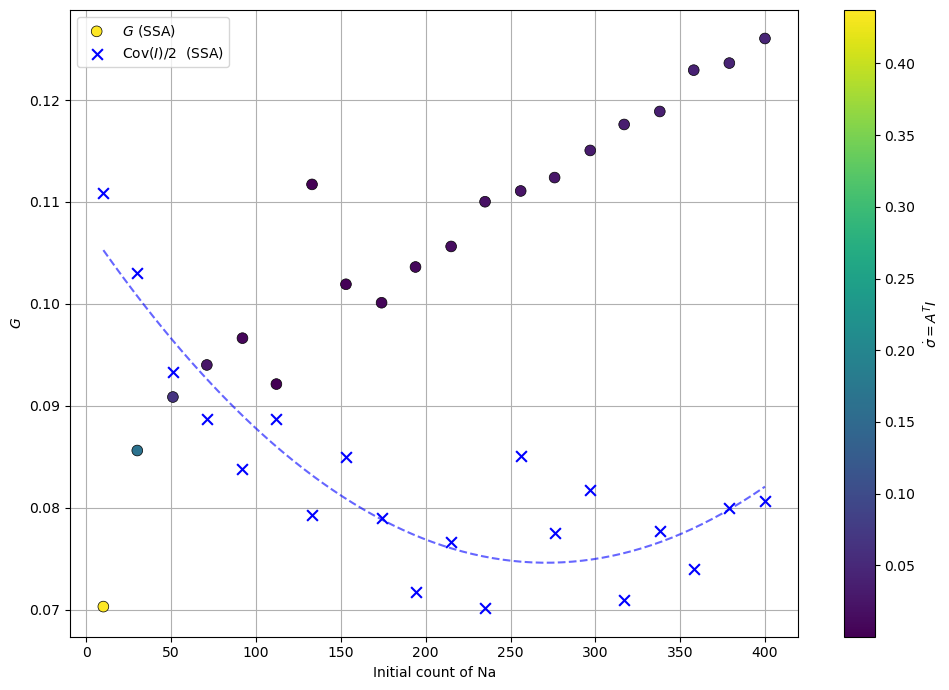

In [76]:
Small_SIM_1.compute_conductances()
Small_SIM_1.plot_conductance(analytical_G=None,show_covariance=True)

A1 mean: 3.04
A1 min:  0
Fraction of time A1=0: 0.213
A1 CV: 3.658


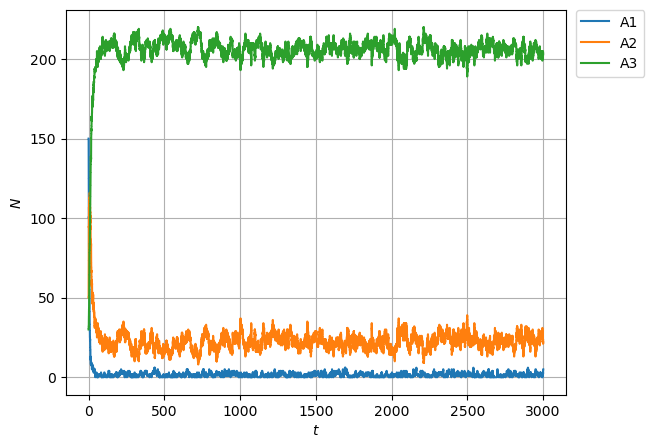

In [134]:
# How often is A1 = 0 exactly?

Small_SIM_1.run_SSA_and_plot_counts(True,True)
A1_traj = Small_SIM_1.pop_history[:, 0]
print(f"A1 mean: {np.mean(A1_traj):.2f}")
print(f"A1 min:  {np.min(A1_traj):.0f}")
print(f"Fraction of time A1=0: {np.mean(A1_traj == 0):.3f}")
print(f"A1 CV: {np.std(A1_traj)/np.mean(A1_traj):.3f}")

In [129]:
mod1_cMs, _ =Small_SIM_1.compute_conductances() 
mod2_cMs, _ =Small_SIM_2.compute_conductances()
mod3_cMs, _ =direct_JN_new_SIM.compute_conductances()

Joint_Network_ = CombiningModules(module1,module2, mod1_cMs, mod2_cMs)
JN_CM_new = Joint_Network_.numerical_combined_fundamental_CMs

Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=3
So M3 reaction c1 → r4, c2 → r5, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['S', 'Na']
right_ext_names_list: ['Na', 'Nb', 'F', 'W']
interface_names:      ['Na']
left_free_rows:       [0]
right_free_rows: 

In [135]:
eigs_new = []

for i in range(len(JN_CM_new)):

    step3_numerical_RM_np = np.array(JN_CM_new[i].tolist(), dtype=float)
    direct_RM_np          = np.array(mod3_cMs[i].tolist(), dtype=float)

    eigs_comb = np.sort(np.linalg.eigvals(step3_numerical_RM_np).real)
    eigs_dir  = np.sort(np.linalg.eigvals(direct_RM_np).real)
    
    eigs_new.append(eigs_comb)
    print("Eigenvalues (modular):", eigs_comb)
    print("Eigenvalues (direct): ", eigs_dir)
    print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=0.1))

Eigenvalues (modular): [0.0520206  0.16960609]
Eigenvalues (direct):  [0.05103219 0.17139861]
Match: True
Eigenvalues (modular): [0.05157408 0.1654938 ]
Eigenvalues (direct):  [0.05324244 0.16981154]
Match: True
Eigenvalues (modular): [0.05131764 0.16521806]
Eigenvalues (direct):  [0.0513088  0.16388232]
Match: True
Eigenvalues (modular): [0.05202222 0.16823785]
Eigenvalues (direct):  [0.05124424 0.16222104]
Match: True
Eigenvalues (modular): [0.05045311 0.16401653]
Eigenvalues (direct):  [0.05193017 0.1676407 ]
Match: True
Eigenvalues (modular): [0.05090971 0.16255656]
Eigenvalues (direct):  [0.05020581 0.16799584]
Match: True
Eigenvalues (modular): [0.05279428 0.16611069]
Eigenvalues (direct):  [0.05221704 0.16471437]
Match: True
Eigenvalues (modular): [0.04992505 0.15865444]
Eigenvalues (direct):  [0.0514741  0.16672327]
Match: True
Eigenvalues (modular): [0.04978201 0.15865151]
Eigenvalues (direct):  [0.04903698 0.15955823]
Match: True
Eigenvalues (modular): [0.05197211 0.16565759]

In [88]:
display(direct_JN_new.cycle_matrix)
direct_JN_new.species_names

⎡0  1 ⎤
⎢     ⎥
⎢0  1 ⎥
⎢     ⎥
⎢0  0 ⎥
⎢     ⎥
⎢1  0 ⎥
⎢     ⎥
⎢1  -1⎥
⎢     ⎥
⎢1  0 ⎥
⎢     ⎥
⎢0  1 ⎥
⎢     ⎥
⎣0  1 ⎦

['A1', 'A2', 'A3', 'Na', 'B1', 'B2', 'B3', 'B4', 'S', 'Nb', 'F', 'W']

In [124]:
G_fund_numerical_ex1 = np.array(mod3_cMs[10].tolist(), dtype=float)
eigenvalues, eigenvectors = np.linalg.eigh(G_fund_numerical_ex1)

idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

force_labels = ['S/Nb', 'F/W']
print("Mode assignments Direct:")
for k in range(2):
    # dominant component of eigenvector tells you which force drives this mode
    dominant = np.argmax(np.abs(eigenvectors[:, k]))
    print(f"  λ({k+1}) = {eigenvalues[k]:.4f} "
          f"| dominant force: {force_labels[dominant]} "
          f"| eigenvector: {eigenvectors[:, k]}")

G_fund_numerical_ex2 = np.array(JN_CM_new[10].tolist(), dtype=float)
eigenvalues, eigenvectors = np.linalg.eigh(G_fund_numerical_ex2)

idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

force_labels = ['S/Nb', 'F/W']
print("Mode assignments combined:")
for k in range(2):
    # dominant component of eigenvector tells you which force drives this mode
    dominant = np.argmax(np.abs(eigenvectors[:, k]))
    print(f"  λ({k+1}) = {eigenvalues[k]:.4f} "
          f"| dominant force: {force_labels[dominant]} "
          f"| eigenvector: {eigenvectors[:, k]}")

Mode assignments Direct:
  λ(1) = 0.2335 | dominant force: F/W | eigenvector: [0.52625846 0.85032466]
  λ(2) = 0.0751 | dominant force: S/Nb | eigenvector: [-0.85032466  0.52625846]
Mode assignments combined:
  λ(1) = 0.2336 | dominant force: F/W | eigenvector: [0.52614451 0.85039517]
  λ(2) = 0.0750 | dominant force: S/Nb | eigenvector: [-0.85039517  0.52614451]


In [125]:
JN_CM_A11 = JN_CM_new
mod3_cMsA11 = mod3_cMs

In [131]:
mod3_cMs_old = mod3_cMs
JN_CM_old = JN_CM_new

In [138]:
results = {}
mean_eigenvalues = {}

for regime_name, (direct_cms, combined_cms) in {
    'A1≈3':  (mod3_cMs_old, JN_CM_old),
    'A1≈11': (mod3_cMsA11,  JN_CM_A11),
}.items():

    results[regime_name] = {}
    mean_eigenvalues[regime_name] = {}

    for method_name, cms in {'Direct': direct_cms,
                              'Combined': combined_cms}.items():

        all_evecs    = np.zeros((len(cms), 2, 2))
        all_eigs     = np.zeros((len(cms), 2))

        for i in range(len(cms)):
            G = np.array(cms[i].tolist(), dtype=float)
            eigenvalues, eigenvectors = np.linalg.eigh(G)
            idx = np.argsort(np.abs(eigenvalues))[::-1]
            eigenvalues  = eigenvalues[idx]
            eigenvectors = eigenvectors[:, idx]
            all_evecs[i] = eigenvectors.T
            all_eigs[i]  = eigenvalues

        mean_evecs = np.mean(all_evecs, axis=0)
        mean_eigs  = np.mean(all_eigs,  axis=0)

        results[regime_name][method_name]      = mean_evecs
        mean_eigenvalues[regime_name][method_name] = mean_eigs

        print(f"\n{regime_name} | {method_name}:")
        print(f"  Mean eigenvalues: λ(1)={mean_eigs[0]:.4f}, λ(2)={mean_eigs[1]:.4f}")
        for k in range(2):
            dominant = np.argmax(np.abs(mean_evecs[k]))
            angle = np.degrees(np.arctan2(
                np.abs(mean_evecs[k][1]),
                np.abs(mean_evecs[k][0])
            ))
            print(f"  λ({k+1}) | dominant: {force_labels[dominant]} "
                  f"| evec: {np.round(mean_evecs[k], 4)} "
                  f"| mixing angle: {angle:.1f}°")

print("\n=== EIGENVALUE SUMMARY ===")
print(f"{'':20} {'λ(1)':>10} {'λ(2)':>10} {'λ(1)-λ(2)':>12}")
for regime in ['A1≈3', 'A1≈11']:
    for method_name in ['Direct', 'Combined']:
        eigs = mean_eigenvalues[regime][method_name]
        print(f"{regime} | {method_name}:{'':4} "
              f"{eigs[0]:>10.4f} "
              f"{eigs[1]:>10.4f} "
              f"{eigs[0]-eigs[1]:>12.4f}")
    print()

print("\n=== MIXING ANGLE SUMMARY ===")
print(f"{'':20} {'Direct':>12} {'Combined':>12} {'Difference':>12}")
for regime in ['A1≈3', 'A1≈11']:
    for k in range(2):
        d_angle = np.degrees(np.arctan2(
            np.abs(results[regime]['Direct'][k][1]),
            np.abs(results[regime]['Direct'][k][0])
        ))
        c_angle = np.degrees(np.arctan2(
            np.abs(results[regime]['Combined'][k][1]),
            np.abs(results[regime]['Combined'][k][0])
        ))
        print(f"{regime} λ({k+1}):{'':8} "
              f"{d_angle:>12.1f}° "
              f"{c_angle:>12.1f}° "
              f"{abs(d_angle-c_angle):>12.2f}°")


A1≈3 | Direct:
  Mean eigenvalues: λ(1)=0.1640, λ(2)=0.0511
  λ(1) | dominant: F/W | evec: [0.4807 0.8766] | mixing angle: 61.3°
  λ(2) | dominant: S/Nb | evec: [-0.8766  0.4807] | mixing angle: 28.7°

A1≈3 | Combined:
  Mean eigenvalues: λ(1)=0.1646, λ(2)=0.0514
  λ(1) | dominant: F/W | evec: [0.4863 0.8737] | mixing angle: 60.9°
  λ(2) | dominant: S/Nb | evec: [-0.8737  0.4863] | mixing angle: 29.1°

A1≈11 | Direct:
  Mean eigenvalues: λ(1)=0.2339, λ(2)=0.0752
  λ(1) | dominant: F/W | evec: [0.5255 0.8508] | mixing angle: 58.3°
  λ(2) | dominant: S/Nb | evec: [-0.8508  0.5255] | mixing angle: 31.7°

A1≈11 | Combined:
  Mean eigenvalues: λ(1)=0.2343, λ(2)=0.0754
  λ(1) | dominant: F/W | evec: [0.526  0.8504] | mixing angle: 58.3°
  λ(2) | dominant: S/Nb | evec: [-0.8504  0.526 ] | mixing angle: 31.7°

=== EIGENVALUE SUMMARY ===
                           λ(1)       λ(2)    λ(1)-λ(2)
A1≈3 | Direct:         0.1640     0.0511       0.1129
A1≈3 | Combined:         0.1646     0.0514      

In [165]:
results = {}
mean_eigenvalues = {}
all_eigs_store   = {}

for regime_name, (direct_cms, combined_cms) in {
    'A1≈3':  (mod3_cMs_old, JN_CM_old),
    'A1≈11': (mod3_cMsA11,  JN_CM_A11),
}.items():

    results[regime_name]           = {}
    mean_eigenvalues[regime_name]  = {}
    all_eigs_store[regime_name]    = {}

    for method_name, cms in {'Direct': direct_cms,
                              'Combined': combined_cms}.items():

        all_evecs = np.zeros((len(cms), 2, 2))
        all_eigs  = np.zeros((len(cms), 2))

        for i in range(len(cms)):
            G = np.array(cms[i].tolist(), dtype=float)
            eigenvalues, eigenvectors = np.linalg.eigh(G)
            idx = np.argsort(np.abs(eigenvalues))[::-1]
            eigenvalues  = eigenvalues[idx]
            eigenvectors = eigenvectors[:, idx]
            all_evecs[i] = eigenvectors.T
            all_eigs[i]  = eigenvalues

        mean_evecs = np.mean(all_evecs, axis=0)
        mean_eigs  = np.mean(all_eigs,  axis=0)

        results[regime_name][method_name]          = mean_evecs
        mean_eigenvalues[regime_name][method_name] = mean_eigs
        all_eigs_store[regime_name][method_name]   = all_eigs

        print(f"\n{regime_name} | {method_name}:")
        print(f"  Mean eigenvalues: λ(1)={mean_eigs[0]:.4f}, λ(2)={mean_eigs[1]:.4f}")
        for k in range(2):
            dominant = np.argmax(np.abs(mean_evecs[k]))
            angle = np.degrees(np.arctan2(
                np.abs(mean_evecs[k][1]),
                np.abs(mean_evecs[k][0])
            ))
            print(f"  λ({k+1}) | dominant: {force_labels[dominant]} "
                  f"| evec: {np.round(mean_evecs[k], 4)} "
                  f"| mixing angle: {angle:.1f}°")

print("\n=== EIGENVALUE SUMMARY ===")
print(f"{'':20} {'λ(1)':>10} {'λ(2)':>10} {'λ(1)-λ(2)':>12}")
for regime in ['A1≈3', 'A1≈11']:
    for method_name in ['Direct', 'Combined']:
        eigs = mean_eigenvalues[regime][method_name]
        print(f"{regime} | {method_name}:{'':4} "
              f"{eigs[0]:>10.4f} "
              f"{eigs[1]:>10.4f} "
              f"{eigs[0]-eigs[1]:>12.4f}")
    print()

print("\n=== MIXING ANGLE SUMMARY ===")
print(f"{'':20} {'Direct':>12} {'Combined':>12} {'Difference':>12}")
for regime in ['A1≈3', 'A1≈11']:
    for k in range(2):
        d_angle = np.degrees(np.arctan2(
            np.abs(results[regime]['Direct'][k][1]),
            np.abs(results[regime]['Direct'][k][0])
        ))
        c_angle = np.degrees(np.arctan2(
            np.abs(results[regime]['Combined'][k][1]),
            np.abs(results[regime]['Combined'][k][0])
        ))
        print(f"{regime} λ({k+1}):{'':8} "
              f"{d_angle:>12.1f}° "
              f"{c_angle:>12.1f}° "
              f"{abs(d_angle-c_angle):>12.2f}°")

# ── CV justification for S-averaging ─────────────────────────
print("\n=== EIGENVALUE STABILITY ACROSS S SWEEP ===")
print(f"{'':30} {'mean':>10} {'std':>10} {'CV (%)':>10}")
for regime in ['A1≈3', 'A1≈11']:
    print(f"\n{regime}:")
    for method_name in ['Direct', 'Combined']:
        eigs = all_eigs_store[regime][method_name]
        for k in range(2):
            mean_e = np.mean(eigs[:, k])
            std_e  = np.std(eigs[:, k])
            cv     = std_e / mean_e * 100
            print(f"  {method_name} λ({k+1}):{'':8} "
                  f"{mean_e:>10.4f} "
                  f"{std_e:>10.4f} "
                  f"{cv:>10.2f}%")


A1≈3 | Direct:
  Mean eigenvalues: λ(1)=0.1640, λ(2)=0.0511
  λ(1) | dominant: F/W | evec: [0.4807 0.8766] | mixing angle: 61.3°
  λ(2) | dominant: S/Nb | evec: [-0.8766  0.4807] | mixing angle: 28.7°

A1≈3 | Combined:
  Mean eigenvalues: λ(1)=0.1646, λ(2)=0.0514
  λ(1) | dominant: F/W | evec: [0.4863 0.8737] | mixing angle: 60.9°
  λ(2) | dominant: S/Nb | evec: [-0.8737  0.4863] | mixing angle: 29.1°

A1≈11 | Direct:
  Mean eigenvalues: λ(1)=0.2339, λ(2)=0.0752
  λ(1) | dominant: F/W | evec: [0.5255 0.8508] | mixing angle: 58.3°
  λ(2) | dominant: S/Nb | evec: [-0.8508  0.5255] | mixing angle: 31.7°

A1≈11 | Combined:
  Mean eigenvalues: λ(1)=0.2343, λ(2)=0.0754
  λ(1) | dominant: F/W | evec: [0.526  0.8504] | mixing angle: 58.3°
  λ(2) | dominant: S/Nb | evec: [-0.8504  0.526 ] | mixing angle: 31.7°

=== EIGENVALUE SUMMARY ===
                           λ(1)       λ(2)    λ(1)-λ(2)
A1≈3 | Direct:         0.1640     0.0511       0.1129
A1≈3 | Combined:         0.1646     0.0514      

Running 1000 SSA iterations via run_IF_sweep...
Sweep 1/1  ([A1] = 150)
Total sweep time: 14.93 s
Computing conductance matrices per iteration...
Done. Skipped 113/1000 runs (None G matrix).
Valid runs: 887/1000
Kept 794/887 runs after outlier rejection
Removed 93 outliers
Clean λ(1): 0.1591 ± 0.0763
Clean λ(2): 0.0466 ± 0.0225
Clean gap:  0.1125 ± 0.0666


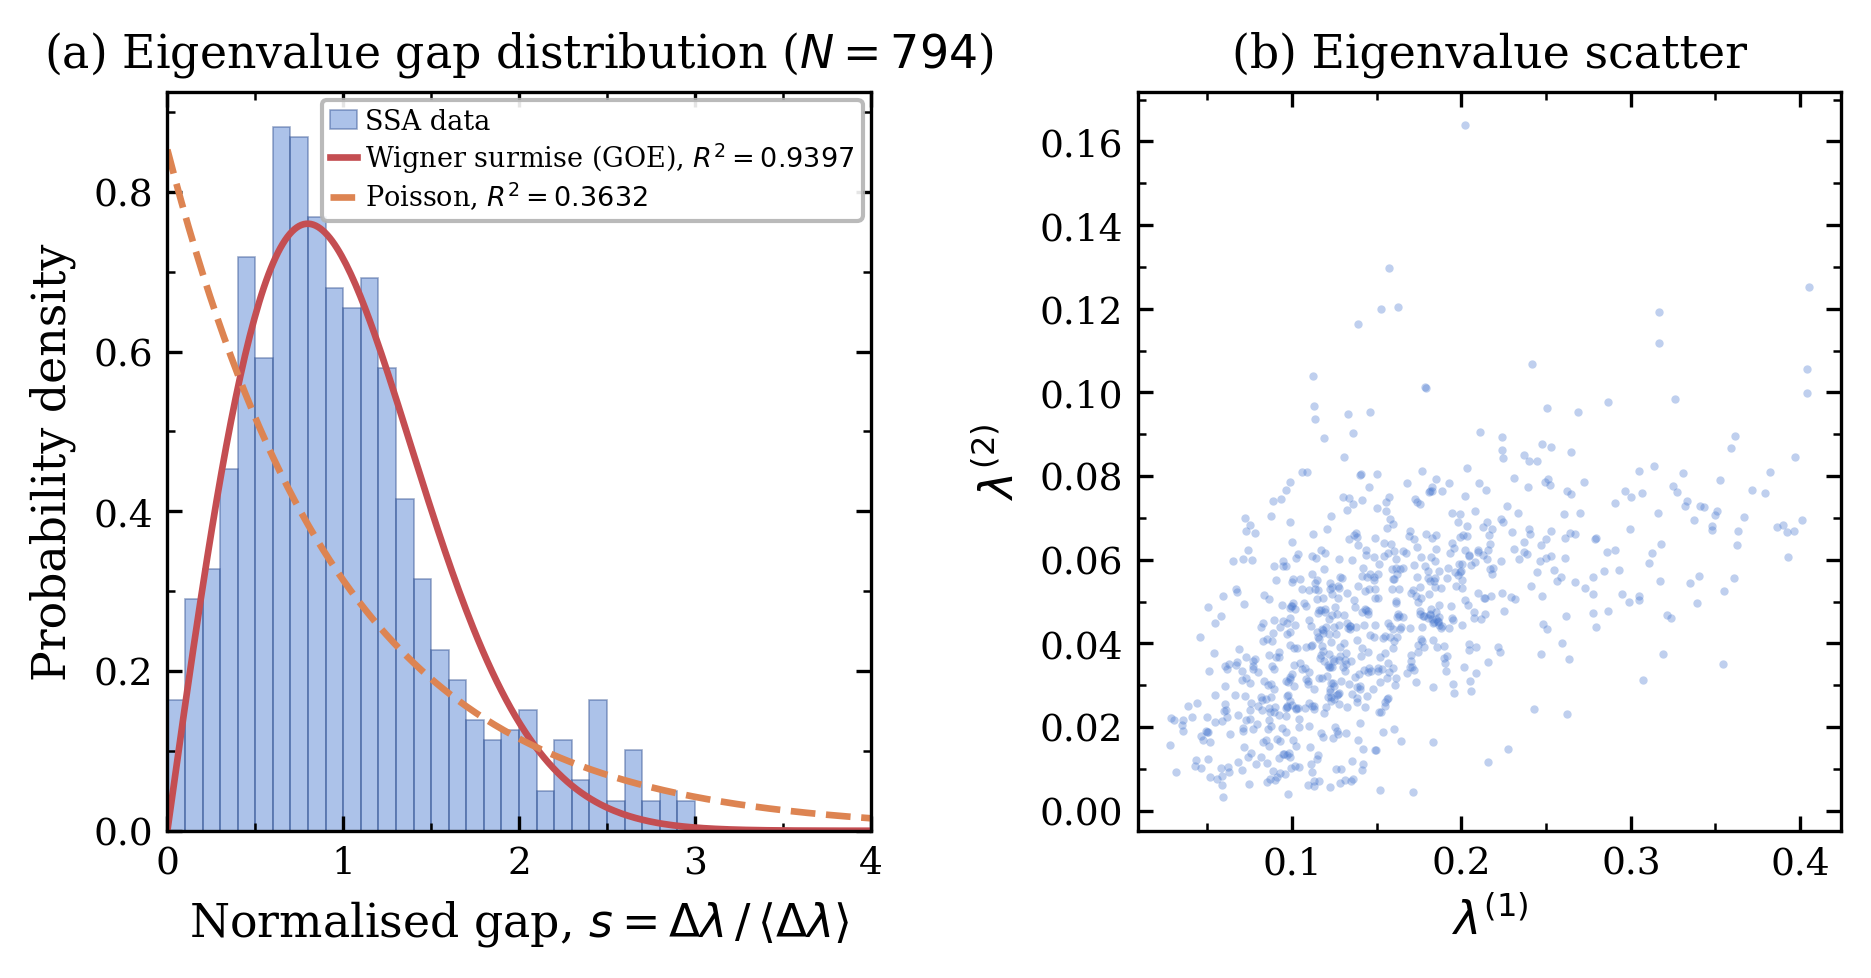


Wigner surmise (GOE) R²: 0.9397
Poisson R²:              0.3632
Better fit: Wigner (GOE)


In [178]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from scipy.stats import median_abs_deviation

# ── Parameters ────────────────────────────────────────────────
K = 1000
print(f"Running {K} SSA iterations via run_IF_sweep...")

currents_block, forces_block = direct_JN_new_SIM.run_IF_sweep(
    species_index=[0],
    count_values=[np.array([150])],  # fixed S=150
    total_iterations=K,
    verbose=True
)

print("Computing conductance matrices per iteration...")
gaps     = np.zeros(K)
lambda1s = np.zeros(K)
lambda2s = np.zeros(K)
skipped  = 0

for it in range(K):
    direct_JN_new_SIM.sweep_I_means = currents_block[it:it+1, :]
    direct_JN_new_SIM.sweep_F_means = forces_block[it:it+1, :]

    G, _ = direct_JN_new_SIM.compute_conductances()

    if G is None or G[0] is None:
        skipped += 1
        continue

    G_np = np.array(G[0].tolist(), dtype=float)

    eigs = np.sort(np.abs(np.linalg.eigvals(G_np)))[::-1]
    lambda1s[it] = eigs[0]
    lambda2s[it] = eigs[1]
    gaps[it]     = eigs[0] - eigs[1]

print(f"Done. Skipped {skipped}/{K} runs (None G matrix).")

# ── Outlier rejection ─────────────────────────────────────────
mask     = gaps > 0
gaps     = gaps[mask]
lambda1s = lambda1s[mask]
lambda2s = lambda2s[mask]
K_valid  = len(gaps)
print(f"Valid runs: {K_valid}/{K}")

mad = median_abs_deviation(gaps)
med = np.median(gaps)
mask_clean = np.abs(gaps - med) < 5 * mad

gaps_clean     = gaps[mask_clean]
lambda1s_clean = lambda1s[mask_clean]
lambda2s_clean = lambda2s[mask_clean]
K_clean        = len(gaps_clean)

print(f"Kept {K_clean}/{K_valid} runs after outlier rejection")
print(f"Removed {K_valid - K_clean} outliers")
print(f"Clean λ(1): {np.mean(lambda1s_clean):.4f} ± {np.std(lambda1s_clean):.4f}")
print(f"Clean λ(2): {np.mean(lambda2s_clean):.4f} ± {np.std(lambda2s_clean):.4f}")
print(f"Clean gap:  {np.mean(gaps_clean):.4f} ± {np.std(gaps_clean):.4f}")

# ── Normalise ─────────────────────────────────────────────────
s = gaps_clean / np.mean(gaps_clean)

# ── Fit functions ─────────────────────────────────────────────
def wigner_surmise_fixed(s):
    return (np.pi / 2) * s * np.exp(-np.pi / 4 * s**2)

bins  = 40
s_max = 4.0

poisson_norm = 1 - np.exp(-s_max)
def poisson_dist_truncated(s, A):
    return A * np.exp(-s) / poisson_norm

# ── Equal truncation ──────────────────────────────────────────
s_trunc = s[s < s_max]

hist_counts, bin_edges = np.histogram(s_trunc, bins=bins,
                                       range=(0, s_max), density=True)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
s_vals      = np.linspace(0, s_max, 300)

w_pred      = wigner_surmise_fixed(bin_centres)
popt_p, _   = curve_fit(poisson_dist_truncated, bin_centres, hist_counts, p0=[1.0])

# ── R² ────────────────────────────────────────────────────────
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

r2_w = r_squared(hist_counts, w_pred)
r2_p = r_squared(hist_counts, poisson_dist_truncated(bin_centres, *popt_p))

# ── Global plot style ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.labelsize':    11,
    'axes.titlesize':    11,

    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'lines.linewidth':   1.5,
    'figure.dpi':        300,
})

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
fig.subplots_adjust(wspace=0.38)

# ── Panel (a): gap distribution ───────────────────────────────
ax = axes[0]

ax.hist(s_trunc, bins=bins, range=(0, s_max),
        density=True,
        color='#4878CF', alpha=0.45,
        edgecolor='#2a4a8a', linewidth=0.4,
        label='SSA data')

ax.plot(s_vals, wigner_surmise_fixed(s_vals),
        color='#C44E52', linewidth=1.6,
        label=fr'Wigner surmise (GOE), $R^2={r2_w:.4f}$')

ax.plot(s_vals, poisson_dist_truncated(s_vals, *popt_p),
        color='#DD8452', linewidth=1.6, linestyle='--',
        label=fr'Poisson, $R^2={r2_p:.4f}$')

ax.set_xlim(0, s_max)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Normalised gap, $s = \Delta\lambda\,/\,\langle\Delta\lambda\rangle$')
ax.set_ylabel('Probability density')
ax.set_title(fr'(a) Eigenvalue gap distribution ($N = {K_clean}$)')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.legend(loc='upper right', fontsize=6.5,
          framealpha=0.9, edgecolor='0.7',
          borderpad=0.3, handlelength=1.0,
          handletextpad=0.3, labelspacing=0.2,
          borderaxespad=0.3)

# ── Panel (b): eigenvalue scatter ─────────────────────────────
ax2 = axes[1]

ax2.scatter(lambda1s_clean, lambda2s_clean,
            s=4, color='#4878CF', alpha=0.35,
            linewidths=0, rasterized=True)

ax2.set_xlabel(r'$\lambda^{(1)}$')
ax2.set_ylabel(r'$\lambda^{(2)}$')
ax2.set_title(r'(b) Eigenvalue scatter')
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# plt.savefig('rmt_eigenvalue_distribution_clean.pdf',
#             dpi=300, bbox_inches='tight')
plt.savefig('rmt_eigenvalue_distribution_clean.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\nWigner surmise (GOE) R²: {r2_w:.4f}")
print(f"Poisson R²:              {r2_p:.4f}")
print(f"Better fit: {'Wigner (GOE)' if r2_w > r2_p else 'Poisson'}")

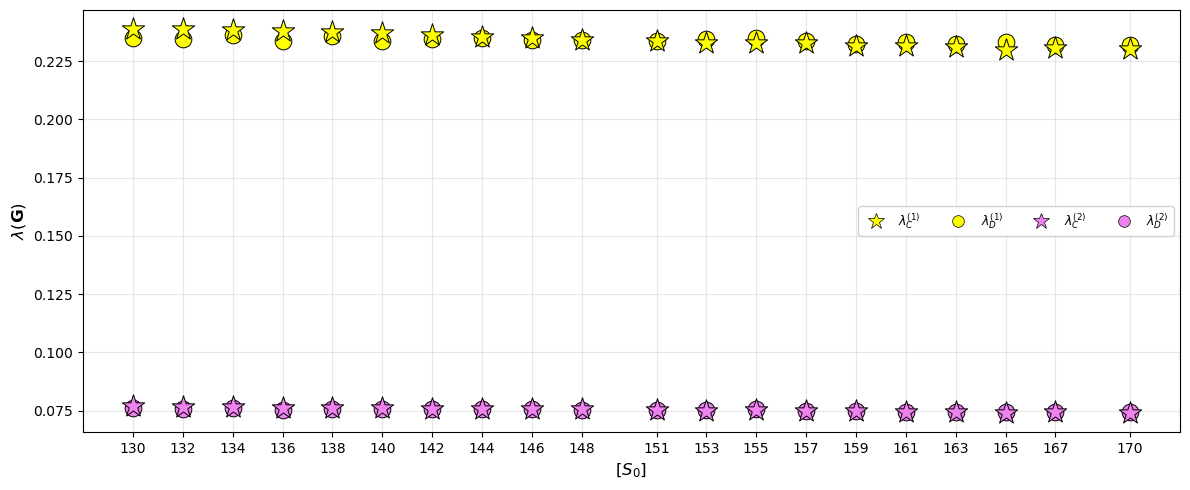

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# X axis
x = np.linspace(130,170,20,dtype=int)

# array11 = np.sort(np.abs(np.array(eigs_new)), axis=1) # combined data
# array22 = np.sort(np.abs(np.array(direct_JN_new_SIM.sweep_G_eigenvalues)), axis=1) # direct data

array11 = np.sort(np.abs(np.array(eigs_new)), axis=1)[:, ::-1]
array22 = np.sort(np.abs(np.array(direct_JN_new_SIM.sweep_G_eigenvalues)), axis=1)[:, ::-1]

n_x = len(x)
n_eig = array11.shape[1]



# ── customisation ──────────────────────────────────────────
colors        = ['yellow', 'violet', 'limegreen', 'red']
markers       = ['*', 'o']
markersize_a1 = 17
markersize_a2 = 12
edgecolor     = 'black'
linewidth     = 0.7
ev_labels     = [r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$', r'$\lambda_4$']
# ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

for i in range(n_eig):
    ax.scatter(x, array22[:, i],
               color=colors[i], marker=markers[1],
               s=markersize_a2**2, edgecolors=edgecolor,
               linewidths=linewidth, zorder=3)

for i in range(n_eig):
    ax.scatter(x, array11[:, i],
               color=colors[i], marker=markers[0],
               s=markersize_a1**2, edgecolors=edgecolor,
               linewidths=linewidth, zorder=4)
    

# custom legend
handles = []
for i in range(n_eig):
    h1 = mlines.Line2D([], [], color=colors[i], marker='*', linestyle='None',
                       markersize=markersize_a1*0.7, markeredgecolor=edgecolor,
                       markeredgewidth=0.5, label=f'$\\lambda_C^{{({i+1})}}$')
    h2 = mlines.Line2D([], [], color=colors[i], marker='o', linestyle='None',
                       markersize=markersize_a2*0.7, markeredgecolor=edgecolor,
                       markeredgewidth=0.5, label=f'$\\lambda_D^{{({i+1})}}$')
    handles.extend([h1, h2])

ax.legend(handles=handles, ncol=4, fontsize=9, loc='center right',
          framealpha=0.9)

ax.set_xlabel(r'$[{S}_0]$', fontsize=12)
ax.set_ylabel(r'$\lambda(\mathbf{G})$', fontsize=12)
ax.set_xticks(x)
# ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# plt.savefig('2mods_eval_comp.png', dpi=300, bbox_inches='tight')

plt.show()

No difference plotted: Option Deprecated.


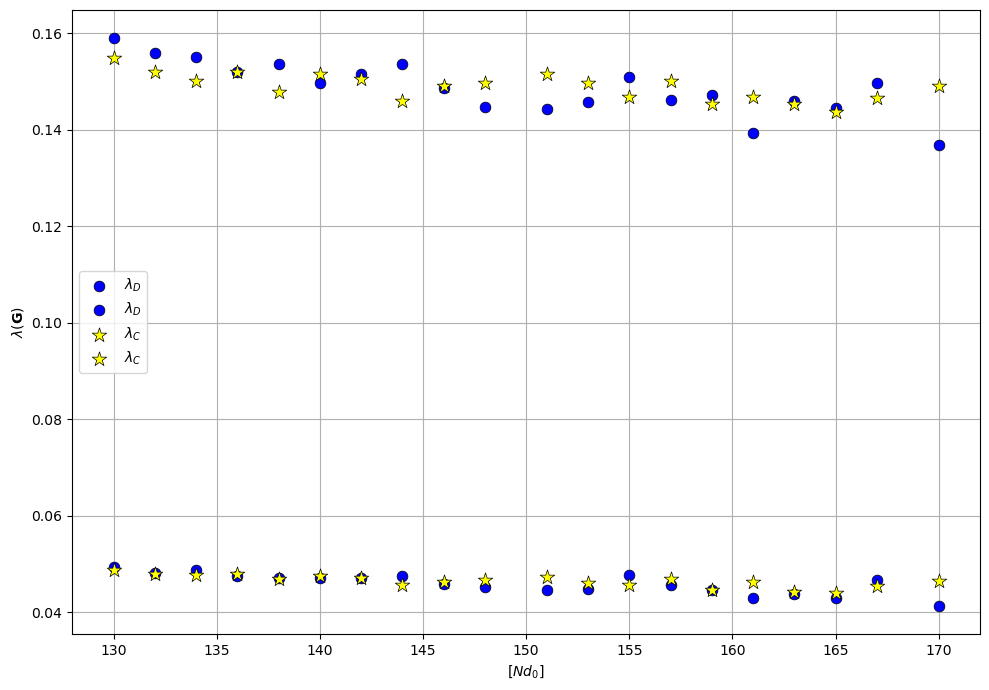

In [78]:
direct_JN_new_SIM.plot_conductance(analytical_G = eigs_new, show_covariance=False)

In [100]:
def get_steady_state_values(sim, species_of_interest, burn_in_fraction=None):
    """
    Extract steady state values by time-averaging over the post-burn-in
    portion of the trajectory.
    
    Parameters
    ----------
    sim : RunSSA
        A RunSSA object after calling run_SSA_and_plot_counts(store_trajectories=True).
    species_of_interest : list of str
        Species names to extract.
    burn_in_fraction : float or None
        If None, uses the sim's burn_in time directly.
    
    Returns
    -------
    dict : {species_name: time_averaged_count_at_steady_state}
    """
    if not hasattr(sim, 'pop_history') or not hasattr(sim, 'time_history'):
        raise RuntimeError("No pop_history/time_history found. "
                           "Call sim.run_SSA_and_plot_counts(store_trajectories=True) first.")
    
    # Get species index mapping
    name_to_idx = {name: idx for idx, name in enumerate(sim.species_names)}
    
    # Determine burn-in cutoff using the simulation's burn_in time
    if burn_in_fraction is not None:
        burn_in_time = burn_in_fraction * sim.time_history[-1]
    else:
        burn_in_time = sim.burn_in
    
    # Find index where time exceeds burn-in
    burn_in_idx = np.searchsorted(sim.time_history, burn_in_time)
    
    # Time-weighted average (proper for SSA with variable time steps)
    times_post = sim.time_history[burn_in_idx:]
    pops_post = sim.pop_history[burn_in_idx:]
    
    # Time intervals between events
    dt = np.diff(times_post)
    
    results = {}
    for species in species_of_interest:
        if species in name_to_idx:
            idx = name_to_idx[species]
            # Weight each population by the time spent in that state
            counts = pops_post[:-1, idx]  # population during each interval
            results[species] = np.sum(counts * dt) / np.sum(dt)
        else:
            print(f"Warning: '{species}' not found. Available: {sim.species_names}")
    
    return results


# --- Usage ---
repeats = 50
SS_S = []
SS_Na = []
SS_Nb = []

plt.ioff() 

for i in range(repeats):
    print(f'Repeat: {i+1}')
    
    # Must store trajectories for time-averaging
    direct_JN_new_SIM.run_SSA_and_plot_counts(store_trajectories=True)
    plt.close('all')
    
    steady_state = get_steady_state_values(direct_JN_new_SIM, ['S', 'Na', 'Nb'])
    
    # SS_.append(steady_state['S'])
    SS_Na.append(steady_state['Na'])
    # SS_Nb.append(steady_state['Nb'])

plt.ion() 

print(f"\nS  steady state: {np.mean(SS_S):.1f} ± {np.std(SS_S)/np.sqrt(repeats):.1f}")
print(f"Na steady state: {np.mean(SS_Na):.1f} ± {np.std(SS_Na)/np.sqrt(repeats):.1f}")
print(f"Nb steady state: {np.mean(SS_Nb):.1f} ± {np.std(SS_Nb)/np.sqrt(repeats):.1f}")

Repeat: 1
Repeat: 2
Repeat: 3
Repeat: 4
Repeat: 5
Repeat: 6
Repeat: 7
Repeat: 8
Repeat: 9
Repeat: 10
Repeat: 11
Repeat: 12
Repeat: 13
Repeat: 14
Repeat: 15
Repeat: 16
Repeat: 17
Repeat: 18
Repeat: 19
Repeat: 20
Repeat: 21
Repeat: 22
Repeat: 23
Repeat: 24
Repeat: 25
Repeat: 26
Repeat: 27
Repeat: 28
Repeat: 29
Repeat: 30
Repeat: 31
Repeat: 32
Repeat: 33
Repeat: 34
Repeat: 35
Repeat: 36
Repeat: 37
Repeat: 38
Repeat: 39
Repeat: 40
Repeat: 41
Repeat: 42
Repeat: 43
Repeat: 44
Repeat: 45
Repeat: 46
Repeat: 47
Repeat: 48
Repeat: 49
Repeat: 50

S  steady state: nan ± nan
Na steady state: 13.2 ± 0.1
Nb steady state: nan ± nan


# ALL 4 Modules

In [ ]:
# # Module 1: [A1, A2, A3, S, Na]
# initial_counts = [150, 50, 30, 163, 29]

# # Module 2: [B1, B2, B3, B4, Na, Nb, F, W]
# initial_counts2 = [50, 50, 50, 80, 29, 37, 200, 80]

# # Module 3: [C1, C2, C3, C4, C5, Nex, Nb, Ne, Pex, Pb, Pe]
# initial_counts3 = [100, 100, 200, 120, 50, 150, 37, 150, 80, 100, 80]

# # Module 4: [D1, D2, D3, Nd, S]
# initial_counts4 = [150, 150, 50, 200, 163]


# rates = np.array([0.0005, 0.06, 0.010, 0.001, 0.0005, 0.008])

# rates2 = np.array([0.0002, 0.010, 0.004, 0.004, 0.015, 0.0005, 0.0002, 0.012, 0.015, 0.0005])

# rates3 = np.array([0.0008, 0.003, 0.004, 0.002, 0.0002, 0.012, 0.015, 0.0005, 0.0005, 0.008, 0.010, 0.001])

# rates4 = np.array([0.0005, 0.006, 0.0005, 0.006, 0.010, 0.001, 0.008, 0.001, 0.003, 0.004])

# simulation_length = 2000.0

# burn_in = 500.0

# SIM1_fourmod = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)
# SIM2_fourmod = RunSSA(module2, initial_counts2, rates2, simulation_length, burn_in)
# SIM3_fourmod = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)
# SIM4_fourmod = RunSSA(module4, initial_counts4, rates4, simulation_length, burn_in)

In [6]:
# ── MODULE 1 ─────────────────────────────────────────────
# Cycle: a1+a2, driven by S/Na
# Target: G_cycle ≈ 8
# chi = (k1f*S + k2b*Na)/(k1b+k2f) ≈ 2 → balanced Ea/EaS

initial_counts = [150, 300, 100, 351, 400] # true SS
# initial_counts = [150, 300, 100, 338, 369] # Nb = 108
# Ea=150, EaS=300, EaS2=100, S=200, Na=200

rates = np.array([
    0.002, 0.12,   # k1f, k1b: a1
    0.08,  0.001,  # k2f, k2b: a2 — strong forward drives cycle
    0.001, 0.40,   # k3f, k3b: a3 — EXCLUDE from conductance, j=f=0
])

# Verify: chi = (0.002*200 + 0.001*200)/(0.12+0.08) = 0.6/0.2 = 3
# f1 = log(k1f*S*(k1b+k2f) / k1b*(k1f*S+k2b*Na))
#    = log(0.002*200*0.2 / 0.12*(0.4+0.2))
#    = log(0.08/0.072) = +0.105 ✓
# f2 = log(k2f*(k1f*S+k2b*Na) / k2b*Na*(k1b+k2f))  
#    = log(0.08*0.6 / 0.001*200*0.2)
#    = log(0.048/0.04) = +0.182 ✓

# ── MODULE 2 ─────────────────────────────────────────────
# Cycle 1: b1+b2+b3, driven by F/W → G_cycle ≈ 15
# Cycle 2: -b2+b4+b5, driven by Na/Nb → G_cycle ≈ 25
# Key: F large, W small → drives cycle 1 forward
#      Na large, Nb small → drives cycle 2 forward

# initial_counts2 = [200, 150, 150, 150, 369, 85, 50, 200] Nb WRONG
initial_counts2 = [200, 150, 150, 150, 400, 108, 50, 200]# Nb = 108
#                   B1   B2   B3   B4   Na   Nb  F   W
# F=50 (was 300) — this was amplifying k1b backward rate 6x
# W=200 (was 50) — this drives r3 forward (EbW→Eb+W)
# B1=200 — give it a head start

rates2 = np.array([
    0.01,  0.05,   # k1f, k1b: b1 — k1f*F*B1 = 0.01*50*200=100 vs k1b*EbF=0.05*150=7.5 ✓
    0.05,  0.01,   # k2f, k2b: b2
    0.05,  0.001,  # k3f, k3b: b3 — k3b*W=0.001*200=0.2, small ✓
    0.003, 0.05,   # k4f, k4b: b4
    0.05,  0.003,  # k5f, k5b: b5
])
# ── MODULE 3 ─────────────────────────────────────────────
# THREE INDEPENDENT cycles — each a simple 2-reaction Michaelis pair:
# Cycle 1: c1+c2 (Nex→Pex), Cycle 2: c3+c4 (Nb→Pb), Cycle 3: c5+c6 (Ne→Pe)
# This is the cleanest structure — each cycle is completely decoupled
# Make 3 cycle conductances DISTINCT by using different rate ratios

# initial_counts3 = [100, 100, 100, 100, 100, 
#                    300, 85, 300, 50, 50, 50] Nb WRONG
initial_counts3 = [100, 100, 100, 100, 100, 
                   300, 108, 300, 50, 50, 50]
# Ec=100, EcNex=100, EcNb=100, Ec*=100, Ec*Ne=100
# Nex=300, Nb=30(shared M2), Ne=300, Pex=50, Pb=50, Pe=50

rates3 = np.array([
    # Cycle 1: Nex/Pex — target G_c1 ≈ 5 (weakest)
    0.0005, 0.05,   # k1f, k1b: c1 (Nex+Ec⇌EcNex)
    0.05,   0.0005, # k2f, k2b: c2 (EcNex⇌Ec+Pex)
    # Cycle 2: Nb/Pb — target G_c2 ≈ 10
    0.001,  0.05,   # k3f, k3b: c3 (Nb+Ec⇌EcNb)
    0.05,   0.001,  # k4f, k4b: c4 (EcNb⇌Ec+Pb)
    # Cycle 3: Ne/Pe — target G_c3 ≈ 20 (strongest)
    0.002,  0.05,   # k5f, k5b: c5 (Ne+Ec*⇌Ec*Ne)
    0.05,   0.002,  # k6f, k6b: c6 (Ec*Ne⇌Ec*+Pe)
])

# Cycle forces (all 2-reaction cycles):
# f_c1 = log(k1f*k2f*Nex / k1b*k2b*Pex)
#       = log(0.0005*0.05*300 / 0.05*0.0005*50)
#       = log(7.5e-3 / 1.25e-3) = log(6) = 1.79 ✓
# f_c2 = log(0.001*0.05*30 / 0.05*0.001*50)
#       = log(1.5e-3 / 2.5e-3) = log(0.6) = -0.51 
# → Nb=30 < Pb=50 means cycle 2 runs backward! 
# Fix: Nb=100, Pb=20

# f_c2 = log(0.001*0.05*100 / 0.05*0.001*20)
#       = log(5e-3/1e-3) = log(5) = 1.61 ✓
# f_c3 = log(0.002*0.05*300 / 0.05*0.002*50)
#       = log(0.03/0.005) = log(6) = 1.79 ✓

# Note Nb=100 here but M2 uses Nb=30 — 
# in separate simulations these are independent
# In combined simulation Nb will find a dynamic SS

# ── MODULE 4 ─────────────────────────────────────────────
# Nd consumed, S produced
# CRITICAL: S appears in d3b,d4b backward reactions
# Need k3f*EdS >> k3b*Ed*S → keep S SMALL for M4 separate sim

initial_counts4 = [150, 150, 200, 200, 351]
# Ed=150, Ed*=150, EdS=200, Nd=200, S=50

rates4 = np.array([
    0.001, 0.03,   # k1f, k1b: d1 (Nd+Ed⇌EdS)
    0.001, 0.03,   # k2f, k2b: d2 (Nd+Ed*⇌EdS)
    0.06,  0.001,  # k3f, k3b: d3 (EdS⇌Ed+S) — k3b*S=0.001*50=0.05 small ✓
    0.06,  0.001,  # k4f, k4b: d4 (EdS⇌Ed*+S)
    0.04,  0.04,   # k5f, k5b: d5 (Ed⇌Ed*) — balanced, Ed≈Ed*
])

# Verify: EdS/Ed ratio:
# a1+ = k1f*Nd*Ed = 0.001*200*150 = 30
# a3+ + a4+ = (k3f+k4f)*EdS = 0.12*200 = 24
# roughly balanced ✓

# f_d3 = log(k3f*EdS / k3b*Ed*S)  
#       = log(0.06*200 / 0.001*150*50)
#       = log(12/7.5) = log(1.6) = 0.47 ✓

simulation_length = 3000.0
burn_in = 1000.0
simulation_length = 3000.0
burn_in = 1000.0

SIM1_fourmod = RunSSA(module1, initial_counts, rates, simulation_length, burn_in)
SIM2_fourmod = RunSSA(module2, initial_counts2, rates2, simulation_length, burn_in)
SIM3_fourmod = RunSSA(module3, initial_counts3, rates3, simulation_length, burn_in)
SIM4_fourmod = RunSSA(module4, initial_counts4, rates4, simulation_length, burn_in)
# Quick sanity check for each module
# for sim, name in [(SIM1_fourmod, "M1"), (SIM2_fourmod, "M2"), (SIM3_fourmod, "M3"), (SIM4_fourmod, "M4")]:
#     sim.run_SSA_and_plot_counts(store_trajectories=True)
#     means = np.mean(sim.pop_history[:, :sim.num_internal_species], axis=0)
#     print(f"\n{name} internal species means: {means}")
#     print(f"{name} min count > 0: {np.all(means > 20)}")
#     print(f"{name} currents: {sim.average_reaction_currents}")
#     print(f"{name} forces: {sim.averaged_forces}")
#     # Check no force near zero
#     print(f"{name} min |force|: {np.min(np.abs(sim.averaged_forces))}")

In [140]:
print("\n=== DETAILED EIGENVECTOR ANALYSIS ===")
print(f"Force basis: {force_labels_4mod}\n")

for k in range(4):
    evc = results_4mod['Combined'][k]
    evd = results_4mod['Direct'][k]
    lc  = mean_eigenvalues_4mod['Combined'][k]
    ld  = mean_eigenvalues_4mod['Direct'][k]

    dot        = np.abs(np.dot(evc, evd))
    angle_diff = np.degrees(np.arccos(np.clip(dot, -1, 1)))

    print(f"── Mode λ({k+1}) ──────────────────────────────────────────")
    print(f"  Eigenvalue:  Combined={lc:.4f}  Direct={ld:.4f}  "
          f"Δλ={lc-ld:+.4f}  ({(lc-ld)/ld*100:+.2f}%)")
    print(f"  Eigenvector dot product: {dot:.6f}  "
          f"angle difference: {angle_diff:.3f}°")
    print()
    print(f"  {'Force':>12} {'Combined':>12} {'Direct':>12} {'Difference':>12} {'% of mode':>12}")
    for j, label in enumerate(force_labels_4mod):
        diff    = evc[j] - evd[j]
        pct     = np.abs(evc[j]) * 100  # % contribution to combined mode
        print(f"  {label:>12} {evc[j]:>12.6f} {evd[j]:>12.6f} "
              f"{diff:>12.6f} {pct:>11.1f}%")

    # dominant and secondary forces
    sorted_idx = np.argsort(np.abs(evc))[::-1]
    print(f"\n  Dominant force:   {force_labels_4mod[sorted_idx[0]]} "
          f"({np.abs(evc[sorted_idx[0]])*100:.1f}%)")
    print(f"  Secondary force:  {force_labels_4mod[sorted_idx[1]]} "
          f"({np.abs(evc[sorted_idx[1]])*100:.1f}%)")
    print(f"  Hybridisation:    {(1 - np.max(evc**2))*100:.1f}% "
          f"(0%=pure, 50%=maximally mixed)")
    print()


=== DETAILED EIGENVECTOR ANALYSIS ===
Force basis: ['F/W', 'Nex/Pex', 'Nd/Pb', 'Ne/Pe']

── Mode λ(1) ──────────────────────────────────────────
  Eigenvalue:  Combined=3.4890  Direct=3.4877  Δλ=+0.0013  (+0.04%)
  Eigenvector dot product: 1.000000  angle difference: 0.000°

         Force     Combined       Direct   Difference    % of mode
           F/W     0.000000     0.000000     0.000000         0.0%
       Nex/Pex     0.000000     0.000000     0.000000         0.0%
         Nd/Pb     0.000000     0.000000     0.000000         0.0%
         Ne/Pe     1.000000     1.000000     0.000000       100.0%

  Dominant force:   Ne/Pe (100.0%)
  Secondary force:  Nd/Pb (0.0%)
  Hybridisation:    0.0% (0%=pure, 50%=maximally mixed)

── Mode λ(2) ──────────────────────────────────────────
  Eigenvalue:  Combined=2.4178  Direct=2.4240  Δλ=-0.0062  (-0.25%)
  Eigenvector dot product: 1.000000  angle difference: 0.000°

         Force     Combined       Direct   Difference    % of mode
        

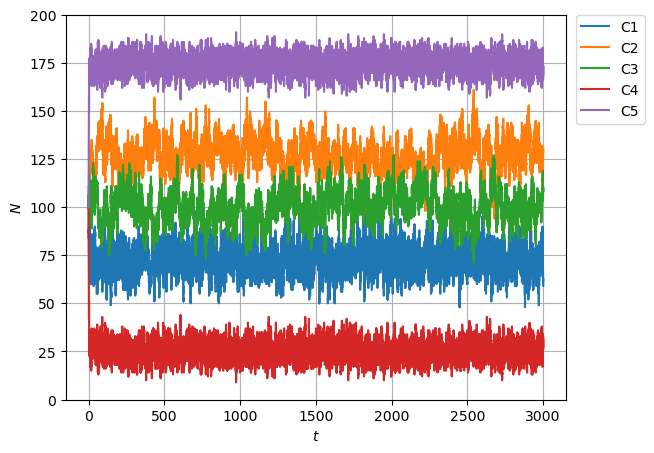

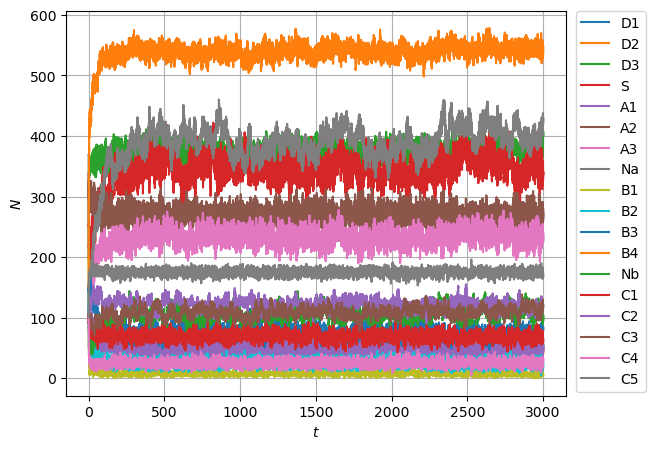

In [85]:
# SIM1_fourmod.run_SSA_and_plot_counts(True)
# SIM2_fourmod.run_SSA_and_plot_counts(True)
SIM3_fourmod.run_SSA_and_plot_counts(True)
# SIM4_fourmod.run_SSA_and_plot_counts(True)
four_mod_SIM.run_SSA_and_plot_counts(True)

In [28]:

sim1t1 = time.time()
SIM1_fourmod.run_IF_sweep([0], [np.linspace(150,150,20,dtype=int)], 75 , covariance_reaction_indices=None, verbose=True) # vary nothing
sim1t2 = time.time()

sim2t1 = time.time()
SIM2_fourmod.run_IF_sweep([0], [np.linspace(200,200,20,dtype=int)],75 , covariance_reaction_indices=None, verbose=True) # vary nothing
sim2t2 = time.time()

sim3t1 = time.time()
SIM3_fourmod.run_IF_sweep([0], [np.linspace(100,100,20,dtype=int)], 75 , covariance_reaction_indices=None, verbose=True) # vary nothing
sim3t2 = time.time()

sim4t1 = time.time()
SIM4_fourmod.run_IF_sweep([3], [np.linspace(180,210,20,dtype=int)], 75 , covariance_reaction_indices=None, verbose=True) # Vary Nd
sim4t2 = time.time()

dirett1 = time.time()
four_mod_SIM.run_IF_sweep([18], [np.linspace(180,210,20,dtype=int)], 75 , covariance_reaction_indices=None, verbose=True)
dirett2 = time.time()

print("Sim1: ",sim1t2-sim1t1 )
print("Sim2: ",sim2t2-sim1t1 )
print("Sim3: ",sim3t2-sim1t1 )
print("Sim4: ",sim4t2-sim1t1 )
print("Direct: ",dirett2-dirett1 )


# NEWRUN

# SIM1_fourmod.run_IF_sweep([0], [np.linspace(150,150,20,dtype=int)], 10 , covariance_reaction_indices=None, verbose=True) # vary nothing
# SIM2_fourmod.run_IF_sweep([0], [np.linspace(200,200,20,dtype=int)],10 , covariance_reaction_indices=None, verbose=True) # vary nothing
# SIM3_fourmod.run_IF_sweep([7], [np.linspace(150,450,20,dtype=int)], 10 , covariance_reaction_indices=None, verbose=True) # vary Ne
# SIM4_fourmod.run_IF_sweep([3], [np.linspace(160,250,20,dtype=int)], 10 , covariance_reaction_indices=None, verbose=True) # Vary Nd
# four_mod_SIM.run_IF_sweep([18,22], [np.linspace(160,250,20,dtype=int), np.linspace(150,450,20,dtype=int)], 10 , covariance_reaction_indices=None, verbose=True) # vary Nd and Ne

Sweep 1/20  ([A1] = 150)
Sweep 2/20  ([A1] = 150)
Sweep 3/20  ([A1] = 150)
Sweep 4/20  ([A1] = 150)
Sweep 5/20  ([A1] = 150)
Sweep 6/20  ([A1] = 150)
Sweep 7/20  ([A1] = 150)
Sweep 8/20  ([A1] = 150)
Sweep 9/20  ([A1] = 150)
Sweep 10/20  ([A1] = 150)
Sweep 11/20  ([A1] = 150)
Sweep 12/20  ([A1] = 150)
Sweep 13/20  ([A1] = 150)
Sweep 14/20  ([A1] = 150)
Sweep 15/20  ([A1] = 150)
Sweep 16/20  ([A1] = 150)
Sweep 17/20  ([A1] = 150)
Sweep 18/20  ([A1] = 150)
Sweep 19/20  ([A1] = 150)
Sweep 20/20  ([A1] = 150)
Total sweep time: 295.29 s
Sweep 1/20  ([B1] = 200)
Sweep 2/20  ([B1] = 200)
Sweep 3/20  ([B1] = 200)
Sweep 4/20  ([B1] = 200)
Sweep 5/20  ([B1] = 200)
Sweep 6/20  ([B1] = 200)
Sweep 7/20  ([B1] = 200)
Sweep 8/20  ([B1] = 200)
Sweep 9/20  ([B1] = 200)
Sweep 10/20  ([B1] = 200)
Sweep 11/20  ([B1] = 200)
Sweep 12/20  ([B1] = 200)
Sweep 13/20  ([B1] = 200)
Sweep 14/20  ([B1] = 200)
Sweep 15/20  ([B1] = 200)
Sweep 16/20  ([B1] = 200)
Sweep 17/20  ([B1] = 200)
Sweep 18/20  ([B1] = 200)
Swe

In [31]:
m1_CMs, _ = SIM1_fourmod.compute_conductances()
m2_CMs,_ = SIM2_fourmod.compute_conductances()
m3_CMs,_ = SIM3_fourmod.compute_conductances()
m4_CMs,_ = SIM4_fourmod.compute_conductances()
direct_con_ms, _ = four_mod_SIM.compute_conductances()

In [32]:
J1 = CombiningModules(module4, module1, m4_CMs, m1_CMs)
J1_CMs_fourmod = J1.numerical_combined_fundamental_CMs

J2 = CombiningModules(J1, module2, J1_CMs_fourmod, m2_CMs)
J2_CMs_fourmod = J2.numerical_combined_fundamental_CMs

J3 = CombiningModules(J2, module3,J2_CMs_fourmod, m3_CMs)
J3_CMs_fourmod = J3.numerical_combined_fundamental_CMs


Direct derivation force ordering:
  row/col 0: F-W        → resistance r4+r5+r6
  row/col 1: ???        → resistance r10+r9
  row/col 2: S-Pb       → resistance r1+r11+r12+r2+r5+r7+r8
  row/col 3: Ne-Pe      → resistance r13+r14

r9  = resistance of reaction 9  in M3 (shifted from r1 in M3 unshifted)
r10 = resistance of reaction 10 in M3 (shifted from r2 in M3 unshifted)
r11 = resistance of reaction 11 in M3
r12 = resistance of reaction 12 in M3
r13 = resistance of reaction 13 in M3
r14 = resistance of reaction 14 in M3

M3 has reactions c1..c6, shifted by n_rxn_l=5
So M3 reaction c1 → r6, c2 → r7, etc.
r9=c1, r10=c2, r11=c3, r12=c4, r13=c5, r14=c6

c1,c2 form cycle ε_c  (Nex→Pex): resistance r9+r10
c3,c4 form cycle ε_c' (Nb→Pb):   resistance r11+r12
c5,c6 form cycle ε_c''(Ne→Pe):   resistance r13+r14

STEP 1: IDENTIFY INTERFACE SPECIES
left_ext_names_list:  ['Nd', 'S']
right_ext_names_list: ['S', 'Na']
interface_names:      ['S']
left_free_rows:       [0]
right_free_rows:      [1]

ST

In [8]:
J1_comb_counts, J1_comb_rates = J1.build_combined_initial_counts_and_rates(initial_counts4, initial_counts, rates4, rates)
J2_comb_counts, J2_comb_rates = J2.build_combined_initial_counts_and_rates(J1_comb_counts, initial_counts2, J1_comb_rates, rates2)
J3_combined_counts, J3_combined_rates = J3.build_combined_initial_counts_and_rates(J2_comb_counts, initial_counts3, J2_comb_rates, rates3)

four_mod_DN = ModuleProperties(J3.stoich_matrix, J3.num_internal_species, J3.species_names)

four_mod_SIM = RunSSA(four_mod_DN, J3_combined_counts, J3_combined_rates, 3000, 1000)



=== Overlapping species detected ===
  ['S']
These species appear in both modules and are now internal.

  Species 'S':
    Left  module value: 351
    Right module value: 351

=== Combined initial counts ===
  [0] D1           : 150
  [1] D2           : 150
  [2] D3           : 200
  [3] S            : 351.0 ← user entered
  [4] A1           : 150
  [5] A2           : 300
  [6] A3           : 100
  [7] Nd           : 200
  [8] Na           : 400

=== Combined rates ===
  Reaction  1 (left ): k+ = 0.001,  k- = 0.03
  Reaction  2 (left ): k+ = 0.001,  k- = 0.03
  Reaction  3 (left ): k+ = 0.06,  k- = 0.001
  Reaction  4 (left ): k+ = 0.06,  k- = 0.001
  Reaction  5 (left ): k+ = 0.04,  k- = 0.04
  Reaction  6 (right): k+ = 0.002,  k- = 0.12
  Reaction  7 (right): k+ = 0.08,  k- = 0.001
  Reaction  8 (right): k+ = 0.001,  k- = 0.4

=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.

  Species 'Na':
    Left  module value: 400
    Rig

In [59]:
four_mod_DN.calculate_fundamental_resistance_matrix()

⎡r₁₀ + r₁₁ + r₉      0                                                         ↪
⎢                                                                              ↪
⎢      0         r₁₄ + r₁₅                                                     ↪
⎢                                                                              ↪
⎢                           r₁⋅r₁₀⋅r₃ + r₁⋅r₁₀⋅r₄ + r₁⋅r₁₀⋅r₅ + r₁⋅r₁₂⋅r₃ + r₁ ↪
⎢     -r₁₀           0      ────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎣      0             0                                                         ↪

↪                                                                              ↪
↪                                                                              ↪
↪                                                                              ↪
↪                          

In [69]:
display(four_mod_DN.selection_matrix)
display(four_mod_DN.cycle_matrix)
print(four_mod_DN.species_names)

⎡0   0   -1  0 ⎤
⎢              ⎥
⎢-1  0   0   0 ⎥
⎢              ⎥
⎢1   0   0   0 ⎥
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢0   1   0   0 ⎥
⎢              ⎥
⎢0   0   1   0 ⎥
⎢              ⎥
⎣0   0   0   1 ⎦

⎡-1  -1  0  0  1   0⎤
⎢                   ⎥
⎢1   1   0  0  0   0⎥
⎢                   ⎥
⎢-1  0   0  0  1   0⎥
⎢                   ⎥
⎢1   0   0  0  0   0⎥
⎢                   ⎥
⎢0   1   0  0  0   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  0  0   0⎥
⎢                   ⎥
⎢0   0   1  0  0   0⎥
⎢                   ⎥
⎢0   0   1  0  -1  0⎥
⎢                   ⎥
⎢0   0   1  0  0   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  1  0   0⎥
⎢                   ⎥
⎢0   0   0  1  0   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  0  1   0⎥
⎢                   ⎥
⎢0   0   0  0  0   1⎥
⎢                   ⎥
⎣0   0   0  0  0   1⎦

['D1', 'D2', 'D3', 'S', 'A1', 'A2', 'A3', 'Na', 'B1', 'B2', 'B3', 'B4', 'Nb', 'C1', 'C2', 'C3', 'C4', 'C5', 'Nd', 'F', 'W', 'Nex', 'Ne', 'Pex', 'Pb', 'Pe']


Correlation matrix [S, Na, Nb]:
[[1.    0.544 0.396]
 [0.544 1.    0.435]
 [0.396 0.435 1.   ]]


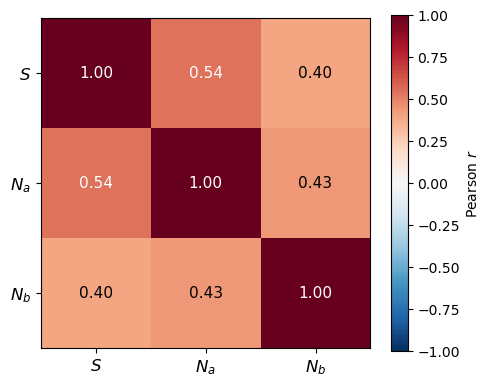

Coupling strength (Frobenius norm of off-diagonal): 1.1327
Modular assumption: 0.000
Surrogate correlation matrix:
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


In [55]:
# Extract shared species trajectories from direct simulation
S_traj  = four_mod_SIM.pop_history[:, 3]
Na_traj = four_mod_SIM.pop_history[:, 7]
Nb_traj = four_mod_SIM.pop_history[:, 12]

# Full correlation matrix
shared = np.vstack([S_traj, Na_traj, Nb_traj])
corr_matrix = np.corrcoef(shared)

print("Correlation matrix [S, Na, Nb]:")
print(np.round(corr_matrix, 3))

# Visualise
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['$S$', '$N_a$', '$N_b$'], fontsize=12)
ax.set_yticklabels(['$S$', '$N_a$', '$N_b$'], fontsize=12)
plt.colorbar(im, ax=ax, label='Pearson $r$')
# ax.set_title('Shared species correlations\n(direct simulation)', fontsize=11)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=11,
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')
plt.tight_layout()
plt.savefig('shared_species_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Modular approach assumes ALL off-diagonal correlations = 0
# Direct simulation has actual correlations
# The Frobenius norm of the off-diagonal block quantifies the coupling

off_diag = corr_matrix - np.eye(3)
coupling_strength = np.linalg.norm(off_diag, 'fro')
print(f"Coupling strength (Frobenius norm of off-diagonal): {coupling_strength:.4f}")
print("Modular assumption: 0.000")

# Generate surrogate trajectories with same means/variances 
# but ZERO cross-correlations
S_mean,  S_std  = np.mean(S_traj),  np.std(S_traj)
Na_mean, Na_std = np.mean(Na_traj), np.std(Na_traj)
Nb_mean, Nb_std = np.mean(Nb_traj), np.std(Nb_traj)

n_points = len(S_traj)
S_surrogate  = np.random.normal(S_mean,  S_std,  n_points)
Na_surrogate = np.random.normal(Na_mean, Na_std, n_points)
Nb_surrogate = np.random.normal(Nb_mean, Nb_std, n_points)

# Check surrogate correlations ≈ 0
surrogate = np.vstack([S_surrogate, Na_surrogate, Nb_surrogate])
print("Surrogate correlation matrix:")
print(np.round(np.corrcoef(surrogate), 3))

In [43]:
G_fund_numerical = np.array(J3_CMs_fourmod[10].tolist(), dtype=float)
eigenvalues, eigenvectors = np.linalg.eigh(G_fund_numerical)

idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

force_labels = ['F/W', 'Nex/Pex', 'Nd/Pb', 'Ne/Pe']

print("Mode assignments:")
for k in range(4):
    # dominant component of eigenvector tells you which force drives this mode
    dominant = np.argmax(np.abs(eigenvectors[:, k]))
    print(f"  λ({k+1}) = {eigenvalues[k]:.4f} "
          f"| dominant force: {force_labels[dominant]} "
          f"| eigenvector: {eigenvectors[:, k]}")

Mode assignments:
  λ(1) = 3.4891 | dominant force: Ne/Pe | eigenvector: [0. 0. 0. 1.]
  λ(2) = 2.4192 | dominant force: Nex/Pex | eigenvector: [ 0. -1.  0.  0.]
  λ(3) = 1.3872 | dominant force: Nd/Pb | eigenvector: [-0.65743438  0.         -0.7535118   0.        ]
  λ(4) = 0.3672 | dominant force: F/W | eigenvector: [-0.7535118   0.          0.65743438 -0.        ]


In [76]:
module3.cycle_matrix

⎡1  0  0⎤
⎢       ⎥
⎢1  0  0⎥
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎢0  0  1⎥
⎢       ⎥
⎣0  0  1⎦

In [18]:
four_mod_SIM = RunSSA(four_mod_DN, J3_combined_counts, J3_combined_rates, 3000, 1000)
four_mod_SIM.run_IF_sweep([18], [np.linspace(190,210,20,dtype=int)], 10 , covariance_reaction_indices=None, verbose=True) # vary Nd 
# four_mod_SIM.run_IF_sweep([18], [np.linspace(490,510,20,dtype=int)], 50 , covariance_reaction_indices=None, verbose=True) # vary Nd 
# , np.linspace(90,110,20,dtype=int)]

Sweep 1/20  ([Nd] = 190)
Sweep 2/20  ([Nd] = 191)
Sweep 3/20  ([Nd] = 192)
Sweep 4/20  ([Nd] = 193)
Sweep 5/20  ([Nd] = 194)
Sweep 6/20  ([Nd] = 195)
Sweep 7/20  ([Nd] = 196)
Sweep 8/20  ([Nd] = 197)
Sweep 9/20  ([Nd] = 198)
Sweep 10/20  ([Nd] = 199)
Sweep 11/20  ([Nd] = 200)
Sweep 12/20  ([Nd] = 201)
Sweep 13/20  ([Nd] = 202)
Sweep 14/20  ([Nd] = 203)
Sweep 15/20  ([Nd] = 204)
Sweep 16/20  ([Nd] = 205)
Sweep 17/20  ([Nd] = 206)
Sweep 18/20  ([Nd] = 207)
Sweep 19/20  ([Nd] = 208)
Sweep 20/20  ([Nd] = 210)
Total sweep time: 39.94 s


(array([[ 0.001     , -0.19649971, -0.00849999, -0.18799972, -0.00999999,
         -0.19349972, -0.19699971,  0.0015    , -0.02749996,  0.16799975,
         -0.02749996, -0.18649973, -0.18599973,  0.01549998,  0.01699998,
         -0.18049973, -0.18099973,  0.11449983,  0.11149984],
        [ 0.02299996, -0.20149966,  0.02499996, -0.20099966, -0.001     ,
         -0.17899969, -0.1764997 , -0.00499999, -0.03849993,  0.13549977,
         -0.04449992, -0.16749971, -0.1739997 , -0.00899998, -0.00899998,
         -0.1754997 , -0.1734997 ,  0.13449977,  0.13349977],
        [ 0.01699951, -0.18699462, -0.00949973, -0.15799545, -0.02649924,
         -0.17549495, -0.17449498,  0.        , -0.00649981,  0.16049538,
         -0.01349961, -0.16899514, -0.17299502, -0.02649924, -0.03349904,
         -0.17299502, -0.17349501,  0.12349645,  0.12299646],
        [ 0.04149989, -0.18199953,  0.0394999 , -0.18049954, -0.0015    ,
         -0.1554996 , -0.15849959,  0.00199999, -0.01299997,  0.1554996 ,


In [198]:
# eigs_fourmod = []
# eigs_direct = []

# for i in range(len(J3_CMs_fourmod)):

#     step3_numerical_RM = np.array(J3_CMs_fourmod[i].tolist(), dtype=float)
#     direct_RM          = np.array(direct_con_ms[i].tolist(), dtype=float)

#     eigs_comb = np.sort(np.linalg.eigvals(step3_numerical_RM).real, axis=1)[:, ::-1]
#     eigs_dir  = np.sort(np.linalg.eigvals(direct_RM).real, axis=1)[:, ::-1]
    
#     eigs_fourmod.append(eigs_comb)
#     eigs_direct.append(eigs_dir)
#     print("Eigenvalues (modular):", eigs_comb)
#     print("Eigenvalues (direct): ", eigs_dir)
#     print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=0.1))


# peak_to_peak_pct1 = (np.array(eigs_fourmod).max(axis=0) - np.array(eigs_fourmod).min(axis=0)) / np.array(eigs_fourmod).mean(axis=0) * 100

# for i, pct in enumerate(peak_to_peak_pct1):
#     print(f"λ{i+1}: {pct:.2f}%")

# print(f"Max across all modes (combined): {peak_to_peak_pct1.max():.2f}%")

# peak_to_peak_pct2 = (np.array(eigs_direct).max(axis=0) - np.array(eigs_direct).min(axis=0)) / np.array(eigs_direct).mean(axis=0) * 100

# for i, pct in enumerate(peak_to_peak_pct2):
#     print(f"λ{i+1}: {pct:.2f}%")

# print(f"Max across all modes (direct): {peak_to_peak_pct2.max():.2f}%")


eigs_fourmod = []
eigs_direct = []

for i in range(len(J3_CMs_fourmod)):

    step3_numerical_RM = np.array(J3_CMs_fourmod[i].tolist(), dtype=float)
    direct_RM          = np.array(direct_con_ms[i].tolist(), dtype=float)

    eigs_comb = np.sort(np.abs(np.linalg.eigvals(step3_numerical_RM).real))[::-1]
    eigs_dir  = np.sort(np.abs(np.linalg.eigvals(direct_RM).real))[::-1]

    eigs_fourmod.append(eigs_comb)
    eigs_direct.append(eigs_dir)
    print("Eigenvalues (modular):", eigs_comb)
    print("Eigenvalues (direct): ", eigs_dir)
    print("Match:", np.allclose(eigs_comb, eigs_dir, rtol=0.1))

eigs_fourmod = np.array(eigs_fourmod)  # shape: (n_sweep, 4)
eigs_direct  = np.array(eigs_direct)

peak_to_peak_pct1 = (eigs_fourmod.max(axis=0) - eigs_fourmod.min(axis=0)) / eigs_fourmod.mean(axis=0) * 100
for i, pct in enumerate(peak_to_peak_pct1):
    print(f"λ{i+1}: {pct:.2f}%")
print(f"Max across all modes (combined): {peak_to_peak_pct1.max():.2f}%")

peak_to_peak_pct2 = (eigs_direct.max(axis=0) - eigs_direct.min(axis=0)) / eigs_direct.mean(axis=0) * 100
for i, pct in enumerate(peak_to_peak_pct2):
    print(f"λ{i+1}: {pct:.2f}%")
print(f"Max across all modes (direct): {peak_to_peak_pct2.max():.2f}%")

Eigenvalues (modular): [3.48908367 2.41540136 1.38688039 0.36205486]
Eigenvalues (direct):  [3.48989297 2.43634198 1.41466    0.38423944]
Match: True
Eigenvalues (modular): [3.48799755 2.4200101  1.39122897 0.37012551]
Eigenvalues (direct):  [3.48608502 2.43570567 1.41479586 0.38589156]
Match: True
Eigenvalues (modular): [3.4851227  2.40950725 1.38853075 0.36710835]
Eigenvalues (direct):  [3.48509066 2.42865084 1.40848606 0.37696326]
Match: True
Eigenvalues (modular): [3.49681263 2.42330928 1.3853029  0.36742348]
Eigenvalues (direct):  [3.487746   2.42777928 1.41300253 0.38191165]
Match: True
Eigenvalues (modular): [3.4842989  2.41945617 1.38719244 0.36700041]
Eigenvalues (direct):  [3.48938242 2.43311405 1.40333386 0.37490549]
Match: True
Eigenvalues (modular): [3.48114848 2.41941653 1.38780066 0.36937323]
Eigenvalues (direct):  [3.48878842 2.42860174 1.40633833 0.37515856]
Match: True
Eigenvalues (modular): [3.48803362 2.4189843  1.38914481 0.36580537]
Eigenvalues (direct):  [3.49199

No difference plotted: Option Deprecated.


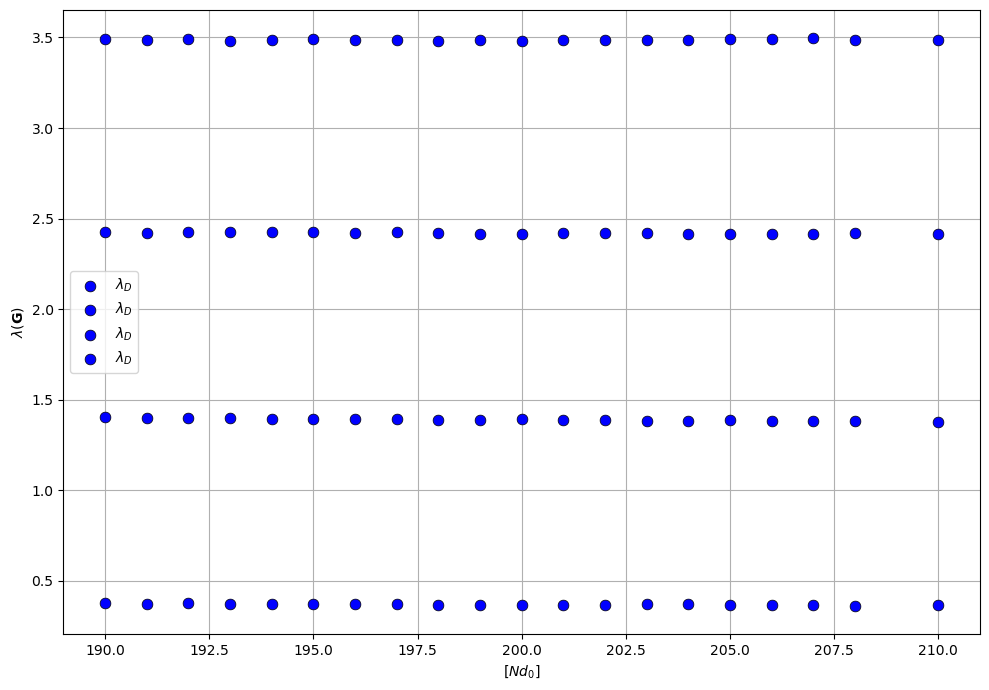

In [30]:
four_mod_SIM.plot_conductance( show_covariance=False)

In [83]:
def get_steady_state_values(sim, species_of_interest, burn_in_fraction=None):
    """
    Extract steady state values by time-averaging over the post-burn-in
    portion of the trajectory.
    
    Parameters
    ----------
    sim : RunSSA
        A RunSSA object after calling run_SSA_and_plot_counts(store_trajectories=True).
    species_of_interest : list of str
        Species names to extract.
    burn_in_fraction : float or None
        If None, uses the sim's burn_in time directly.
    
    Returns
    -------
    dict : {species_name: time_averaged_count_at_steady_state}
    """
    if not hasattr(sim, 'pop_history') or not hasattr(sim, 'time_history'):
        raise RuntimeError("No pop_history/time_history found. "
                           "Call sim.run_SSA_and_plot_counts(store_trajectories=True) first.")
    
    # Get species index mapping
    name_to_idx = {name: idx for idx, name in enumerate(sim.species_names)}
    
    # Determine burn-in cutoff using the simulation's burn_in time
    if burn_in_fraction is not None:
        burn_in_time = burn_in_fraction * sim.time_history[-1]
    else:
        burn_in_time = sim.burn_in
    
    # Find index where time exceeds burn-in
    burn_in_idx = np.searchsorted(sim.time_history, burn_in_time)
    
    # Time-weighted average (proper for SSA with variable time steps)
    times_post = sim.time_history[burn_in_idx:]
    pops_post = sim.pop_history[burn_in_idx:]
    
    # Time intervals between events
    dt = np.diff(times_post)
    
    results = {}
    for species in species_of_interest:
        if species in name_to_idx:
            idx = name_to_idx[species]
            # Weight each population by the time spent in that state
            counts = pops_post[:-1, idx]  # population during each interval
            results[species] = np.sum(counts * dt) / np.sum(dt)
        else:
            print(f"Warning: '{species}' not found. Available: {sim.species_names}")
    
    return results


# --- Usage ---
repeats = 50
SS_S = []
SS_Na = []
SS_Nb = []

plt.ioff() 

for i in range(repeats):
    print(f'Repeat: {i+1}')
    
    # Must store trajectories for time-averaging
    four_mod_SIM.run_SSA_and_plot_counts(store_trajectories=True,plot=False)
    plt.close('all')
    
    steady_state = get_steady_state_values(four_mod_SIM, ['S', 'Na', 'Nb'])
    
    print(steady_state['S'])
    SS_S.append(steady_state['S'])
    SS_Na.append(steady_state['Na'])
    SS_Nb.append(steady_state['Nb'])

plt.ion() 

print(f"\nS  steady state: {np.mean(SS_S):.1f} ± {np.std(SS_S)/np.sqrt(repeats):.1f}")
print(f"Na steady state: {np.mean(SS_Na):.1f} ± {np.std(SS_Na)/np.sqrt(repeats):.1f}")
print(f"Nb steady state: {np.mean(SS_Nb):.1f} ± {np.std(SS_Nb)/np.sqrt(repeats):.1f}")

Repeat: 1
349.38929025173
Repeat: 2
350.34502927625834
Repeat: 3
350.10008485363915
Repeat: 4
348.9769799481572
Repeat: 5
351.9849525817604
Repeat: 6
347.5940927933802
Repeat: 7
354.4118901055398
Repeat: 8
345.8155039570185
Repeat: 9
351.9110831237431
Repeat: 10
354.9396210310425
Repeat: 11
352.0789589985976
Repeat: 12
350.80775492826126
Repeat: 13
349.7055385331265
Repeat: 14
351.1663820952896
Repeat: 15
354.1362701158518
Repeat: 16
349.9434840845541
Repeat: 17
350.78329445511105
Repeat: 18
353.64389468221225
Repeat: 19
350.07789028260726
Repeat: 20
354.3281556254984
Repeat: 21
350.572416620398
Repeat: 22
355.4874395654566
Repeat: 23
351.56725738030104
Repeat: 24
347.9172575415233
Repeat: 25
351.9352474541394
Repeat: 26
349.45374173886637
Repeat: 27
350.949222691425
Repeat: 28
352.86387564523346
Repeat: 29
348.99114042957484
Repeat: 30
352.4456858202748
Repeat: 31
351.06916060271647
Repeat: 32
352.7590146027156
Repeat: 33
353.6481666686486
Repeat: 34
354.6935267981952
Repeat: 35
355.6

In [126]:
eigs_fourmod


[array([0.04541079, 0.20094263, 0.45999987, 0.75082515]),
 array([0.04528421, 0.18785713, 0.7012506 , 1.4701811 ]),
 array([0.04548268, 0.18368905, 0.58990058, 0.72590496]),
 array([-0.07265269,  0.04459097,  0.20451699,  0.68654987]),
 array([0.0452624 , 0.20959307, 0.66504574, 1.01870458]),
 array([0.04494176, 0.19363274, 0.6053202 , 1.10690912]),
 array([0.0346689 , 0.04488092, 0.19816012, 0.69077685]),
 array([-0.00251497,  0.0448626 ,  0.18278542,  0.70554857]),
 array([0.04554268, 0.17441255, 0.19810738, 0.71598888]),
 array([-0.03125297,  0.04499361,  0.19372174,  0.6769749 ]),
 array([-0.4020005 ,  0.04448133,  0.20499042,  0.66513287]),
 array([0.04613436, 0.2133087 , 0.72170544, 1.21852434]),
 array([0.04576208, 0.19499269, 0.3518247 , 0.67515645]),
 array([-0.52752413,  0.04473589,  0.20439733,  0.68376702]),
 array([-0.25352452,  0.04537323,  0.20032309,  0.71647103]),
 array([0.04516597, 0.18766813, 0.67218292, 6.5611307 ]),
 array([-0.12669823,  0.04535493,  0.20286709,  

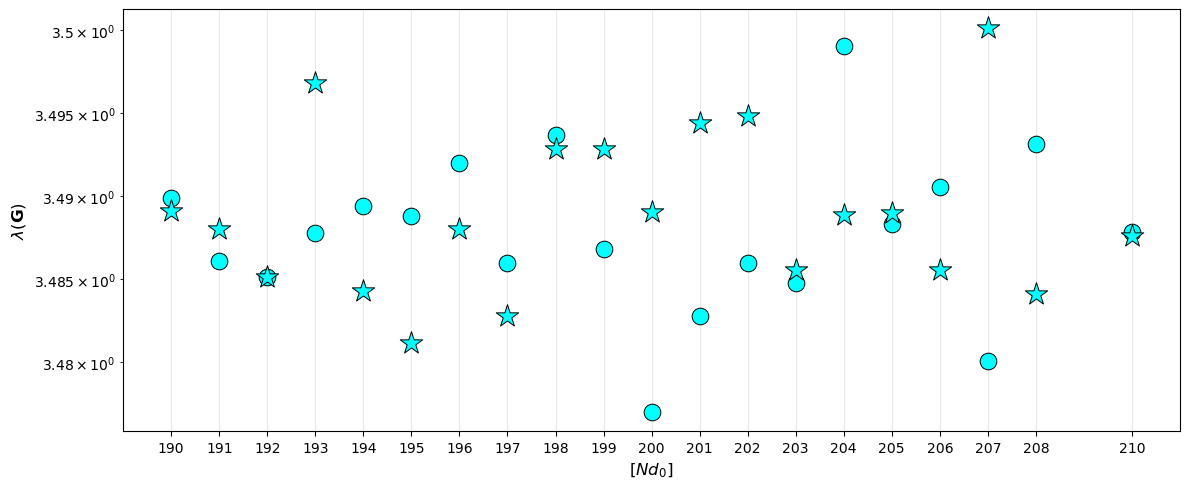

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# X axis
x = np.linspace(190, 210, 20, dtype=int)

# array1 = np.sort(np.abs(np.array(eigs_fourmod)), axis=1) # combined data
# array2 = np.sort(np.abs(np.array(eigs_direct)), axis=1) # direct data
# Sort DESCENDING everywhere
array1 = np.sort(np.abs(np.array(eigs_fourmod)), axis=1)[:, ::-1]  # combined, descending
array2 = np.sort(np.abs(np.array(eigs_direct)),  axis=1)[:, ::-1]  # direct, descending

from scipy.optimize import linear_sum_assignment

def match_eigs(ref, other):
    cost = np.abs(ref[:, None] - other[None, :])
    _, col_ind = linear_sum_assignment(cost)
    return other[col_ind]

# Match array2 to array1 at each sweep point
array2_matched = np.zeros_like(array2)
for i in range(len(x)):
    array2_matched[i] = match_eigs(array1[i], array2[i])
n_x = len(x)
n_eig = array1.shape[1]



# ── customisation ──────────────────────────────────────────
colors        = ['cyan', 'coral', 'limegreen', 'red']
markers       = ['*', 'o']
markersize_a1 = 17
markersize_a2 = 12
edgecolor     = 'black'
linewidth     = 0.7
ev_labels     = [r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$', r'$\lambda_4$']
# ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

for i in range(1):
    ax.scatter(x, array2_matched[:, i],
               color=colors[i], marker=markers[1],
               s=markersize_a2**2, edgecolors=edgecolor,
               linewidths=linewidth, zorder=3)

for i in range(1):
    ax.scatter(x, array1[:, i],
               color=colors[i], marker=markers[0],
               s=markersize_a1**2, edgecolors=edgecolor,
               linewidths=linewidth, zorder=4)


    

# custom legend
handles = []
for i in range(n_eig):
    h1 = mlines.Line2D([], [], color=colors[i], marker='*', linestyle='None',
                       markersize=markersize_a1*0.7, markeredgecolor=edgecolor,
                       markeredgewidth=0.5, label=f'$\\lambda_C^{{({i+1})}}$')
    h2 = mlines.Line2D([], [], color=colors[i], marker='o', linestyle='None',
                       markersize=markersize_a2*0.7, markeredgecolor=edgecolor,
                       markeredgewidth=0.5, label=f'$\\lambda_D^{{({i+1})}}$')
    handles.extend([h1, h2])

# ax.legend(handles=handles, ncol=1, fontsize=9,
#           loc='center left', bbox_to_anchor=(1.01, 0.5),
#           framealpha=0.9)
plt.tight_layout()

# rel_error = np.abs(array1 - array2) / array2
# ax.plot(x, rel_error)
ax.set_xlabel(r'$[{Nd}_0]$', fontsize=12)
ax.set_ylabel(r'$\lambda(\mathbf{G})$', fontsize=12)
ax.set_xticks(x)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
# plt.ylim(-0.1,0.8)
plt.tight_layout()
plt.grid(True)
plt.savefig('trueSS_mod1_log.png', dpi=300, bbox_inches='tight')

plt.show()

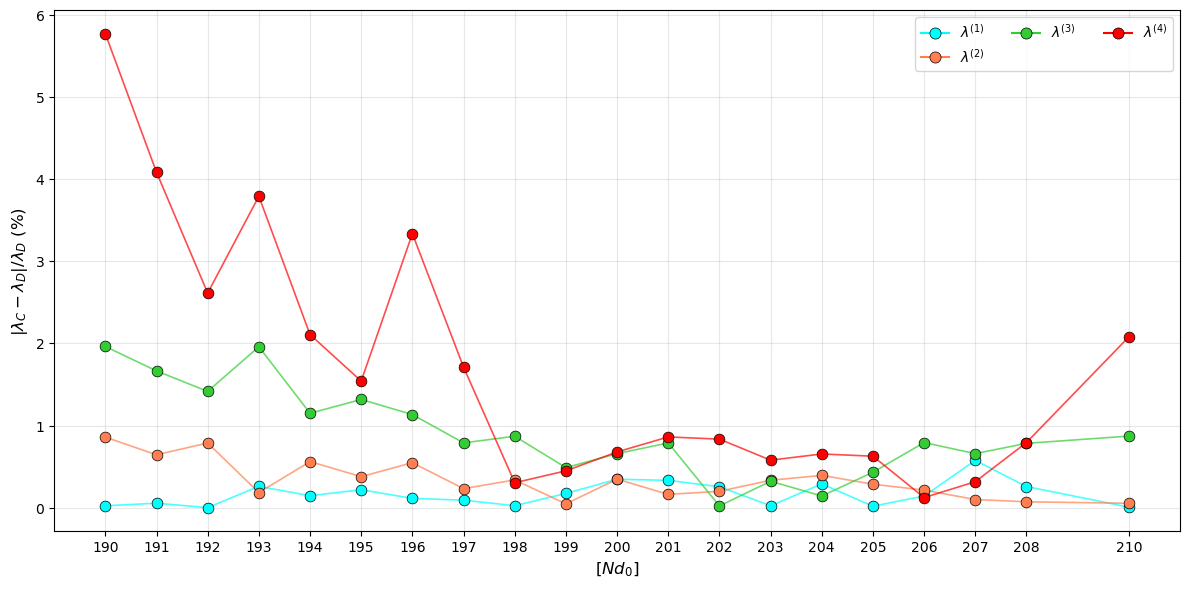

Worst Nd values by total error:
  Nd=199: total=8.3%, modes=[0.2 0.  0.5 0.4]%
  Nd=210: total=7.8%, modes=[0.  0.1 0.9 2.1]%
  Nd=194: total=7.5%, modes=[0.1 0.6 1.2 2.1]%
  Nd=190: total=7.0%, modes=[0.  0.9 2.  5.8]%
  Nd=195: total=6.9%, modes=[0.2 0.4 1.3 1.5]%


In [56]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_err = ['cyan', 'coral', 'limegreen', 'red']

# Compute all errors first
all_errors = np.zeros((len(x), 4))
for i in range(len(x)):
    eigs_c = array1[i]
    eigs_d = array2[i]
    cost = np.abs(eigs_c[:, None] - eigs_d[None, :])
    _, col_ind = linear_sum_assignment(cost)
    all_errors[i] = np.abs(eigs_c - eigs_d[col_ind]) / eigs_d[col_ind] * 100

# Plot each mode as connected line + scatter
for j in range(4):
    ax.plot(x, all_errors[:, j],
            color=colors_err[j], linewidth=1.2,
            alpha=0.7, zorder=2)
    ax.scatter(x, all_errors[:, j],
               color=colors_err[j], marker='o', s=60,
               edgecolors='black', linewidths=0.5, zorder=3)

# # Sum of all errors at each Nd
# total_err = np.sum(all_errors, axis=1)
# ax.plot(x, total_err,
#         color='black', linewidth=2.0,
#         linestyle='-', zorder=4, label='Total error')
# ax.scatter(x, total_err,
#            color='black', marker='D', s=60,
#            edgecolors='black', linewidths=0.5, zorder=5)

# # 10% threshold line
# ax.axhline(10, color='grey', linestyle='--', 
#            alpha=0.5, linewidth=1, label='10% threshold')

# Legend
handles = [
    mlines.Line2D([], [], color=colors_err[j], marker='o',
                  linestyle='-', markersize=8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label=f'$\\lambda^{{({j+1})}}$')
    for j in range(4)
]


ax.legend(handles=handles, ncol=3, fontsize=10, loc='upper right')

ax.set_xlabel(r'$[Nd_0]$', fontsize=12)
ax.set_ylabel(r'$|\lambda_C - \lambda_D|/\lambda_D$ (%)', fontsize=12)
ax.set_xticks(x)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eigenvalue_relative_error.png', dpi=300, bbox_inches='tight')
plt.show()

# Print worst Nd values by total error
worst_idx = np.argsort(total_err)[::-1][:5]
print("Worst Nd values by total error:")
for idx in worst_idx:
    print(f"  Nd={x[idx]}: total={total_err[idx]:.1f}%, "
          f"modes={np.round(all_errors[idx], 1)}%")

In [74]:
saved_data1 = array1
saved_data2 = array2_matched

In [72]:
for i in range(4):
    col1, col2 = array1[:, i], array2[:, i]
    
    # Use absolute deviation from median rather than multiplicative
    med1 = np.median(col1)
    med2 = np.median(col2)
    
    # Outlier: either value deviates more than 3x the median absolute deviation
    mad1 = np.median(np.abs(col1 - med1))
    mad2 = np.median(np.abs(col2 - med2))
    
    mask = (np.abs(col1 - med1) < 3*mad1) & (np.abs(col2 - med2) < 3*mad2)
    
    if mask.sum() == 0 or med1 < 0.01:
        print(f"Mode {i+1}: SKIPPED — near-zero mode, not physically meaningful")
        continue
        
    rel = np.abs(col1[mask] - col2[mask]) / col1[mask]
    print(f"Mode {i+1}: mean rel error = {np.mean(rel)*100:.1f}%  "
          f"({mask.sum()}/{len(mask)} non-outlier points)")

Mode 1: mean rel error = 1.0%  (17/20 non-outlier points)
Mode 2: mean rel error = 1.7%  (9/20 non-outlier points)
Mode 3: mean rel error = 169.6%  (11/20 non-outlier points)
Mode 4: mean rel error = 954.6%  (14/20 non-outlier points)


In [95]:
for i, G_mat in enumerate(four_mod_SIM.sweep_G_fundamental):
    G = np.array(G_mat.tolist(), dtype=float)
    vals, vecs = np.linalg.eig(G)
    idx = np.argmax(np.abs(vals))
    print(f'x={x[i]}: largest eigenvalue = {vals[idx]:.3f}')
    print(f'corresponding eigenvector: {np.abs(vecs[:, idx]).round(3)}')
    print()

x=130: largest eigenvalue = 4.613
corresponding eigenvector: [0. 1. 0. 0.]

x=132: largest eigenvalue = 0.669
corresponding eigenvector: [0. 0. 0. 1.]

x=134: largest eigenvalue = -16.783
corresponding eigenvector: [0. 1. 0. 0.]

x=136: largest eigenvalue = 0.646
corresponding eigenvector: [0. 0. 0. 1.]

x=138: largest eigenvalue = 7.856
corresponding eigenvector: [0. 1. 0. 0.]

x=140: largest eigenvalue = -1.607
corresponding eigenvector: [0. 1. 0. 0.]

x=142: largest eigenvalue = 0.664
corresponding eigenvector: [0. 0. 0. 1.]

x=144: largest eigenvalue = -8.506
corresponding eigenvector: [0. 1. 0. 0.]

x=146: largest eigenvalue = 2.423
corresponding eigenvector: [0. 1. 0. 0.]

x=148: largest eigenvalue = -11.366
corresponding eigenvector: [0. 1. 0. 0.]

x=151: largest eigenvalue = -25.789
corresponding eigenvector: [0. 1. 0. 0.]

x=153: largest eigenvalue = -9.857
corresponding eigenvector: [0. 1. 0. 0.]

x=155: largest eigenvalue = 1.430
corresponding eigenvector: [0. 1. 0. 0.]

x=1

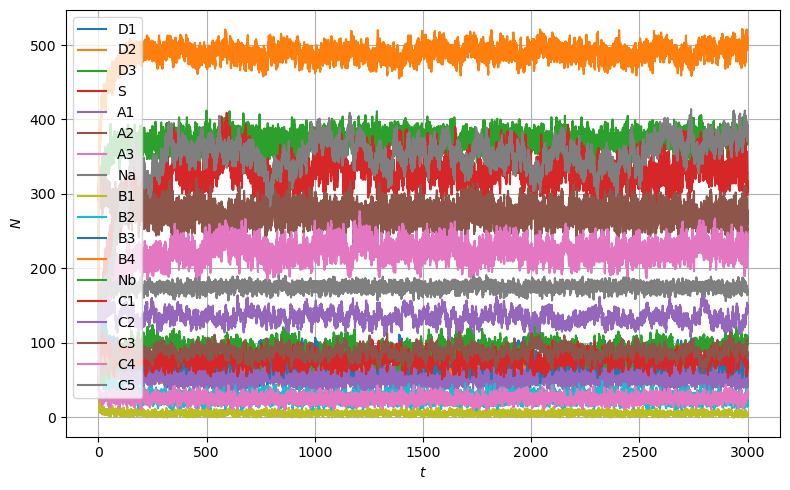

In [79]:
four_mod_SIM.run_SSA_and_plot_counts(True)

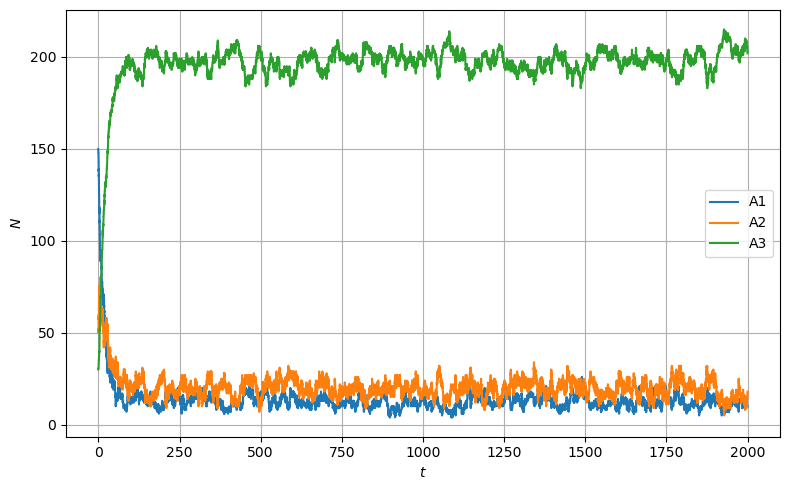

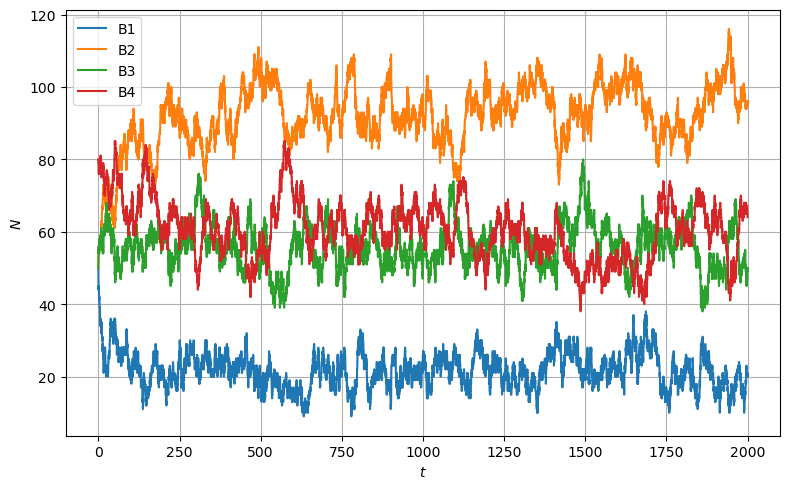

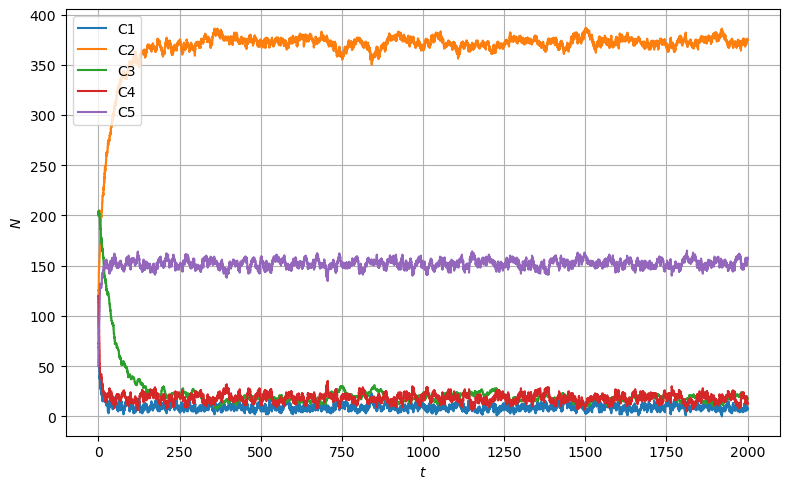

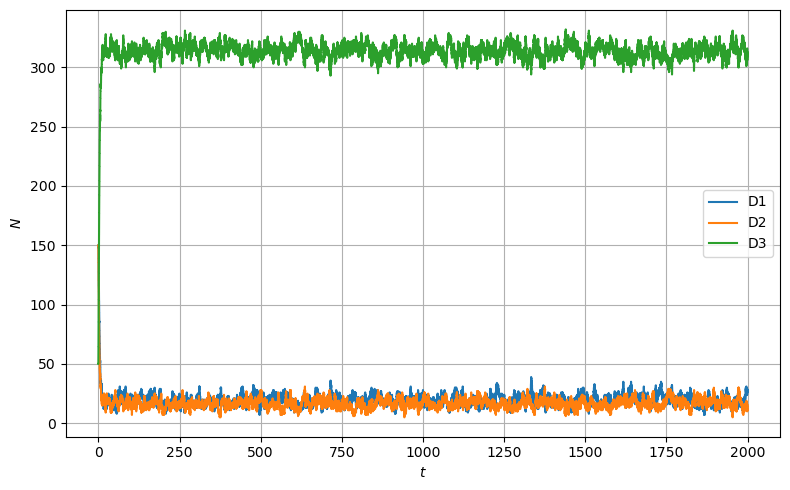

In [12]:
SIM1_fourmod.run_SSA_and_plot_counts(True,True)
SIM2_fourmod.run_SSA_and_plot_counts(True,True)
SIM3_fourmod.run_SSA_and_plot_counts(True,True)
SIM4_fourmod.run_SSA_and_plot_counts(True,True)

# If curve

In [142]:
# But let's say we want to overlay some analytical data. For module 1, we can solve the steady state equations and calculate the 
# currents and forces as below, then we can pass these into the attribute to get an overlay.
# initial_counts = [150, 50, 30, 151, 168]
initial_counts = 3*np.array([150, 50, 30, 151, 168])
# newer_rates = np.array([0.0005, 0.006, 0.010, 0.001, 0.0005, 0.008])

# new_initial_counts = [350, 350, 350, 50, 50]

new_rates = np.array([0.0005, 0.15, 0.010, 0.0001, 0.0005, 0.008])
#                  k1f    k1b    k2f    k2b      k3f     k3b

rates = new_rates
k1f = rates[0]
k1b = rates[1]
k2f = rates[2]
k2b = rates[3]
k3f = rates[4]
k3b = rates[5]

Na = 168*3

E_T = 690 # total internal species (shouldn't change due to conservation)

analytical_current1 = []
analytical_force1 = []

analytical_current2 = []
analytical_force2 = []

analytical_current3 = []
analytical_force3 = []

S_counts = np.linspace(130,160,20,dtype='int')

for S in S_counts:

    chi = ((k2f + k1b)/(k1f*S + k2b*Na))

    j1 = (k1f*k2f*S - k1b*k2b*Na)*E_T / (((k1f*S + k2b*Na)*(1+ k3f*S/k3b))+k2f+k1b)

    f1 = np.log( (k1f*S*(k1b+k2f)) / (k1b*(k1f*S + k2b*Na)) )

    j2 = (E_T *k2f - E_T*k2b*Na*chi)/(1 + chi + k3f*S/k3b )
    
    f2 = np.log( (k2f*(k1f*S + k2b*Na) / (k2b*Na*(k2f + k1b)) ))

    j3 = 0

    f3 = 0
    
    analytical_current1.append(j1)
    analytical_force1.append(f1)

    analytical_current2.append(j2)
    analytical_force2.append(f2)

    analytical_current3.append(j3)
    analytical_force3.append(f3)

an_currents = [analytical_current1, analytical_current2, analytical_current3]
an_forces = [analytical_force1, analytical_force2, analytical_force3]

In [ ]:
jsim = SIM1_fourmod.sweep_I_means
fsim = SIM1_fourmod.sweep_F_means

IndexError: invalid index to scalar variable.

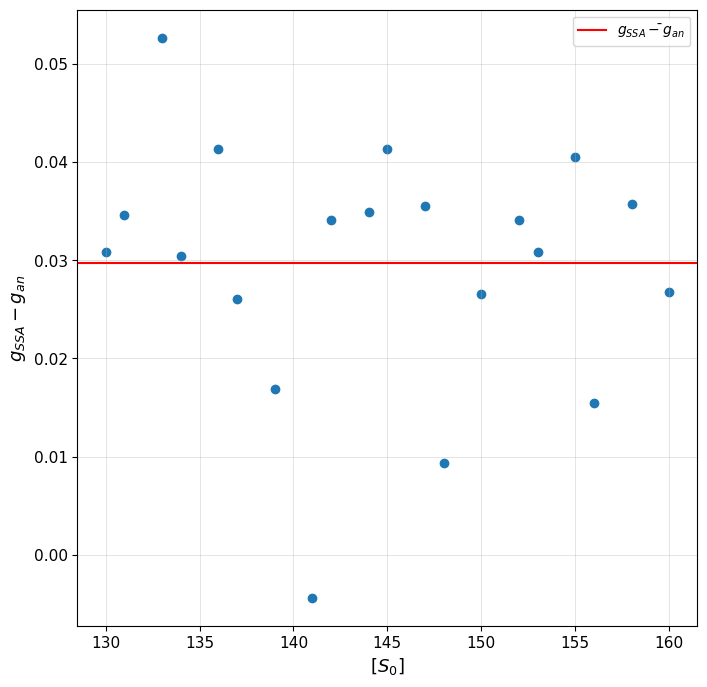

0.029690649069064802


In [161]:
jsim1 = [cur[0] for cur in jsim]
fsim1 = [force[0] for force in fsim]


gsim = []
gana = []

diff = []
for i in range(20):
    gsim.append(jsim1[i]/fsim1[i])

    gana.append(analytical_current1[i]/analytical_force1[i])

    diff.append((jsim1[i]/fsim1[i]) - (analytical_current1[i]/analytical_force1[i]) )

S_counts = np.linspace(130,160,20,dtype='int')
plt.scatter(S_counts, diff)
plt.axhline(np.mean(diff), label=r'$\bar{g_{SSA} - g_{an}}$',color='red')
plt.xlabel(r'$[S_0]$', fontsize=13)
plt.ylabel(r'$g_{SSA} - g_{an}$', fontsize=13)
plt.tick_params(labelsize=11)
plt.grid(True, linewidth=0.4, alpha=0.6)
plt.legend()
plt.show()

print(np.mean(diff))


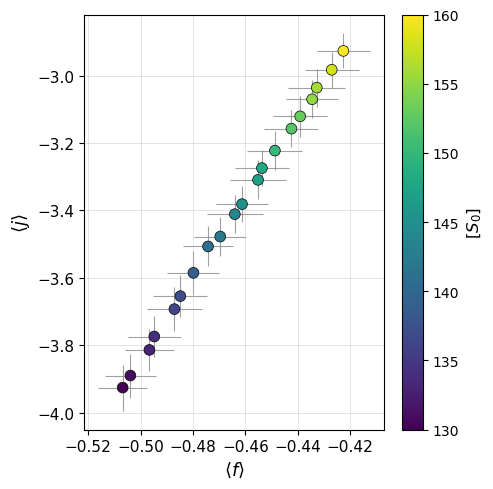

Saved: IF_curve_reaction_1.png


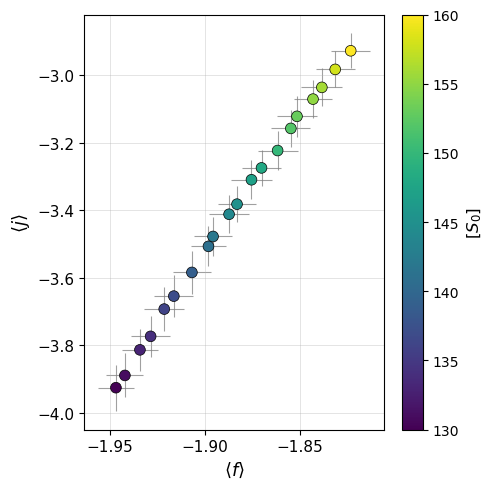

Saved: IF_curve_reaction_2.png


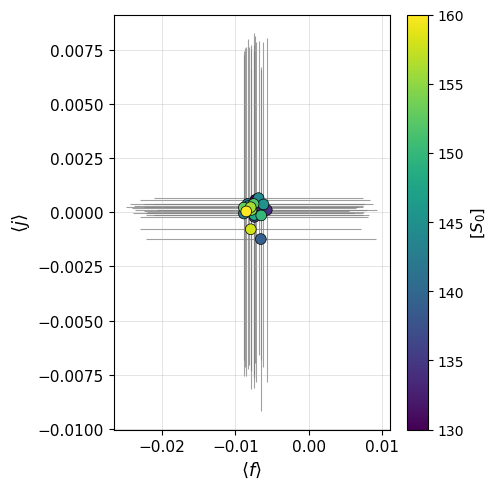

Saved: IF_curve_reaction_3.png


In [144]:
# SIM1_fourmod = RunSSA(module1, initial_counts, new_rates, simulation_length, burn_in)

# SIM1_fourmod.run_IF_sweep(
    
#         species_index=[3],
#         count_values=[np.linspace(130,160,20,dtype='int')],
#         total_iterations=300, 
#         covariance_reaction_indices=[0],   
#         verbose=True)



SIM1_fourmod.plot_IF_curves(
        
        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

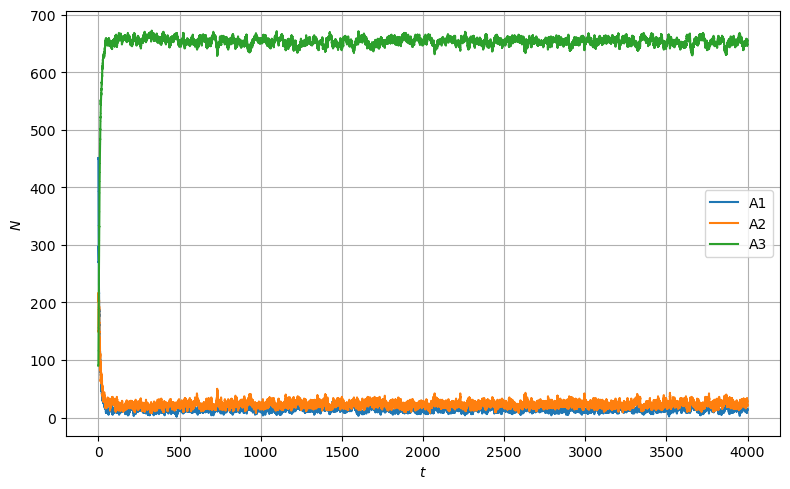

In [38]:
SIM1_fourmod = RunSSA(module1, initial_counts, new_rates, simulation_length, burn_in)
SIM1_fourmod.run_SSA_and_plot_counts(True)